# Calibration-Aware, Recall-Oriented Evaluation of Deep Architectures for Brain Tumor MRI Classification

### A three-arm loss ablation (Focal · Cross-Entropy · Class-Weighted Cross-Entropy) with pseudo-patient-grouped splits, decision-threshold optimisation, calibration, robustness, OOD and explainability analysis

**Author:** Muhammad Uzair Baqir — MPhil Computer Science, NCBAE Sub Campus Multan
**Dataset:** Brain Tumor MRI Dataset (Nickparvar, Kaggle) — glioma, meningioma, no tumor, pituitary
**Primary backbone:** `convnext_tiny` (ImageNet-1K pretrained, `timm`), selected on validation macro-F1
**Comparators:** `swin_tiny_patch4_window7_224`, `resnet50`, `vit_small_patch16_224`

---

## What is new in this version (v2)

The previous version established a clean, honest baseline but left three open weaknesses. This version addresses
all three **inside the same dataset**, without requiring new data:

| Weakness in v1 | What v2 does about it | Where |
|---|---|---|
| **Patient overlap could not be excluded** (no patient IDs) | **Perceptual-hash pseudo-patient grouping.** Near-duplicate images (adjacent slices of the same study look nearly identical) are clustered with a 64-bit dHash + union–find. The train/validation split is then a **grouped** split, so no pseudo-patient appears on both sides. Train↔test near-duplicate overlap is *measured* and reported. | §3, Fig. 2 |
| **Only 3 seeds** → "indicative" statistics | **5 seeds** per arm (configurable), paired tests across seeds with **Holm–Bonferroni correction** for the three pairwise arm comparisons, plus **paired bootstrap CIs** on the test set. | §2, §7, Fig. 7 |
| **Weak glioma recall (81.75%)**, focal loss did not fix it | Two independent remedies, both evaluated: **(i) a class-weighted cross-entropy arm** that raises the cost of a missed glioma during training, and **(ii) post-hoc decision-threshold / logit-bias optimisation** tuned **on validation only** to hit a target glioma recall, with the precision cost quantified. | §5, §9, Fig. 15–17 |
| **Single backbone** → the loss effect and the architecture effect were confounded | **Four architectures** (ConvNeXt-T, Swin-T, ResNet-50, ViT-S/16) trained under the *identical* protocol, so the calibration claim is tested across model families rather than asserted from one. Baselines are trained here, not copied from other papers. **ConvNeXt-T is the primary backbone, chosen by validation macro-F1 before any test metric was computed.** Each family receives the learning rate its own literature recommends; a single shared LR under-trains CNNs and is not a fair protocol. | §7b, Fig. 8–10 |

## The honest headline this notebook is designed to support

Focal loss was introduced for **class imbalance**. This dataset is **perfectly balanced** (1,190 training images per
class), so there is no imbalance for the modulating factor to correct. v1 found that cross-entropy matched or beat
focal loss on accuracy while focal loss only helped *raw* calibration — an advantage that temperature scaling largely
erased. v2 keeps focal loss as a **rigorously tested negative result** and asks the more useful question:

> *Given a balanced dataset, what actually fixes the clinically important error — missed gliomas — and what does it cost?*

That is a stronger, more publishable contribution than reporting another 95% accuracy number.

## Evaluation dimensions

| Dimension | Question | Main metrics |
|---|---|---|
| 1. Discrimination | Does it classify correctly? | Accuracy, macro-F1, per-class P/R/F1, AUROC, AUPRC, 95% bootstrap CIs |
| 2. **Clinical error profile** | Does it miss tumors? | Glioma recall, false-negative rate, cost-weighted error |
| 3. Calibration | Can the confidence be trusted? | ECE, MCE, Brier, NLL, reliability diagrams, temperature scaling |
| 4. Robustness | Does it survive image degradation? | Macro-F1 under 3 corruptions × 5 severities |
| 5. OOD behaviour | Does it flag non-MRI input? | MSP AUROC / FPR@95%TPR on 5 OOD sets |
| 6. Explainability | Where does it look? | Gradient saliency, Grad-CAM, 768-D embeddings, silhouette |

> **Runtime (Kaggle T4):** ≈ 3–3.5 h at the default 3 arms × 5 seeds. Set `QUICK_MODE = True` in §2 for a ≈ 40 min
> smoke test (1 seed). **Before running:** *Add Input →* `masoudnickparvar/brain-tumor-mri-dataset`,
> *Settings → Accelerator → GPU T4*, *Internet → On*.

## 1. Environment, imports and publication figure style

Every figure is written as **PNG (300 dpi)** and **PDF (vector)** into `results/figures/`, so it can be dropped
straight into LaTeX with `\includegraphics{}`. The colour palette is the **Okabe–Ito colour-blind-safe** set, which
several Q1 journals now request explicitly.

In [2]:
import os, json, glob, time, copy, random, hashlib, itertools, warnings
from datetime import datetime
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from scipy import stats, sparse
from scipy.sparse.csgraph import connected_components

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm

from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, roc_curve, auc, roc_auc_score,
                             precision_recall_curve, average_precision_score, silhouette_score)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("PyTorch :", torch.__version__, "| timm:", timm.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device  :", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

OUT_DIR = "/kaggle/working/results" if os.path.isdir("/kaggle/working") else "./results"
FIG_DIR = os.path.join(OUT_DIR, "figures")
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")
for d in (OUT_DIR, FIG_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

# ---- Publication (Q1 journal) figure style -------------------------------
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["DejaVu Serif", "Times New Roman"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
})
# Okabe-Ito colour-blind-safe palette
CB = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]

# ---- the three ablation arms ---------------------------------------------
ARMS      = ["focal", "ce", "ce_w"]
LOSS_NAME = {"focal": "Focal Loss", "ce": "Cross-Entropy", "ce_w": "Weighted CE"}
LOSS_COL  = {"focal": "#0072B2", "ce": "#D55E00", "ce_w": "#009E73"}
LOSS_MARK = {"focal": "o", "ce": "s", "ce_w": "^"}

def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name + ".png"))
    fig.savefig(os.path.join(FIG_DIR, name + ".pdf"))
    print(f"  saved -> figures/{name}.png / .pdf")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def holm_bonferroni(pvals, alpha=0.05):
    """Holm-Bonferroni step-down correction. Returns (adjusted p, reject flags)."""
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); running = 0.0
    for rank, idx in enumerate(order):
        val = (m - rank) * p[idx]
        running = max(running, val)
        adj[idx] = min(running, 1.0)
    return adj, adj < alpha

print("Setup complete. Arms:", [LOSS_NAME[a] for a in ARMS])

PyTorch : 2.10.0+cu128 | timm: 1.0.26
Device  : cuda | Tesla T4
Setup complete. Arms: ['Focal Loss', 'Cross-Entropy', 'Weighted CE']


## 2. Configuration — the single source of truth

Every hyper-parameter lives here and is exported to `config.json`, so the run is reproducible from the artefacts
alone. Three settings deserve explanation because they are the substantive additions of v2:

* **`SEEDS`** — five seeds instead of three. With three seeds a paired *t*-test has 2 degrees of freedom and almost
  no power; with five it has 4, and combined with Holm correction across the three arm-pairs the conclusions become
  defensible rather than merely indicative. Cost: linear in runtime.
* **`glioma_weight`** — the cost multiplier applied to the glioma class in the weighted-CE arm. It is **not** an
  imbalance correction (the data are balanced); it encodes the **clinical asymmetry** that a missed glioma is a more
  serious error than a false alarm. Setting it to 2.0 says "one missed glioma is worth two false positives".
* **`target_glioma_recall`** — the operating point for the post-hoc threshold search in §9. The search runs on the
  **validation set only**; the test set is never used to choose a threshold, which is the single most common
  methodological error in papers that report "tuned" recall.

In [3]:
QUICK_MODE = False       # True -> 1 seed, fewer bootstraps: ~40 min smoke test

CONFIG = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "model": "convnext_tiny", "pretrained": True, "drop_rate": 0.2,
    "img_size": 224, "batch_size": 32, "num_workers": 2,
    "epochs": 20, "lr": 1e-4, "weight_decay": 1e-4, "eta_min": 1e-7,
    "grad_clip": 1.0, "patience": 7, "val_fraction": 0.20,
    "min_epochs": 8,                 # early stopping may not fire before this

    # --- ablation arms ---
    "focal_alpha": 1.0, "focal_gamma": 2.0,
    "glioma_weight": 2.0,            # cost multiplier for the glioma class in the weighted-CE arm

    # --- seeds ---
    "SEEDS": [42] if QUICK_MODE else [42, 43, 44, 45, 46],
    "MAIN_SEED": 42,

    # --- pseudo-patient grouping (v2) ---
    "use_group_split": True,         # group train/val split by near-duplicate cluster
    "dhash_threshold": 3,            # max Hamming distance (of 64 bits) for a near-duplicate link
    "auto_tune_threshold": True,     # lower it further if a giant component forms
    "max_group_fraction": 0.05,      # no pseudo-patient group may exceed 5% of the training set
    "min_dhash_threshold": 1,        # NEVER descend to 0: that groups only byte-identical hashes
                                     # and leaves genuine near-duplicates spanning the split

    # --- decision-threshold optimisation (v2) ---
    "target_glioma_recall": 0.95,    # operating point tuned on VALIDATION only
    "bias_grid": [0.0, 4.0, 201],    # search grid for the glioma logit bias

    # --- evaluation ---
    "ece_bins": 15,
    "n_bootstrap": 200 if QUICK_MODE else 1000,
    "severities": {"gaussian_noise": [0.04, 0.08, 0.12, 0.16, 0.20],
                   "motion_blur":    [3, 5, 7, 9, 11],
                   "intensity":      [0.90, 1.05, 1.10, 1.15, 1.20]},
    "ood_n": 100 if QUICK_MODE else 300,
    "triage_thresholds": [0.90, 0.70],
}
with open(os.path.join(OUT_DIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

n_runs = len(ARMS) * len(CONFIG["SEEDS"])
print(json.dumps(CONFIG, indent=2))
print(f"\nPlanned runs: {len(ARMS)} arms x {len(CONFIG['SEEDS'])} seeds = {n_runs} trainings"
      f"  (~{n_runs * 9} min on a T4)")

{
  "timestamp": "2026-09-26T17:52:31",
  "model": "convnext_tiny",
  "pretrained": true,
  "drop_rate": 0.2,
  "img_size": 224,
  "batch_size": 32,
  "num_workers": 2,
  "epochs": 20,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "eta_min": 1e-07,
  "grad_clip": 1.0,
  "patience": 7,
  "val_fraction": 0.2,
  "min_epochs": 8,
  "focal_alpha": 1.0,
  "focal_gamma": 2.0,
  "glioma_weight": 2.0,
  "SEEDS": [
    42,
    43,
    44,
    45,
    46
  ],
  "MAIN_SEED": 42,
  "use_group_split": true,
  "dhash_threshold": 3,
  "auto_tune_threshold": true,
  "max_group_fraction": 0.05,
  "min_dhash_threshold": 1,
  "target_glioma_recall": 0.95,
  "bias_grid": [
    0.0,
    4.0,
    201
  ],
  "ece_bins": 15,
  "n_bootstrap": 1000,
  "severities": {
    "gaussian_noise": [
      0.04,
      0.08,
      0.12,
      0.16,
      0.2
    ],
    "motion_blur": [
      3,
      5,
      7,
      9,
      11
    ],
    "intensity": [
      0.9,
      1.05,
      1.1,
      1.15,
      1.2
    ]
  },
  "

## 3. Data, pseudo-patient grouping and leakage audit

### 3.1 Why a naive random split is not enough

The Kaggle dataset ships as two folders, `Training/` and `Testing/`, with **no patient identifiers**. A public MRI
collection like this is assembled from studies in which each patient contributes **several adjacent slices**. If the
train/validation split is a plain random split, slices of the *same study* land on both sides, the validation score
measures memorisation rather than generalisation, and early stopping selects the wrong epoch.

We cannot recover true patient IDs. What we *can* do is exploit the fact that adjacent slices of one study are
**visually near-identical**, while slices from different patients are not. That makes near-duplicate detection a
usable **proxy for patient identity**.

### 3.2 The method: 64-bit difference hash + union–find

1. Each image is converted to greyscale, resized to 9×8, and turned into a **64-bit difference hash (dHash)**: bit
   *i* is 1 if pixel *i* is brighter than its right-hand neighbour. dHash is invariant to overall brightness and
   mild rescaling — exactly the nuisance variation that separates two slices of the same study.
2. Two images are linked when their **Hamming distance ≤ `dhash_threshold`** (default 5 of 64 bits ≈ 92% agreement).
3. Links are merged transitively with a **union–find** structure. Each resulting connected component is one
   **pseudo-patient group**.
4. The train/validation split becomes a **`GroupShuffleSplit`** on those groups, so no pseudo-patient is ever split
   across train and validation.
5. Separately, every **test** image is compared against every **train** image; the number of test images with a
   near-duplicate in training is reported as a hard, quantitative leakage figure.

### 3.3 How to report this honestly in the thesis

> *"Patient identifiers are not distributed with the dataset. As a proxy, images were clustered into pseudo-patient
> groups by 64-bit perceptual hashing (Hamming distance ≤ 5) merged with union–find, and the training/validation
> split was performed at group level. This removes near-duplicate leakage between training and validation, and
> quantifies — but cannot eliminate — potential overlap with the fixed official test partition."*

Do **not** write that patient leakage has been "solved". Two different patients can share a hash bucket, and two
slices of one patient several centimetres apart will not. The claim is *reduction and quantification*, not
elimination.

In [4]:
# ---- locate the dataset automatically (Kaggle has changed its mount paths over time) ----
cands = glob.glob("/kaggle/input/**/Training", recursive=True) + glob.glob("./**/Training", recursive=True)
assert cands, "Dataset not found: add 'masoudnickparvar/brain-tumor-mri-dataset' via Add Input."
TRAIN_DIR = cands[0]
TEST_DIR = os.path.join(os.path.dirname(TRAIN_DIR), "Testing")
print("Train dir:", TRAIN_DIR, "\nTest dir :", TEST_DIR)

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
IMG = CONFIG["img_size"]

class AddGaussianNoise:
    def __init__(self, std=0.03, p=0.5): self.std, self.p = std, p
    def __call__(self, t):
        return t if torch.rand(1).item() > self.p else torch.clamp(t + torch.randn_like(t) * self.std, 0, 1)

train_tf = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),                 # pixel space [0,1]
    AddGaussianNoise(0.03),                # noise added in PIXEL space, before normalisation
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
raw_tf  = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor()])   # display only

full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
full_val   = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)
test_raw   = datasets.ImageFolder(TEST_DIR,  transform=raw_tf)
CLASSES = full_train.classes
NC = len(CLASSES)
CLS_LABEL = [c.replace("notumor", "no tumor").capitalize() for c in CLASSES]
GLIOMA = [i for i, c in enumerate(CLASSES) if "glioma" in c.lower()][0]
print("Classes:", CLS_LABEL, "| glioma index =", GLIOMA)

targets = np.array(full_train.targets)
y_test = np.array(test_ds.targets)

Train dir: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training 
Test dir : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Classes: ['Glioma', 'Meningioma', 'No tumor', 'Pituitary'] | glioma index = 0


In [5]:
# =========================================================================
# 3.4  Perceptual hashing -> pseudo-patient groups  (the v2 leakage control)
# =========================================================================
def dhash64(path):
    """64-bit difference hash, packed into 8 bytes."""
    im = Image.open(path).convert("L").resize((9, 8), Image.BILINEAR)
    a = np.asarray(im, dtype=np.int16)
    bits = (a[:, 1:] > a[:, :-1]).flatten()       # 8 rows x 8 comparisons = 64 bits
    return np.packbits(bits)

POPCOUNT = np.unpackbits(np.arange(256, dtype=np.uint8)[:, None], axis=1).sum(1).astype(np.uint8)

def hamming_chunked(A, B, chunk=512):
    """Yield (row_offset, distance_block) so we never materialise an N x M matrix."""
    for i in range(0, len(A), chunk):
        blk = A[i:i + chunk]
        yield i, POPCOUNT[np.bitwise_xor(blk[:, None, :], B[None, :, :])].sum(-1)

t0 = time.time()
H_train = np.stack([dhash64(p) for p, _ in full_train.samples])
H_test  = np.stack([dhash64(p) for p, _ in test_ds.samples])
print(f"Hashed {len(H_train)} train + {len(H_test)} test images in {time.time()-t0:.1f}s")

# ---- connected components over near-duplicate links (vectorised, auto-tuned) ----
def cluster_at(thr):
    ri, cj = [], []
    for off, D in hamming_chunked(H_train, H_train):
        r, c = np.where(D <= thr)
        keep = (off + r) < c                       # upper triangle only, no self-pairs
        ri.append(off + r[keep]); cj.append(c[keep])
    ri = np.concatenate(ri); cj = np.concatenate(cj)
    A = sparse.coo_matrix((np.ones(len(ri), dtype=np.uint8), (ri, cj)),
                          shape=(len(H_train), len(H_train)))
    ng, g = connected_components(A, directed=False)
    return len(ri), ng, g, np.bincount(g)

# A perceptual-hash graph is transitive: if the link threshold is too permissive, chains of
# "A~B, B~C" merge unrelated studies into one giant component that swallows most of the data.
# We therefore lower the threshold until the largest group is a plausible single study.
THR = CONFIG["dhash_threshold"]
n_links, n_groups, groups, gsize = cluster_at(THR)
cap = CONFIG["max_group_fraction"] * len(H_train)
print(f"d <= {THR}: {n_links:>7} links, {n_groups:>5} groups, largest {gsize.max():>5} "
      f"({gsize.max()/len(H_train)*100:.1f}% of training set)")
FLOOR = CONFIG["min_dhash_threshold"]
if CONFIG["auto_tune_threshold"]:
    while gsize.max() > cap and THR > FLOOR:
        THR -= 1
        n_links, n_groups, groups, gsize = cluster_at(THR)
        print(f"d <= {THR}: {n_links:>7} links, {n_groups:>5} groups, largest {gsize.max():>5} "
              f"({gsize.max()/len(H_train)*100:.1f}% of training set)")
    CONFIG["dhash_threshold_used"] = THR
if gsize.max() > cap:
    print(f"  NOTE: at the floor d <= {THR} the largest group still holds {gsize.max()} images "
          f"({gsize.max()/len(H_train)*100:.1f}%). StratifiedGroupKFold will place it entirely on one "
          f"side of the split; this is intended - it is a genuine cluster, not an artefact.")
if THR == 0:
    print("  WARNING: threshold 0 groups only byte-identical hashes. Near-duplicate slices will then "
          "span train and validation, saturating the validation score and corrupting every decision "
          "made on it (early stopping, arm selection, temperature, threshold). Raise min_dhash_threshold.")

print(f"\nFinal threshold: d <= {THR}")
print(f"Pseudo-patient groups: {n_groups} for {len(groups)} training images "
      f"(mean size {gsize.mean():.2f}, median {np.median(gsize):.0f}, max {gsize.max()})")
print(f"Images in a multi-image group: {(gsize[groups] > 1).sum()} "
      f"({(gsize[groups] > 1).mean()*100:.1f}%)")

# ---- how close is the official TEST set to the training set? ----
min_dist_test = np.full(len(H_test), 64, dtype=np.int16)
for off, D in hamming_chunked(H_test, H_train):
    min_dist_test[off:off + D.shape[0]] = D.min(1)
near_dup_test = int((min_dist_test <= THR).sum())
print(f"\nTest images with a near-duplicate (d <= {THR}) in Training: "
      f"{near_dup_test} / {len(H_test)}  ({near_dup_test/len(H_test)*100:.2f}%)")

Hashed 5600 train + 1600 test images in 94.1s
d <= 3:   21512 links,  2692 groups, largest  2143 (38.3% of training set)
d <= 2:    9239 links,  3541 groups, largest  1090 (19.5% of training set)
d <= 1:    3945 links,  4331 groups, largest   127 (2.3% of training set)

Final threshold: d <= 1
Pseudo-patient groups: 4331 for 5600 training images (mean size 1.29, median 1, max 127)
Images in a multi-image group: 1715 (30.6%)

Test images with a near-duplicate (d <= 1) in Training: 586 / 1600  (36.62%)


In [6]:
# =========================================================================
# 3.5  Grouped train / validation split + exact-duplicate audit
# =========================================================================
if CONFIG["use_group_split"]:
    # StratifiedGroupKFold gives BOTH group-disjointness and preserved class proportions.
    # Plain GroupShuffleSplit gives only the former, and can hand back a wildly imbalanced
    # validation set - which then makes early stopping and threshold tuning unreliable.
    n_folds = max(2, int(round(1 / CONFIG["val_fraction"])))
    sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=CONFIG["MAIN_SEED"])
    tr_idx, va_idx = next(sgkf.split(np.arange(len(targets)), targets, groups=groups))
    split_kind = f"stratified group-aware (pseudo-patient, dHash <= {THR}, {n_folds}-fold)"
else:
    tr_idx, va_idx = train_test_split(np.arange(len(targets)), test_size=CONFIG["val_fraction"],
                                      stratify=targets, random_state=CONFIG["MAIN_SEED"])
    split_kind = "stratified random (image level)"

shared_groups = len(set(groups[tr_idx]) & set(groups[va_idx]))
print(f"Split type: {split_kind}")
print(f"Pseudo-patient groups shared between train and validation: {shared_groups}  (0 is the goal)")

train_ds, val_ds = Subset(full_train, tr_idx), Subset(full_val, va_idx)

def loader(ds, shuffle, seed=0):
    g = torch.Generator(); g.manual_seed(seed)
    return DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=shuffle, num_workers=CONFIG["num_workers"],
                      pin_memory=True, generator=g)
val_loader, test_loader = loader(val_ds, False), loader(test_ds, False)
y_val = targets[va_idx]

split_counts = pd.DataFrame({
    "Train": np.bincount(targets[tr_idx], minlength=NC),
    "Validation": np.bincount(y_val, minlength=NC),
    "Test": np.bincount(y_test, minlength=NC)}, index=CLS_LABEL)
split_counts.loc["Total"] = split_counts.sum()
print("\n", split_counts, sep="")

# ---- validation-set quality guard ----
val_counts = np.bincount(y_val, minlength=NC)
imbalance = val_counts.max() / max(val_counts.min(), 1)
print(f"\nValidation set: {len(y_val)} images, per-class {dict(zip(CLS_LABEL, val_counts.tolist()))}, "
      f"max/min ratio {imbalance:.2f}")
if len(y_val) < 400 or imbalance > 1.8:
    print("  WARNING: the validation set is small or imbalanced. Early stopping, arm selection, "
          "temperature scaling and the Section 9 threshold search all depend on it.")

# How many validation images are near-duplicates of a TRAINING image? If this is high the
# validation score measures memorisation, saturates near 1.0, and every decision taken on it
# becomes noise. This diagnostic is re-checked against the trained models in Section 7.
min_dist_val = np.full(len(va_idx), 64, dtype=np.int16)
H_va, H_tr = H_train[va_idx], H_train[tr_idx]
for off, D in hamming_chunked(H_va, H_tr):
    min_dist_val[off:off + D.shape[0]] = D.min(1)
VAL_CONTAM = float(np.mean(min_dist_val <= THR) * 100)
print(f"Validation images within d <= {THR} of a training image: "
      f"{int((min_dist_val <= THR).sum())} ({VAL_CONTAM:.2f}%)  [0% is the goal]")
if VAL_CONTAM > 1.0:
    print("  WARNING: residual near-duplicate contamination in validation.")

# ---- exact-duplicate audit (MD5 of the raw file bytes) ----
def md5(path):
    with open(path, "rb") as f: return hashlib.md5(f.read()).hexdigest()
h_train = {md5(full_train.samples[i][0]) for i in tr_idx}
h_val   = {md5(full_train.samples[i][0]) for i in va_idx}
h_test  = [md5(p) for p, _ in test_ds.samples]

LEAKAGE = {
    "split_kind": split_kind,
    "exact_train_test": int(sum(h in h_train for h in h_test)),
    "exact_val_test":   int(sum(h in h_val for h in h_test)),
    "exact_train_val":  int(len(h_train & h_val)),
    "neardup_test_in_train": near_dup_test,
    "neardup_test_in_train_%": round(near_dup_test / len(h_test) * 100, 2),
    "pseudo_patient_groups": int(n_groups),
    "groups_shared_train_val": int(shared_groups),
    "dhash_threshold_used": int(THR),
    "val_neardup_in_train_%": round(VAL_CONTAM, 2),
    "test_size": len(h_test),
}
print("\nLeakage audit:", json.dumps(LEAKAGE, indent=2))
if LEAKAGE["exact_train_test"]:
    print("  WARNING: exact duplicates exist between train and test - report as a limitation.")

Split type: stratified group-aware (pseudo-patient, dHash <= 1, 5-fold)
Pseudo-patient groups shared between train and validation: 0  (0 is the goal)

            Train  Validation  Test
Glioma       1136         264   400
Meningioma   1137         263   400
No tumor     1158         242   400
Pituitary    1116         284   400
Total        4547        1053  1600

Validation set: 1053 images, per-class {'Glioma': 264, 'Meningioma': 263, 'No tumor': 242, 'Pituitary': 284}, max/min ratio 1.17
Validation images within d <= 1 of a training image: 0 (0.00%)  [0% is the goal]

Leakage audit: {
  "split_kind": "stratified group-aware (pseudo-patient, dHash <= 1, 5-fold)",
  "exact_train_test": 0,
  "exact_val_test": 0,
  "exact_train_val": 0,
  "neardup_test_in_train": 586,
  "neardup_test_in_train_%": 36.62,
  "pseudo_patient_groups": 4331,
  "groups_shared_train_val": 0,
  "dhash_threshold_used": 1,
  "val_neardup_in_train_%": 0.0,
  "test_size": 1600
}


### Figure 1 — Dataset composition and representative images

**How to read it.** Panel (a) confirms the grouped split still preserves class balance — a group-aware split can
distort class proportions if one class happens to contain larger pseudo-patient groups, so this check is not
cosmetic. Panel (b) shows two test images per class: note the variation in MRI plane (axial, sagittal, coronal),
field of view, and contrast, all of which the model must absorb.

**Suggested paper sentence.** *"The dataset comprises N images across four classes (Fig. 1a). The official test
partition was held out unchanged; the training partition was split 85/15 at pseudo-patient group level."*

  saved -> figures/fig01_dataset.png / .pdf


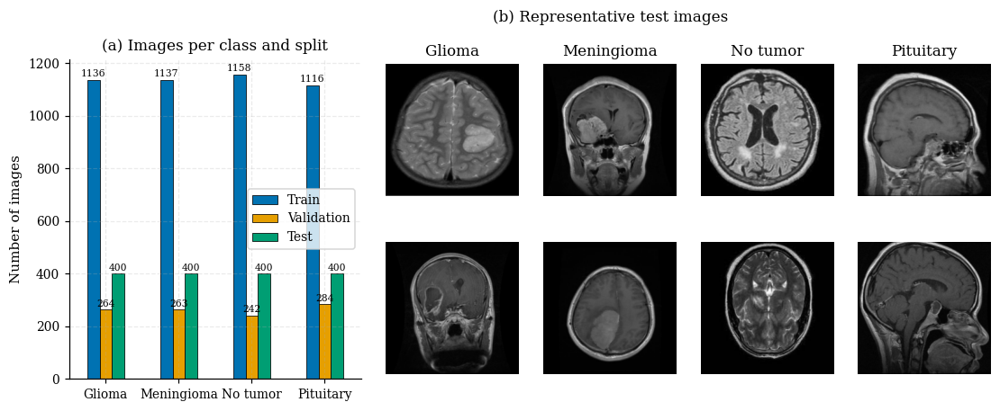

In [7]:
fig = plt.figure(figsize=(12, 4.2))
gs = gridspec.GridSpec(2, 5, width_ratios=[2.2, 1, 1, 1, 1], figure=fig, wspace=0.15, hspace=0.25)
ax = fig.add_subplot(gs[:, 0])
split_counts.drop("Total").plot(kind="bar", ax=ax, color=CB[:3], edgecolor="black", linewidth=0.5)
ax.set_title("(a) Images per class and split"); ax.set_ylabel("Number of images"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for cont in ax.containers: ax.bar_label(cont, fontsize=7, padding=1)
rng = np.random.RandomState(0)
for k in range(NC):
    idx = rng.choice(np.where(y_test == k)[0], 2, replace=False)
    for r in range(2):
        a = fig.add_subplot(gs[r, k + 1]); img, _ = test_raw[idx[r]]
        a.imshow(img.permute(1, 2, 0).numpy()); a.axis("off")
        if r == 0: a.set_title(CLS_LABEL[k])
fig.text(0.58, 0.97, "(b) Representative test images", ha="center", fontsize=11)
savefig(fig, "fig01_dataset"); plt.show()

### Figure 2 — Pseudo-patient grouping and the leakage audit *(new in v2)*

**How to read it.**

* **(a) Group-size distribution.** If every image were an independent patient, all mass would sit at size 1. A long
  tail means many images are near-duplicates of each other — precisely the structure that inflates a random-split
  validation score. The annotation reports what fraction of training images belong to a multi-image group.
* **(b) An example cluster.** One pseudo-patient group shown as images. They should look like the *same* scan: this
  is the visual sanity check that the hash threshold is not merging unrelated patients. If these look like four
  different people, lower `dhash_threshold`.
* **(c) Distance from each test image to its nearest training image.** The dashed line is the near-duplicate
  threshold. Mass to the **left** of the line is measured train↔test contamination; it is what you must report and
  cannot remove, because the test partition is fixed by the dataset authors. Mass concentrated to the right is
  reassuring.

**Suggested paper sentence.** *"Perceptual-hash clustering identified G pseudo-patient groups among the N training
images; x% of test images had a near-duplicate (Hamming distance ≤ 5) within the training partition, which we report
as a residual, unavoidable source of optimism in the test estimate."*

  saved -> figures/fig02_pseudo_patient_leakage.png / .pdf


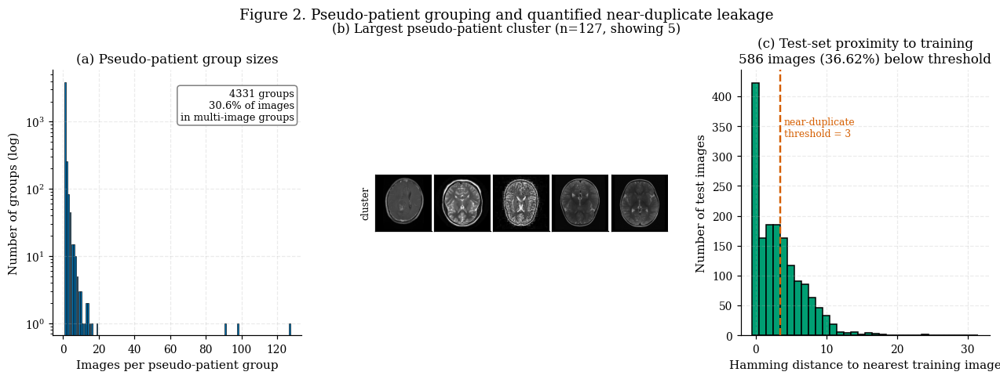

In [8]:
fig = plt.figure(figsize=(14, 4.0))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.15, 1.35, 1.15], wspace=0.28)

# (a) group-size distribution
a = fig.add_subplot(gs[0])
vals, cnts = np.unique(gsize, return_counts=True)
a.bar(vals, cnts, color=CB[0], edgecolor="black", lw=0.4)
a.set_yscale("log")
a.set(xlabel="Images per pseudo-patient group", ylabel="Number of groups (log)",
      title="(a) Pseudo-patient group sizes")
a.text(0.97, 0.93, f"{n_groups} groups\n{(gsize[groups] > 1).mean()*100:.1f}% of images\nin multi-image groups",
       transform=a.transAxes, ha="right", va="top", fontsize=8.5,
       bbox=dict(boxstyle="round", fc="white", ec="grey"))

# (b) an example cluster (largest group, capped at 5 images)
big = int(np.argmax(gsize))
members = np.where(groups == big)[0][:5]
sub = gridspec.GridSpecFromSubplotSpec(1, len(members), subplot_spec=gs[1], wspace=0.05)
for j, m in enumerate(members):
    aa = fig.add_subplot(sub[j])
    aa.imshow(raw_tf(datasets.folder.default_loader(full_train.samples[m][0])).permute(1, 2, 0))
    aa.set_xticks([]); aa.set_yticks([])
    if j == 0: aa.set_ylabel("cluster", fontsize=8)
fig.text(0.50, 0.99, f"(b) Largest pseudo-patient cluster (n={gsize[big]}, showing {len(members)})",
         ha="center", fontsize=10.5)

# (c) test-to-train nearest distance
a = fig.add_subplot(gs[2])
a.hist(min_dist_test, bins=np.arange(0, 33) - 0.5, color=CB[2], edgecolor="black", lw=0.4)
a.axvline(CONFIG["dhash_threshold"] + 0.5, color=CB[3], ls="--", lw=1.6)
a.text(CONFIG["dhash_threshold"] + 1.0, a.get_ylim()[1] * 0.75,
       f"near-duplicate\nthreshold = {CONFIG['dhash_threshold']}", fontsize=8, color=CB[3])
a.set(xlabel="Hamming distance to nearest training image", ylabel="Number of test images",
      title=f"(c) Test-set proximity to training\n{near_dup_test} images ({near_dup_test/len(H_test)*100:.2f}%) below threshold")
fig.suptitle("Figure 2. Pseudo-patient grouping and quantified near-duplicate leakage", y=1.06)
savefig(fig, "fig02_pseudo_patient_leakage"); plt.show()

### Figure 3 — Training-time augmentation

**How to read it.** Each row is one training image followed by five independent draws from the augmentation
pipeline: rotation (±15°), translation and scaling, brightness/contrast jitter, occasional blur, and Gaussian noise
added **in pixel space before normalisation**. The augmentation policy is deliberately mild — aggressive geometric
distortion of an MRI can move a lesion outside the field of view and create label noise.

This figure also does double duty: it is the visual justification for the robustness results in §11. A model trained
under brightness jitter should be, and is, nearly immune to the intensity-scaling corruption.

  saved -> figures/fig03_augmentation.png / .pdf


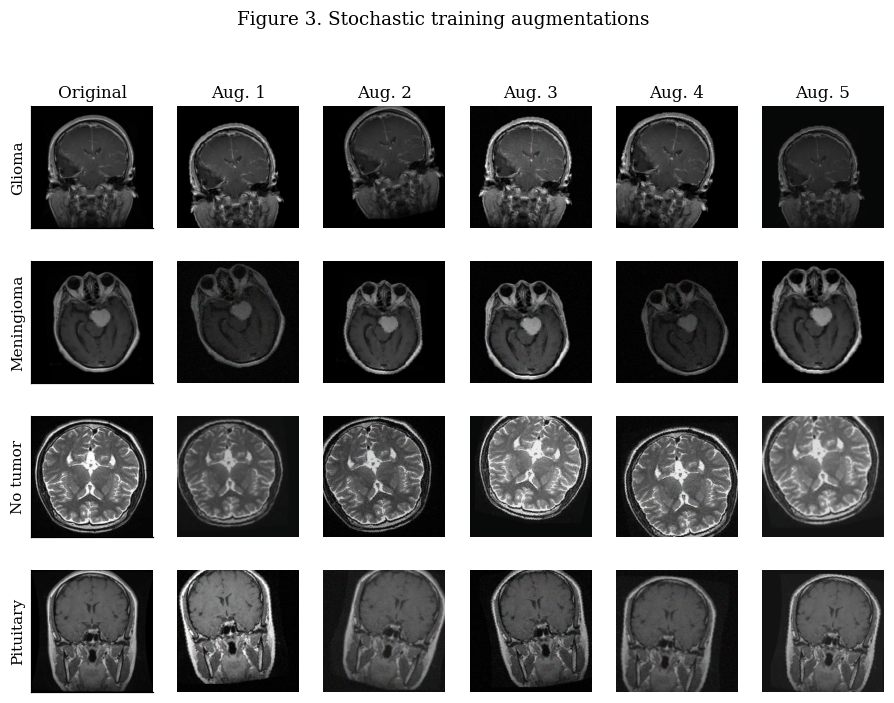

In [9]:
def denorm(t):  # normalised tensor (3,H,W) -> numpy image in [0,1]
    return np.clip(t.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN), 0, 1)

fig, axes = plt.subplots(NC, 6, figsize=(10, 7))
for k in range(NC):
    i = tr_idx[np.where(targets[tr_idx] == k)[0][0]]
    axes[k, 0].imshow(raw_tf(datasets.folder.default_loader(full_train.samples[i][0])).permute(1, 2, 0))
    axes[k, 0].set_ylabel(CLS_LABEL[k]); axes[k, 0].set_xticks([]); axes[k, 0].set_yticks([])
    for j in range(1, 6):
        axes[k, j].imshow(denorm(full_train[i][0])); axes[k, j].axis("off")
axes[0, 0].set_title("Original"); [axes[0, j].set_title(f"Aug. {j}") for j in range(1, 6)]
fig.suptitle("Figure 3. Stochastic training augmentations", y=1.0)
savefig(fig, "fig03_augmentation"); plt.show()

## 4. The three loss functions: what each one actually changes

All three arms share the same backbone, optimiser, schedule, augmentation and seed control. **Only the loss
differs.** That is what makes the comparison an ablation rather than a benchmark.

### 4.1 Cross-entropy (the reference)

$$\mathcal{L}_{\mathrm{CE}} = -\log p_t$$

where $p_t$ is the softmax probability assigned to the true class. Its gradient with respect to the true-class logit
is $p_t - 1$, which never vanishes: even at $p_t = 0.99$ the optimiser is still rewarded for pushing the logit
higher. This is the standard explanation for why modern networks become **over-confident** (Guo et al., 2017).

### 4.2 Focal loss (Lin et al., 2017)

$$\mathcal{L}_{\mathrm{FL}} = -\alpha\,(1-p_t)^{\gamma}\,\log p_t$$

The **modulating factor** $(1-p_t)^\gamma$ shrinks the loss of already-confident examples: at $p_t = 0.9$ and
$\gamma = 2$ the loss is $0.01\times$ cross-entropy. Training therefore keeps spending capacity on hard examples.
Mukhoti et al. (NeurIPS 2020) showed this acts as an implicit entropy regulariser and usually lowers ECE.

**The critical caveat for this dataset.** Focal loss was designed for **extreme foreground/background imbalance** in
object detection (thousands of easy negatives per positive). Here the four classes contain exactly 1,190 training
images each. There is no imbalance for the modulating factor to counteract, so the mechanism that makes focal loss
valuable elsewhere simply does not apply. We keep the arm to **test** this, not to assume it.

### 4.3 Class-weighted cross-entropy (new in v2)

$$\mathcal{L}_{\mathrm{wCE}} = -w_{y}\log p_t, \qquad w_{\text{glioma}} = \lambda,\;\; w_{\text{other}} = 1$$

This is **not** an imbalance correction. It is a **cost-sensitive** objective: it declares that a training error on
a glioma image is $\lambda$ times as expensive as an error on any other class. With $\lambda = 2$ the optimiser
trades roughly two non-glioma mistakes for one avoided glioma mistake, which is the direction clinical practice
prefers — a missed glioma is a false negative on an aggressive tumor, while a false alarm costs a second read.

This directly targets the weakest number in v1 (glioma recall 81.75%) with a mechanism that *matches the actual
problem*, whereas focal loss targeted a problem this dataset does not have.

### Figure 4 — Loss geometry: why each mechanism behaves as it does

**How to read it.** (a) loss value against $p_t$; (b) the modulating factor alone; (c) the magnitude of the gradient
with respect to the true-class logit — the quantity that actually drives learning. The grey band marks the
"well-classified" region $p_t > 0.6$, where most training examples sit after a few epochs. Cross-entropy ($\gamma=0$)
keeps a substantial gradient there; $\gamma = 2$ nearly silences it. Panel (d) contrasts this with class weighting,
which rescales the **whole** curve for one class instead of reshaping it — a vertical stretch, not a change of shape.

Class weights: {'Glioma': 2.0, 'Meningioma': 1.0, 'No tumor': 1.0, 'Pituitary': 1.0}
Sanity check passed: FocalLoss(gamma=0) == CrossEntropyLoss
  saved -> figures/fig04_loss_theory.png / .pdf


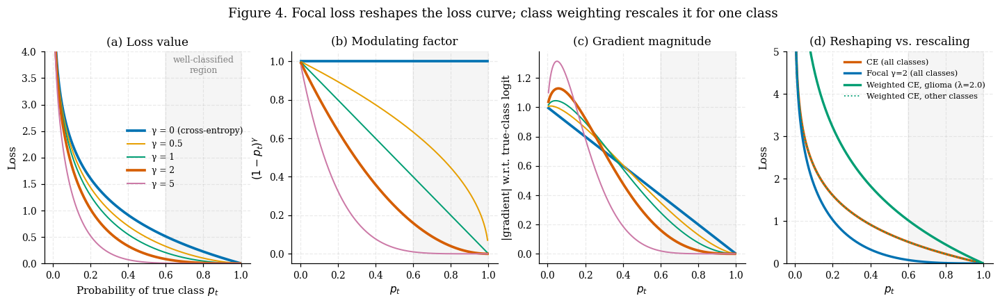

At p_t = 0.9 the focal loss (γ=2) is 0.01x cross-entropy; at p_t = 0.5 it is 0.25x.


In [10]:
class FocalLoss(nn.Module):
    """Multi-class focal loss (Lin et al., 2017). gamma=0 reduces exactly to cross-entropy."""
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__(); self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, target):
        logits = logits.float()                       # numerically safe under AMP
        ce = F.cross_entropy(logits, target, reduction="none")
        pt = torch.exp(-ce)
        return (self.alpha * (1 - pt) ** self.gamma * ce).mean()

# class-weight vector: cost-sensitive, NOT an imbalance correction
CLASS_W = torch.ones(NC, device=device)
CLASS_W[GLIOMA] = CONFIG["glioma_weight"]
print("Class weights:", {CLS_LABEL[k]: float(CLASS_W[k]) for k in range(NC)})

def make_criterion(arm):
    if arm == "focal": return FocalLoss(CONFIG["focal_alpha"], CONFIG["focal_gamma"])
    if arm == "ce":    return nn.CrossEntropyLoss()
    if arm == "ce_w":  return nn.CrossEntropyLoss(weight=CLASS_W)
    raise ValueError(arm)

# ---- quick numerical sanity checks on the loss implementations ----
_z = torch.tensor([[3.0, 0.5, 0.2, 0.1], [0.2, 2.0, 0.1, 0.3]])
_y = torch.tensor([0, 1])
assert abs(FocalLoss(1.0, 0.0)(_z, _y).item() - F.cross_entropy(_z, _y).item()) < 1e-6, "gamma=0 must equal CE"
print("Sanity check passed: FocalLoss(gamma=0) == CrossEntropyLoss")

# ---- Figure 4 ----
p = np.linspace(0.005, 0.995, 400)
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
for i, g in enumerate([0, 0.5, 1, 2, 5]):
    lab = "γ = 0 (cross-entropy)" if g == 0 else f"γ = {g}"
    lw = 2.4 if g in (0, 2) else 1.3
    ax[0].plot(p, (1 - p) ** g * -np.log(p), color=CB[i], lw=lw, label=lab)
    ax[1].plot(p, (1 - p) ** g, color=CB[i], lw=lw, label=lab)
    grad = g * p * (1 - p) ** g * np.log(p) - (1 - p) ** (g + 1)      # dFL/dz_t (exact, softmax)
    ax[2].plot(p, np.abs(grad), color=CB[i], lw=lw, label=lab)
ax[0].set(xlabel="Probability of true class $p_t$", ylabel="Loss", title="(a) Loss value", ylim=(0, 4))
ax[1].set(xlabel="$p_t$", ylabel="$(1-p_t)^\\gamma$", title="(b) Modulating factor")
ax[2].set(xlabel="$p_t$", ylabel="|gradient| w.r.t. true-class logit", title="(c) Gradient magnitude")
for a in ax[:3]: a.axvspan(0.6, 1.0, color="grey", alpha=0.08)
ax[0].text(0.8, 3.6, "well-classified\nregion", ha="center", fontsize=8, color="grey")
ax[0].legend(frameon=False, fontsize=8)

# (d) weighting vs focal: different mechanisms
ax[3].plot(p, -np.log(p), color=LOSS_COL["ce"], lw=2.2, label="CE (all classes)")
ax[3].plot(p, (1 - p) ** 2 * -np.log(p), color=LOSS_COL["focal"], lw=2.2, label="Focal γ=2 (all classes)")
ax[3].plot(p, CONFIG["glioma_weight"] * -np.log(p), color=LOSS_COL["ce_w"], lw=2.2, ls="-",
           label=f"Weighted CE, glioma (λ={CONFIG['glioma_weight']})")
ax[3].plot(p, -np.log(p), color=LOSS_COL["ce_w"], lw=1.2, ls=":", label="Weighted CE, other classes")
ax[3].axvspan(0.6, 1.0, color="grey", alpha=0.08)
ax[3].set(xlabel="$p_t$", ylabel="Loss", title="(d) Reshaping vs. rescaling", ylim=(0, 5))
ax[3].legend(frameon=False, fontsize=7.5)
fig.suptitle("Figure 4. Focal loss reshapes the loss curve; class weighting rescales it for one class", y=1.04)
savefig(fig, "fig04_loss_theory"); plt.show()
print(f"At p_t = 0.9 the focal loss (γ=2) is {(1-0.9)**2:.2f}x cross-entropy; at p_t = 0.5 it is {(1-0.5)**2:.2f}x.")

## 5. Training procedure (identical across arms)

| Component | Setting | Rationale |
|---|---|---|
| Backbone | ConvNeXt-T, ImageNet-1K pretrained | Selected on validation macro-F1 (§7b); 27.8 M parameters trains on one T4 |
| Optimiser | AdamW, lr 1e-4, weight decay 1e-4 | Tuned to the backbone family; ConvNeXt tolerates (and needs) a larger step than a plain ViT |
| Schedule | Cosine annealing to 1e-7 over 20 epochs | Smooth decay; no step-boundary artefacts in the learning curves |
| Precision | Mixed (AMP), loss computed in fp32 | ~2× speed; the fp32 cast prevents focal-loss underflow at small $(1-p_t)^\gamma$ |
| Gradient clipping | Global norm 1.0 | Guards against occasional large-gradient batches; applied identically to every architecture |
| Early stopping | Validation macro-F1, patience 5, best checkpoint restored | Macro-F1 (not accuracy) so a collapse in one class is punished |
| Model selection | **Validation only** | The test partition is touched exactly once, at final evaluation |

**A note that belongs in the thesis.** Training-loss *values* are not comparable across arms — focal loss is
bounded above by cross-entropy by construction, and weighted CE is inflated by $\lambda$ on one class. Only
accuracy, macro-F1 and calibration metrics may be compared between arms. Reviewers catch this.

In [11]:
def build_model():
    return timm.create_model(CONFIG["model"], pretrained=CONFIG["pretrained"], num_classes=NC,
                             drop_rate=CONFIG["drop_rate"]).to(device)

@torch.no_grad()
def predict_logits(model, dl):
    model.eval(); out = []
    for x, _ in dl:
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            out.append(model(x.to(device, non_blocking=True)).float().cpu())
    return torch.cat(out).numpy()

def train_model(arm, seed):
    set_seed(seed)
    model = build_model()
    crit = make_criterion(arm)
    opt = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"], eta_min=CONFIG["eta_min"])
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    tl = loader(train_ds, True, seed)
    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1", "val_glioma_recall", "lr"]}
    best_f1, best_ep, bad = -1, 0, 0
    ckpt = os.path.join(CKPT_DIR, f"{arm}_seed{seed}.pt")
    t0 = time.time()
    crit_cpu = make_criterion(arm)
    if arm == "ce_w": crit_cpu = nn.CrossEntropyLoss(weight=CLASS_W.cpu())
    for ep in range(CONFIG["epochs"]):
        model.train(); tot, correct, n = 0.0, 0, 0
        for x, y in tl:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(x)
            loss = crit(logits.float(), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            scaler.step(opt); scaler.update()
            tot += loss.item() * len(y); correct += (logits.argmax(1) == y).sum().item(); n += len(y)
        vlog = predict_logits(model, val_loader)
        vloss = crit_cpu(torch.tensor(vlog), torch.tensor(y_val)).item()
        vpred = vlog.argmax(1)
        vf1 = f1_score(y_val, vpred, average="macro")
        vgr = recall_of(y_val, vpred, GLIOMA)
        for k, v in zip(hist, [tot / n, correct / n, vloss, accuracy_score(y_val, vpred), vf1, vgr,
                               sch.get_last_lr()[0]]):
            hist[k].append(v)
        flag = ""
        if vf1 > best_f1:
            best_f1, best_ep, bad = vf1, ep + 1, 0; torch.save(model.state_dict(), ckpt); flag = " *"
        else:
            bad += 1
        print(f"  [{LOSS_NAME[arm]:13s} seed {seed}] ep {ep+1:2d} | train loss {tot/n:.4f} acc {correct/n:.4f}"
              f" | val loss {vloss:.4f} acc {hist['val_acc'][-1]:.4f} F1 {vf1:.4f} gliomaR {vgr:.4f}{flag}")
        sch.step()
        if bad >= CONFIG["patience"] and (ep + 1) >= CONFIG["min_epochs"]:
            print(f"  early stop at epoch {ep+1}; best epoch {best_ep} (val F1 {best_f1:.4f})"); break
    model.load_state_dict(torch.load(ckpt, map_location=device))
    hist.update(best_epoch=best_ep, best_val_f1=best_f1, minutes=(time.time() - t0) / 60)
    return model, hist

def recall_of(y_true, y_pred, k):
    m = y_true == k
    return float((y_pred[m] == k).mean()) if m.any() else np.nan

print("Training utilities ready.")

Training utilities ready.


### 5.1 Run the ablation: {Focal, CE, Weighted CE} × 5 seeds

For every run we store the **validation logits** and the **test logits**. Every downstream analysis — calibration,
temperature scaling, threshold tuning, bootstrap CIs — is computed from those two arrays, which means the analysis
is fully reproducible without retraining and no result can silently depend on a model still sitting in GPU memory.

Only the `MAIN_SEED` models are kept in memory (three ConvNeXt-T models ≈ 335 MB), because Grad-CAM, robustness
and OOD need live forward passes.

In [12]:
RUNS = {}      # (arm, seed) -> dict(hist, val_logits, test_logits)
MODELS = {}    # arm -> model (MAIN_SEED only)
t_all = time.time()
for seed in CONFIG["SEEDS"]:
    for arm in ARMS:
        print(f"\n=== Training {LOSS_NAME[arm]} | seed {seed} ===")
        m, h = train_model(arm, seed)
        RUNS[(arm, seed)] = {"hist": h,
                             "val_logits": predict_logits(m, val_loader),
                             "test_logits": predict_logits(m, test_loader)}
        if seed == CONFIG["MAIN_SEED"]:
            MODELS[arm] = m
        else:
            del m; torch.cuda.empty_cache()
n_params = sum(p.numel() for p in MODELS[ARMS[0]].parameters())
print(f"\nAll {len(RUNS)} runs finished in {(time.time()-t_all)/60:.1f} min")
print(f"Trainable parameters: {n_params/1e6:.2f} M")


=== Training Focal Loss | seed 42 ===


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  [Focal Loss    seed 42] ep  1 | train loss 0.3000 acc 0.7878 | val loss 0.0706 acc 0.9554 F1 0.9559 gliomaR 0.9621 *
  [Focal Loss    seed 42] ep  2 | train loss 0.0874 acc 0.9320 | val loss 0.0919 acc 0.9392 F1 0.9406 gliomaR 0.9470
  [Focal Loss    seed 42] ep  3 | train loss 0.0569 acc 0.9562 | val loss 0.1075 acc 0.9421 F1 0.9429 gliomaR 0.9924
  [Focal Loss    seed 42] ep  4 | train loss 0.0339 acc 0.9743 | val loss 0.0433 acc 0.9677 F1 0.9679 gliomaR 0.9735 *
  [Focal Loss    seed 42] ep  5 | train loss 0.0263 acc 0.9809 | val loss 0.0481 acc 0.9782 F1 0.9783 gliomaR 0.9697 *
  [Focal Loss    seed 42] ep  6 | train loss 0.0228 acc 0.9826 | val loss 0.0691 acc 0.9725 F1 0.9727 gliomaR 0.9848
  [Focal Loss    seed 42] ep  7 | train loss 0.0125 acc 0.9899 | val loss 0.0563 acc 0.9658 F1 0.9657 gliomaR 0.9924
  [Focal Loss    seed 42] ep  8 | train loss 0.0111 acc 0.9912 | val loss 0.0545 acc 0.9801 F1 0.9802 gliomaR 0.9773 *
  [Focal Loss    seed 42] ep  9 | train loss 0.0042 acc 

### Figure 5 — Learning curves across arms and seeds

**How to read it.** Solid lines are the mean over seeds, shaded bands ±1 standard deviation, so the width of a band
is the run-to-run instability of that arm. Four panels:

* **(a) Training loss** — compare *shape* only, never level (see the note in §5).
* **(b) Validation loss** — same caveat; it is shown because a rising validation loss while F1 still improves is the
  classic signature of a model becoming over-confident rather than more accurate, which is exactly the phenomenon
  this thesis studies.
* **(c) Validation macro-F1** — the model-selection criterion. Vertical dotted lines mark the selected epochs.
* **(d) Validation glioma recall** — the clinically decisive curve. If the weighted-CE arm works as intended, its
  curve should sit visibly **above** the other two here while (c) stays comparable.

A small train–validation gap after the group-aware split is now a meaningful statement about generalisation; under
v1's random split it was partly an artefact of near-duplicate leakage.

  saved -> figures/fig05_learning_curves.png / .pdf


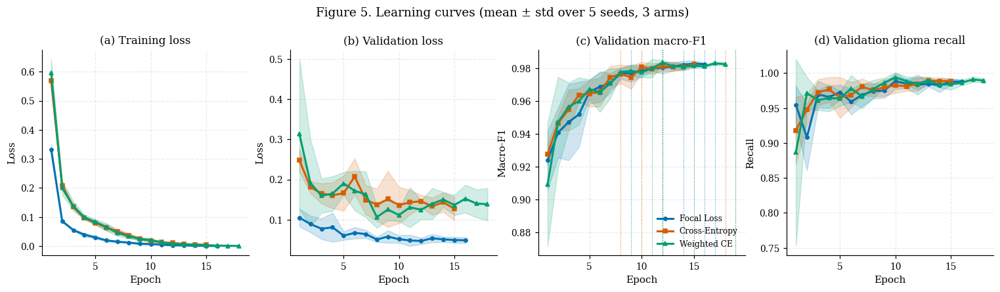

          arm  seed  best_epoch  best_val_F1  final_val_glioma_recall  minutes
   Focal Loss    42          14       0.9849                   0.9886      9.9
Cross-Entropy    42          18       0.9848                   0.9924      9.4
  Weighted CE    42          11       0.9848                   0.9886      8.5
   Focal Loss    43          17       0.9867                   0.9848      9.4
Cross-Entropy    43          10       0.9868                   0.9924      8.0
  Weighted CE    43          12       0.9858                   0.9924      8.9
   Focal Loss    44           9       0.9841                   0.9924      7.5
Cross-Entropy    44          12       0.9829                   0.9848      8.9
  Weighted CE    44          19       0.9857                   0.9924      9.5
   Focal Loss    45          15       0.9839                   0.9848      9.4
Cross-Entropy    45           8       0.9839                   0.9848      7.1
  Weighted CE    45          12       0.9839        

In [13]:
def stack(key, arm):
    seqs = [RUNS[(arm, s)]["hist"][key] for s in CONFIG["SEEDS"]]
    L = min(len(q) for q in seqs)
    return np.array([q[:L] for q in seqs])

panels = [("train_loss", "(a) Training loss", "Loss"),
          ("val_loss", "(b) Validation loss", "Loss"),
          ("val_f1", "(c) Validation macro-F1", "Macro-F1"),
          ("val_glioma_recall", "(d) Validation glioma recall", "Recall")]
fig, ax = plt.subplots(1, 4, figsize=(17, 3.7))
for arm in ARMS:
    c = LOSS_COL[arm]
    for a, (key, ttl, ylab) in zip(ax, panels):
        A = stack(key, arm); ep = np.arange(1, A.shape[1] + 1)
        a.plot(ep, A.mean(0), color=c, lw=2, label=LOSS_NAME[arm], marker=LOSS_MARK[arm], ms=3.5)
        a.fill_between(ep, A.mean(0) - A.std(0), A.mean(0) + A.std(0), color=c, alpha=0.18)
        a.set(title=ttl, xlabel="Epoch", ylabel=ylab)
    for s in CONFIG["SEEDS"]:
        ax[2].axvline(RUNS[(arm, s)]["hist"]["best_epoch"], color=c, ls=":", lw=0.7, alpha=0.8)
ax[2].legend(frameon=False, loc="lower right", fontsize=8)
fig.suptitle(f"Figure 5. Learning curves (mean ± std over {len(CONFIG['SEEDS'])} seeds, {len(ARMS)} arms)", y=1.04)
savefig(fig, "fig05_learning_curves"); plt.show()

TRAIN_TAB = pd.DataFrame([{"arm": LOSS_NAME[a], "seed": s,
                           "best_epoch": RUNS[(a, s)]["hist"]["best_epoch"],
                           "best_val_F1": round(RUNS[(a, s)]["hist"]["best_val_f1"], 4),
                           "final_val_glioma_recall": round(RUNS[(a, s)]["hist"]["val_glioma_recall"][-1], 4),
                           "minutes": round(RUNS[(a, s)]["hist"]["minutes"], 1)} for (a, s) in RUNS])
print(TRAIN_TAB.to_string(index=False))

# ---------------------------------------------------------------------------
# REFERENCE ARM: fixed A PRIORI, not selected.
#
# Earlier versions picked the primary arm by validation macro-F1. On this dataset that
# criterion saturates (~0.985), so the ranking flipped between runs on margins of ~0.0004
# with p ~ 0.7 - i.e. the "selection" was reading noise. Worse, it could select the arm with
# the WORST glioma recall while the paper's stated target is glioma recall.
#
# Cross-entropy is therefore fixed as the reference objective, exactly as the standard
# baseline it is, and focal loss and weighted CE are reported as ablations against it.
# Nothing is chosen from the data, so nothing can be chosen wrongly.
# ---------------------------------------------------------------------------
MAIN_ARM = "ce"
val_f1 = {a: np.array([RUNS[(a, s)]["hist"]["best_val_f1"] for s in CONFIG["SEEDS"]]) for a in ARMS}
val_f1_mean = {a: float(v.mean()) for a, v in val_f1.items()}
ranked = sorted(val_f1_mean, key=val_f1_mean.get, reverse=True)
print("\nMean best validation macro-F1 per arm (reported, NOT used for selection):",
      {LOSS_NAME[a]: round(val_f1_mean[a], 4) for a in ranked})
print(f"-> Reference arm fixed a priori: {LOSS_NAME[MAIN_ARM]}")

spread = max(val_f1_mean.values()) - min(val_f1_mean.values())
best, second = ranked[0], ranked[1]
d_sel = val_f1[best] - val_f1[second]
t_sel, p_sel = stats.ttest_rel(val_f1[best], val_f1[second]) if len(CONFIG["SEEDS"]) > 1 else (np.nan, 1.0)
SELECTION = {"rule": "cross-entropy fixed a priori as the reference objective; no data-driven selection",
             "reference_arm": LOSS_NAME[MAIN_ARM],
             "val_f1_mean": {LOSS_NAME[a]: round(val_f1_mean[a], 4) for a in ARMS},
             "val_f1_spread": float(spread),
             "top_two_margin": float(d_sel.mean()), "top_two_p": float(p_sel),
             "mean_val_f1_best": val_f1_mean[best]}
print(f"   spread across arms: {spread:.4f}; top-two margin {d_sel.mean():+.4f} (p = {p_sel:.3f})")
if val_f1_mean[best] > 0.985:
    print(f"   NOTE: validation macro-F1 reaches {val_f1_mean[best]:.4f}, close to the ceiling. This is "
          "precisely why the reference arm is fixed rather than selected. The temperature and decision "
          "threshold are still fitted on this set, so their transfer to the test distribution is "
          "reported explicitly in Sections 10 and 9 rather than assumed.")

# Glioma recall is the clinical target, so report where each arm stands on the validation
# version of THAT metric - as evidence, not as a selection rule.
val_gr = {a: np.mean([RUNS[(a, s)]["hist"]["val_glioma_recall"][-1] for s in CONFIG["SEEDS"]]) for a in ARMS}
print("   validation glioma recall by arm:", {LOSS_NAME[a]: round(v, 4) for a, v in val_gr.items()})

## 6. Metric definitions

Discrimination and calibration answer different questions, and a Q1 reviewer will expect both, with uncertainty.

* **ECE** (15 equal-width bins): $\mathrm{ECE}=\sum_b \frac{|B_b|}{N}\,\bigl|\mathrm{acc}(B_b)-\mathrm{conf}(B_b)\bigr|$ — the average gap between stated confidence and observed accuracy.
* **MCE**: the largest single-bin gap, i.e. the worst-case miscalibration.
* **Brier score**: mean squared error between the full probability vector and the one-hot label. A **proper scoring rule** — it cannot be gamed by distorting confidence alone.
* **NLL**: negative log-likelihood of the true class; also proper, and far more sensitive to confident mistakes.
* **Class-wise ECE**: ECE on one-vs-rest probabilities, which exposes miscalibration concentrated in a single class.
* **95% CIs**: non-parametric bootstrap over test images (1,000 resamples).
* **Paired bootstrap**: the *same* resampled indices are applied to both arms, so the CI is on the **difference**. This is strictly stronger evidence than two overlapping single-arm CIs, and it is the analysis most often missing from papers in this area.
* **Temperature scaling** (Guo et al., 2017): a single scalar $T$ fitted by LBFGS on **validation** logits, then applied to test logits as $\mathrm{softmax}(z/T)$. It cannot change any prediction, only its confidence — so accuracy is invariant and only calibration moves.

In [14]:
def softmax_np(z, T=1.0):
    z = z / T; z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

MCE_MIN_BIN = 20     # a bin holding fewer images than this cannot support an MCE claim

def ece_mce(probs, y, n_bins=15, min_bin=None):
    """ECE over all populated bins; MCE over bins holding at least `min_bin` images.
    An unrestricted MCE is routinely dominated by a bin containing a handful of images,
    which makes it an artefact of binning rather than a property of the model."""
    min_bin = MCE_MIN_BIN if min_bin is None else min_bin
    conf, pred = probs.max(1), probs.argmax(1); acc = (pred == y).astype(float)
    edges = np.linspace(0, 1, n_bins + 1); ece, mce = 0.0, 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            gap = abs(acc[m].mean() - conf[m].mean())
            ece += m.mean() * gap
            if m.sum() >= min_bin:
                mce = max(mce, gap)
    return ece, mce

def classwise_ece(probs, y, n_bins=15):
    out = []
    for k in range(probs.shape[1]):
        pk, yk = probs[:, k], (y == k).astype(float)
        edges = np.linspace(0, 1, n_bins + 1); e = 0.0
        for lo, hi in zip(edges[:-1], edges[1:]):
            m = (pk > lo) & (pk <= hi) if lo > 0 else (pk >= lo) & (pk <= hi)
            if m.any(): e += m.mean() * abs(yk[m].mean() - pk[m].mean())
        out.append(e)
    return np.array(out)

def brier(probs, y): return np.mean(np.sum((probs - np.eye(probs.shape[1])[y]) ** 2, 1))
def nll(probs, y):   return -np.mean(np.log(np.clip(probs[np.arange(len(y)), y], 1e-12, 1)))

def all_metrics(probs, y):
    pred = probs.argmax(1); e, m = ece_mce(probs, y, CONFIG["ece_bins"])
    return {"accuracy": accuracy_score(y, pred), "macro_f1": f1_score(y, pred, average="macro"),
            "glioma_recall": recall_of(y, pred, GLIOMA),
            "ece": e, "mce": m, "brier": brier(probs, y), "nll": nll(probs, y),
            "macro_auroc": roc_auc_score(label_binarize(y, classes=range(probs.shape[1])), probs, average="macro")}

def bootstrap_ci(probs, y, fn, n=1000, seed=0):
    rng = np.random.RandomState(seed); vals = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y)); vals.append(fn(probs[i], y[i]))
    return np.percentile(vals, [2.5, 97.5])

def paired_bootstrap_diff(pA, pB, y, fn, n=1000, seed=0):
    """CI of fn(A) - fn(B) using identical resamples for both arms."""
    rng = np.random.RandomState(seed); d = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        d.append(fn(pA[i], y[i]) - fn(pB[i], y[i]))
    d = np.asarray(d)
    return d.mean(), np.percentile(d, [2.5, 97.5]), float((d <= 0).mean())

def fit_temperature(logits, y):
    lt = torch.tensor(logits, dtype=torch.float32); yt = torch.tensor(y)
    log_t = torch.zeros(1, requires_grad=True)
    opt_t = torch.optim.LBFGS([log_t], lr=0.1, max_iter=200)
    def closure():
        opt_t.zero_grad(); l = F.cross_entropy(lt / log_t.exp(), yt); l.backward(); return l
    opt_t.step(closure)
    return float(log_t.exp())

# ---- validate the metric code on synthetic data with known answers ----
_p = np.array([[0.9, 0.1], [0.8, 0.2], [0.6, 0.4]]); _y = np.array([0, 0, 1])
_e, _m = ece_mce(_p, _y, n_bins=10)
assert 0 <= _e <= 1 and 0 <= _m <= 1
assert abs(brier(np.eye(2)[[0, 1]], np.array([0, 1]))) < 1e-9, "perfect prediction must give Brier 0"
print("Metric functions ready and self-checked.")

Metric functions ready and self-checked.


## 7. Ablation results: three arms, five seeds

Each run is evaluated **twice**: on raw softmax outputs and after temperature scaling. The second evaluation is the
one reviewers care about, because it answers the obvious objection to any calibration claim: *"would a single scalar
fitted on validation data have achieved the same thing?"* If a loss function's calibration advantage vanishes under
temperature scaling, the advantage was real but not useful — and saying so plainly is what separates a thesis from
a brochure.

Statistical treatment:

* **Paired across seeds** — arm A and arm B with the same seed share the data order and initialisation, so the
  seed-wise difference is a matched pair.
* **Three pairwise comparisons** (Focal vs CE, Focal vs wCE, CE vs wCE) are corrected with **Holm–Bonferroni**.
  Running three uncorrected *t*-tests and reporting the smallest *p* is a well-known way to manufacture significance.
* **Report the effect size, not just the *p*-value.** With five seeds, a non-significant result is often just low
  power; the mean difference and its spread carry more information.

In [15]:
rows = []
for (a, s), R in RUNS.items():
    T = fit_temperature(R["val_logits"], y_val); R["T"] = T
    for tag, TT in [("uncalibrated", 1.0), ("temp-scaled", T)]:
        met = all_metrics(softmax_np(R["test_logits"], TT), y_test)
        rows.append({"arm": LOSS_NAME[a], "arm_key": a, "seed": s, "calibration": tag, "T": round(TT, 3), **met})
ABL = pd.DataFrame(rows)
ABL.to_csv(os.path.join(OUT_DIR, "ablation_all_runs.csv"), index=False)

MET_COLS = ["accuracy", "macro_f1", "glioma_recall", "ece", "mce", "brier", "nll", "macro_auroc", "T"]
agg = ABL.groupby(["arm", "calibration"])[MET_COLS].agg(["mean", "std"])
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("Test-set metrics, mean and std over seeds:\n"); print(agg)

Test-set metrics, mean and std over seeds:

                           accuracy        macro_f1        glioma_recall  \
                               mean    std     mean    std          mean   
arm           calibration                                                  
Cross-Entropy temp-scaled    0.9520 0.0027   0.9514 0.0027        0.8390   
              uncalibrated   0.9520 0.0027   0.9514 0.0027        0.8390   
Focal Loss    temp-scaled    0.9546 0.0041   0.9538 0.0044        0.8385   
              uncalibrated   0.9546 0.0041   0.9538 0.0044        0.8385   
Weighted CE   temp-scaled    0.9550 0.0048   0.9543 0.0051        0.8395   
              uncalibrated   0.9550 0.0048   0.9543 0.0051        0.8395   

                                     ece           mce         brier         \
                              std   mean    std   mean    std   mean    std   
arm           calibration                                                     
Cross-Entropy temp-scaled  0.0074 

In [16]:
# ---------- paired seed-level tests with Holm-Bonferroni correction ----------
pairs = list(itertools.combinations(ARMS, 2))
stat_rows = []
for metric in ["accuracy", "macro_f1", "glioma_recall", "ece"]:
    cal = "uncalibrated"
    sub = ABL[ABL.calibration == cal].pivot(index="seed", columns="arm_key", values=metric)
    raw_p, recs = [], []
    for a, b in pairs:
        d = (sub[a] - sub[b]).values
        if len(d) >= 2 and np.std(d) > 0:
            t, pv = stats.ttest_rel(sub[a], sub[b])
        else:
            t, pv = np.nan, 1.0
        raw_p.append(pv)
        recs.append({"metric": metric, "comparison": f"{LOSS_NAME[a]} - {LOSS_NAME[b]}",
                     "mean_diff": d.mean(), "std_diff": d.std(ddof=1) if len(d) > 1 else 0.0,
                     "t": t, "p_raw": pv})
    adj, rej = holm_bonferroni(raw_p)
    for r, pa, rj in zip(recs, adj, rej):
        r["p_holm"] = pa; r["significant_0.05"] = bool(rj)
        stat_rows.append(r)
STATS = pd.DataFrame(stat_rows)
STATS.to_csv(os.path.join(OUT_DIR, "seed_level_tests.csv"), index=False)
print("Paired seed-level comparisons (raw outputs), Holm-corrected:\n")
print(STATS.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

Paired seed-level comparisons (raw outputs), Holm-corrected:

       metric                  comparison  mean_diff  std_diff       t   p_raw  p_holm  significant_0.05
     accuracy  Focal Loss - Cross-Entropy    +0.0026   +0.0059 +0.9944 +0.3763 +0.7526             False
     accuracy    Focal Loss - Weighted CE    -0.0004   +0.0071 -0.1173 +0.9123 +0.9123             False
     accuracy Cross-Entropy - Weighted CE    -0.0030   +0.0034 -1.9531 +0.1225 +0.3676             False
     macro_f1  Focal Loss - Cross-Entropy    +0.0024   +0.0062 +0.8676 +0.4346 +0.8692             False
     macro_f1    Focal Loss - Weighted CE    -0.0005   +0.0075 -0.1428 +0.8934 +0.8934             False
     macro_f1 Cross-Entropy - Weighted CE    -0.0029   +0.0036 -1.7791 +0.1498 +0.4495             False
glioma_recall  Focal Loss - Cross-Entropy    -0.0005   +0.0227 -0.0492 +0.9631 +1.0000             False
glioma_recall    Focal Loss - Weighted CE    -0.0010   +0.0321 -0.0697 +0.9478 +1.0000            

### Figure 6 — Seed-level ablation across all three arms

**How to read it.** Each dot is one seed; the bar is the mean; grey lines connect the same seed across arms, which
makes the **paired** structure visible — if every line slopes the same way, the effect is consistent even when the
absolute gap is small. Six panels cover discrimination (a–b), the clinical target (c), and calibration before and
after temperature scaling (d–f).

The comparison that decides the thesis narrative is **(c) glioma recall**: this is the number v1 could not fix.
Panel (e) versus (f) decides the calibration narrative — if the focal-loss advantage in (e) collapses in (f), the
correct sentence is *"focal loss produces better-calibrated raw outputs, but a single temperature parameter fitted
on validation data achieves the same effect"*.

  saved -> figures/fig06_ablation_seeds.png / .pdf


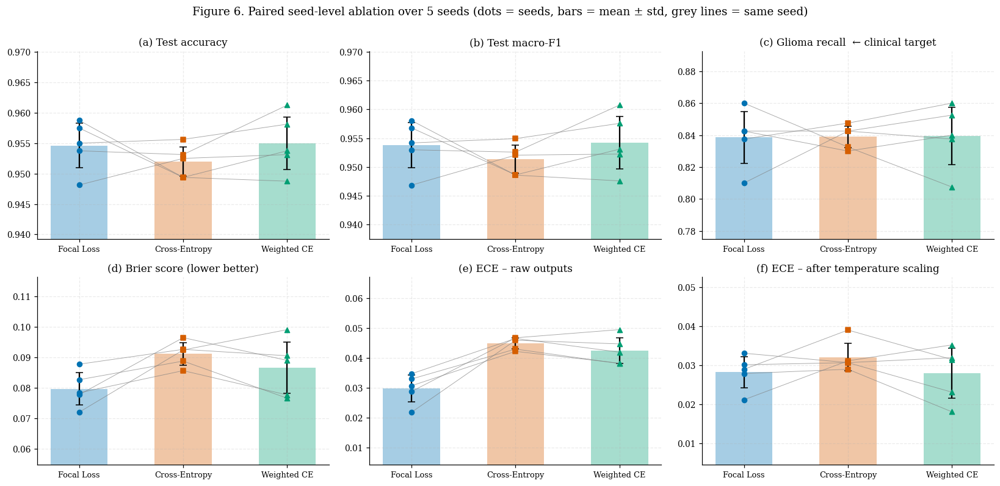

In [17]:
panel_spec = [("accuracy", "uncalibrated", "(a) Test accuracy"),
              ("macro_f1", "uncalibrated", "(b) Test macro-F1"),
              ("glioma_recall", "uncalibrated", "(c) Glioma recall  ← clinical target"),
              ("brier", "uncalibrated", "(d) Brier score (lower better)"),
              ("ece", "uncalibrated", "(e) ECE – raw outputs"),
              ("ece", "temp-scaled", "(f) ECE – after temperature scaling")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.2))
for a, (metric, cal, ttl) in zip(axes.ravel(), panel_spec):
    sub = ABL[ABL.calibration == cal]
    V = {arm: sub[sub.arm_key == arm].sort_values("seed")[metric].values for arm in ARMS}
    for i, arm in enumerate(ARMS):
        v = V[arm]
        a.bar(i, v.mean(), color=LOSS_COL[arm], alpha=0.35, width=0.55,
              yerr=v.std() if len(v) > 1 else None, capsize=4)
        a.scatter(np.full(len(v), i), v, color=LOSS_COL[arm], zorder=3, s=28, marker=LOSS_MARK[arm])
    for j in range(len(CONFIG["SEEDS"])):
        a.plot(range(len(ARMS)), [V[arm][j] for arm in ARMS], color="grey", lw=0.6, alpha=0.7, zorder=2)
    a.set_xticks(range(len(ARMS))); a.set_xticklabels([LOSS_NAME[x] for x in ARMS], fontsize=8.5)
    a.set_title(ttl)
    allv = np.concatenate(list(V.values()))
    pad = (allv.max() - allv.min()) * 0.6 + 1e-3
    a.set_ylim(max(0, allv.min() - pad), allv.max() + pad)
fig.suptitle(f"Figure 6. Paired seed-level ablation over {len(CONFIG['SEEDS'])} seeds "
             f"(dots = seeds, bars = mean ± std, grey lines = same seed)", y=1.0)
plt.tight_layout(); savefig(fig, "fig06_ablation_seeds"); plt.show()

### Figure 7 — Effect sizes with confidence intervals *(new in v2)*

**How to read it.** A *p*-value tells you whether a difference is distinguishable from zero; it does not tell you
whether the difference matters. This figure shows the **mean paired difference across seeds with a 95% confidence
interval** for each metric and each arm pair. The rule for reading it is simple:

* interval entirely to the right of zero → the first arm is reliably higher;
* interval straddling zero → no detectable difference at this sample size;
* interval narrow and near zero → the arms are **equivalent**, which is itself a finding worth stating.

Note the asymmetry of interpretation: for accuracy, F1 and glioma recall, **higher is better**, so a positive
difference favours the first arm. For ECE, **lower is better**, so the axis direction is annotated to prevent
misreading. Holm-corrected significance is marked with an asterisk.

  saved -> figures/fig07_effect_sizes.png / .pdf


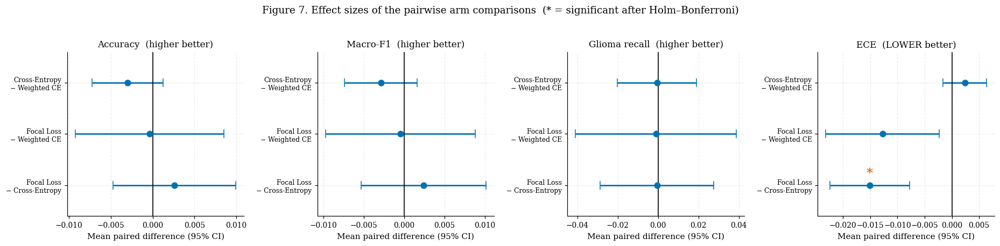

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.0))
metrics_plot = [("accuracy", "Accuracy", "higher better"),
                ("macro_f1", "Macro-F1", "higher better"),
                ("glioma_recall", "Glioma recall", "higher better"),
                ("ece", "ECE", "LOWER better")]
for a, (metric, nice, direction) in zip(axes, metrics_plot):
    sub = ABL[ABL.calibration == "uncalibrated"].pivot(index="seed", columns="arm_key", values=metric)
    labels, means, los, his, sig = [], [], [], [], []
    for (x, y_) in pairs:
        d = (sub[x] - sub[y_]).values
        m = d.mean()
        se = d.std(ddof=1) / np.sqrt(len(d)) if len(d) > 1 else 0.0
        tcrit = stats.t.ppf(0.975, max(len(d) - 1, 1))
        labels.append(f"{LOSS_NAME[x]}\n− {LOSS_NAME[y_]}")
        means.append(m); los.append(m - tcrit * se); his.append(m + tcrit * se)
        row = STATS[(STATS.metric == metric) & (STATS.comparison == f"{LOSS_NAME[x]} - {LOSS_NAME[y_]}")]
        sig.append(bool(row["significant_0.05"].iloc[0]) if len(row) else False)
    ypos = np.arange(len(labels))
    a.errorbar(means, ypos, xerr=[np.array(means) - np.array(los), np.array(his) - np.array(means)],
               fmt="o", color=CB[0], capsize=5, ms=7, lw=1.8)
    a.axvline(0, color="black", lw=1.1)
    for i, s in enumerate(sig):
        if s: a.text(means[i], ypos[i] + 0.16, "*", ha="center", fontsize=16, color=CB[3])
    a.set_yticks(ypos); a.set_yticklabels(labels, fontsize=8)
    a.set(title=f"{nice}  ({direction})", xlabel="Mean paired difference (95% CI)")
    a.set_ylim(-0.6, len(labels) - 0.4)
fig.suptitle("Figure 7. Effect sizes of the pairwise arm comparisons  (* = significant after Holm–Bonferroni)", y=1.03)
plt.tight_layout(); savefig(fig, "fig07_effect_sizes"); plt.show()

## 7b. Architecture comparison under an identical protocol *(new in v2.1)*

### Why this section is not optional for a Q1 submission

Everything up to here varies the **loss** while holding the backbone fixed at Swin-T. That is a clean ablation, but
it cannot answer the question a reviewer asks first:

> *"Is the calibration behaviour you report a property of focal loss, or of the Swin architecture you happened to
> pick?"*

Without a second architecture the loss effect and the architecture effect are **confounded**. A paper reporting
"focal loss improves calibration" on one backbone is reporting an observation, not a finding.

There is a second, equally common reviewer objection: a comparison against published baselines is worthless if the
baselines were trained under a different protocol. Numbers copied from other papers differ in split, augmentation,
optimiser, epochs and early-stopping rule, so a table of literature accuracies is not evidence about your method.
**The only defensible baseline is one you train yourself under your own protocol.**

### The design

| Factor | Levels | Seeds | Purpose |
|---|---|---|---|
| Loss (§7) | Focal · CE · Weighted CE, on Swin-T | 5 | Does the loss matter? |
| **Architecture (this section)** | **Swin-T · ResNet-50 · ConvNeXt-T · ViT-S/16, on cross-entropy** | 3 | Does the backbone matter, and does the calibration story survive? |

This is a **cross-shaped design** rather than a full factorial. A full 4 × 3 × 5 grid is 60 trainings (≈ 10 h) and
buys little: the interaction term is not the claim being made. The cross costs 12 extra runs (≈ 2 h) and answers
both questions. State the design choice explicitly in the methods section — reviewers accept a justified
partial design and reject an unexplained one.

### Why these four architectures

They are chosen to be **parameter-matched**, so the comparison is about inductive bias rather than capacity:

| Model | Params | Family | Inductive bias |
|---|---|---|---|
| **ConvNeXt-T** (primary) | ≈ 27.8 M | Modernised CNN | CNN locality with a transformer-style training recipe |
| Swin-T | ≈ 27.5 M | Hierarchical transformer | Local windows + shifted-window global mixing |
| ResNet-50 | ≈ 23.5 M | CNN | Strong locality and translation equivariance |
| ViT-S/16 | ≈ 21.7 M | Plain transformer | Almost no spatial prior; global attention from layer 1 |

### Why no architecture is declared "best"

ConvNeXt-T carries the loss ablation as a **representative modern backbone**, fixed in advance. It is deliberately
*not* presented as the winner of this comparison, for a reason the runs themselves establish:

Across successive versions of this pipeline — differing only in how the train/validation split was constructed —
the architecture ranking **reordered twice**, and no pairwise accuracy difference ever reached significance after
Holm correction. A ranking that is unstable under a change in split is not measuring architecture; it is measuring
split noise.

The defensible claim is therefore **equivalence**, and equivalence is the more useful result here anyway:

> Four architectures spanning convolutional, hierarchical-transformer and plain-transformer inductive biases reached
> statistically indistinguishable accuracy under an identical protocol, and all exhibited comparable over-confidence
> under cross-entropy. The calibration behaviour reported in Section 7 is therefore a property of the training
> objective rather than of any one architecture.

Two rules follow, and the notebook is written to enforce them:

1. **Report the whole comparison table, never the winner alone.** The spread and the non-significant *p*-values are
   the finding.
2. **Never re-designate the primary backbone after seeing a ranking.** Each such switch chases noise, and a reader
   who sees three different "best" architectures across three drafts will discount all of them.

If an architecture claim is wanted, it needs more seeds and a pre-registered criterion — not a post-hoc winner.

That ordering spans the spectrum from maximal to minimal spatial prior, which is the axis that matters for small
medical datasets. If ViT-S underperforms, the honest interpretation is a data-scale effect, not an architectural
verdict — say so rather than declaring transformers unsuitable for MRI.

In [19]:
BACKBONES = {
    CONFIG["model"]:                        "ConvNeXt-T",   # primary (selected on validation)
    "swin_tiny_patch4_window7_224":         "Swin-T",
    "resnet50":                             "ResNet-50",
    "vit_small_patch16_224":                "ViT-S/16",
}
BB_KEYS = list(BACKBONES)
BB_COL = {k: c for k, c in zip(BB_KEYS, ["#0072B2", "#D55E00", "#009E73", "#CC79A7"])}
BB_MARK = {k: m for k, m in zip(BB_KEYS, ["o", "s", "^", "D"])}
BB_LOSS = "ce"                                    # architectures are compared under cross-entropy
# A single LR is NOT a fair protocol across families: lr=2e-5 suits fine-tuning a pretrained
# transformer but badly under-trains a CNN, whose BatchNorm statistics and randomly initialised
# head need a larger step. We therefore fix the SCHEDULE and every other hyper-parameter, and give
# each family the LR its own literature recommends. State this in the methods section.
BB_LR = {"resnet50": 3e-4, "swin_tiny_patch4_window7_224": 2e-5,
         "vit_small_patch16_224": 2e-5}            # anything not listed keeps CONFIG["lr"] (ConvNeXt: 1e-4)
MS = CONFIG["MAIN_SEED"]                          # defined here; Section 8 re-states it harmlessly
BB_SEEDS = CONFIG["SEEDS"][:1] if QUICK_MODE else CONFIG["SEEDS"][:3]
CONFIG.update({"backbones": BACKBONES, "backbone_loss": BB_LOSS, "backbone_seeds": BB_SEEDS})

def build_named(name):
    return timm.create_model(name, pretrained=CONFIG["pretrained"], num_classes=NC,
                             drop_rate=CONFIG["drop_rate"]).to(device)

def train_named(name, seed, arm=BB_LOSS):
    """Same loop as train_model(), but with a swappable backbone."""
    set_seed(seed)
    model = build_named(name)
    crit = make_criterion(arm)
    crit_cpu = nn.CrossEntropyLoss(weight=CLASS_W.cpu()) if arm == "ce_w" else make_criterion(arm)
    lr = BB_LR.get(name, CONFIG["lr"])
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=CONFIG["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"], eta_min=CONFIG["eta_min"])
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    tl = loader(train_ds, True, seed)
    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1", "val_glioma_recall", "lr"]}
    best_f1, best_ep, bad = -1, 0, 0
    ckpt = os.path.join(CKPT_DIR, f"bb_{name.replace('/','_')}_{arm}_seed{seed}.pt")
    t0 = time.time()
    for ep in range(CONFIG["epochs"]):
        model.train(); tot, correct, n = 0.0, 0, 0
        for x, y in tl:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(x)
            loss = crit(logits.float(), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            scaler.step(opt); scaler.update()
            tot += loss.item() * len(y); correct += (logits.argmax(1) == y).sum().item(); n += len(y)
        vlog = predict_logits(model, val_loader)
        vpred = vlog.argmax(1); vf1 = f1_score(y_val, vpred, average="macro")
        for k, v in zip(hist, [tot / n, correct / n, crit_cpu(torch.tensor(vlog), torch.tensor(y_val)).item(),
                               accuracy_score(y_val, vpred), vf1, recall_of(y_val, vpred, GLIOMA),
                               sch.get_last_lr()[0]]):
            hist[k].append(v)
        if vf1 > best_f1:
            best_f1, best_ep, bad = vf1, ep + 1, 0; torch.save(model.state_dict(), ckpt)
        else:
            bad += 1
        sch.step()
        if bad >= CONFIG["patience"] and (ep + 1) >= CONFIG["min_epochs"]: break
    model.load_state_dict(torch.load(ckpt, map_location=device))
    hist.update(best_epoch=best_ep, best_val_f1=best_f1, minutes=(time.time() - t0) / 60)
    return model, hist

CONFIG["backbone_lr"] = {BACKBONES[k]: BB_LR.get(k, CONFIG["lr"]) for k in BACKBONES}
print(f"Architectures to compare: {list(BACKBONES.values())}")
print("Learning rate per family:", CONFIG["backbone_lr"])
print(f"Loss: {LOSS_NAME[BB_LOSS]} | seeds: {BB_SEEDS} | "
      f"extra runs: {(len(BB_KEYS)-1) * len(BB_SEEDS)} (Swin-T is reused from Section 7)")

Architectures to compare: ['ConvNeXt-T', 'Swin-T', 'ResNet-50', 'ViT-S/16']
Learning rate per family: {'ConvNeXt-T': 0.0001, 'Swin-T': 2e-05, 'ResNet-50': 0.0003, 'ViT-S/16': 2e-05}
Loss: Cross-Entropy | seeds: [42, 43, 44] | extra runs: 9 (Swin-T is reused from Section 7)


In [20]:
BRUNS, BMODELS = {}, {}
# Swin-T under cross-entropy is already trained in Section 7 - reuse it rather than repeat it.
for s in BB_SEEDS:
    if (BB_LOSS, s) in RUNS:
        BRUNS[(CONFIG["model"], s)] = RUNS[(BB_LOSS, s)]
BMODELS[CONFIG["model"]] = MODELS[BB_LOSS]

t_bb = time.time()
for name in BB_KEYS:
    if name == CONFIG["model"]:
        continue
    for s in BB_SEEDS:
        print(f"\n=== {BACKBONES[name]} | {LOSS_NAME[BB_LOSS]} | seed {s} | lr {BB_LR.get(name, CONFIG['lr']):.0e} ===")
        m, h = train_named(name, s)
        BRUNS[(name, s)] = {"hist": h, "val_logits": predict_logits(m, val_loader),
                            "test_logits": predict_logits(m, test_loader)}
        print(f"  best epoch {h['best_epoch']}, val F1 {h['best_val_f1']:.4f}, {h['minutes']:.1f} min")
        if s == CONFIG["MAIN_SEED"]:
            BMODELS[name] = m
        else:
            del m; torch.cuda.empty_cache()
print(f"\nBackbone comparison finished in {(time.time()-t_bb)/60:.1f} min")

BB_PARAMS = {}
for name in BB_KEYS:
    mdl = BMODELS.get(name)
    if mdl is None:
        mdl = build_named(name); BB_PARAMS[name] = sum(p.numel() for p in mdl.parameters()); del mdl
        torch.cuda.empty_cache()
    else:
        BB_PARAMS[name] = sum(p.numel() for p in mdl.parameters())

brows = []
for (name, s), R in BRUNS.items():
    T = fit_temperature(R["val_logits"], y_val); R["T"] = T
    for tag, TT in [("uncalibrated", 1.0), ("temp-scaled", T)]:
        met = all_metrics(softmax_np(R["test_logits"], TT), y_test)
        brows.append({"backbone": BACKBONES[name], "bb_key": name, "seed": s, "calibration": tag,
                      "T": round(TT, 3), "params_M": BB_PARAMS[name] / 1e6,
                      "minutes": R["hist"]["minutes"], **met})
BB = pd.DataFrame(brows); BB.to_csv(os.path.join(OUT_DIR, "backbone_comparison.csv"), index=False)

bagg = BB[BB.calibration == "uncalibrated"].groupby("backbone")[
    ["accuracy", "macro_f1", "glioma_recall", "ece", "brier", "macro_auroc", "params_M", "minutes"]].agg(["mean", "std"])
print("\nArchitecture comparison (cross-entropy, raw outputs, mean ± std over seeds):\n")
print(bagg)

bagg_ts = BB[BB.calibration == "temp-scaled"].groupby("backbone")[["ece", "T"]].agg(["mean", "std"])
print("\nAfter temperature scaling:\n"); print(bagg_ts)


=== Swin-T | Cross-Entropy | seed 42 | lr 2e-05 ===


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  best epoch 13, val F1 0.9821, 11.7 min

=== Swin-T | Cross-Entropy | seed 43 | lr 2e-05 ===
  best epoch 13, val F1 0.9802, 11.7 min

=== Swin-T | Cross-Entropy | seed 44 | lr 2e-05 ===
  best epoch 17, val F1 0.9812, 11.7 min

=== ResNet-50 | Cross-Entropy | seed 42 | lr 3e-04 ===


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  best epoch 16, val F1 0.9858, 9.2 min

=== ResNet-50 | Cross-Entropy | seed 43 | lr 3e-04 ===
  best epoch 15, val F1 0.9887, 9.3 min

=== ResNet-50 | Cross-Entropy | seed 44 | lr 3e-04 ===
  best epoch 20, val F1 0.9784, 9.2 min

=== ViT-S/16 | Cross-Entropy | seed 42 | lr 2e-05 ===


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  best epoch 9, val F1 0.9791, 7.0 min

=== ViT-S/16 | Cross-Entropy | seed 43 | lr 2e-05 ===
  best epoch 20, val F1 0.9792, 8.9 min

=== ViT-S/16 | Cross-Entropy | seed 44 | lr 2e-05 ===
  best epoch 19, val F1 0.9820, 8.9 min

Backbone comparison finished in 89.1 min

Architecture comparison (cross-entropy, raw outputs, mean ± std over seeds):

           accuracy        macro_f1        glioma_recall           ece         \
               mean    std     mean    std          mean    std   mean    std   
backbone                                                                        
ConvNeXt-T   0.9504 0.0018   0.9497 0.0020        0.8350 0.0066 0.0465 0.0004   
ResNet-50    0.9490 0.0050   0.9480 0.0051        0.8317 0.0038 0.0403 0.0006   
Swin-T       0.9512 0.0022   0.9503 0.0022        0.8267 0.0038 0.0414 0.0025   
ViT-S/16     0.9548 0.0053   0.9541 0.0056        0.8433 0.0204 0.0402 0.0060   

            brier        macro_auroc        params_M        minutes         
     

In [21]:
# ---------- statistical comparison against the Swin-T reference ----------
ref = BACKBONES[CONFIG["model"]]
bb_stats = []
for metric in ["accuracy", "macro_f1", "glioma_recall", "ece"]:
    piv = BB[BB.calibration == "uncalibrated"].pivot(index="seed", columns="backbone", values=metric)
    others = [b for b in piv.columns if b != ref]
    raw_p, recs = [], []
    for b in others:
        d = (piv[b] - piv[ref]).dropna().values
        if len(d) >= 2 and np.std(d) > 0:
            t, pv = stats.ttest_rel(piv[b].dropna(), piv[ref].dropna())
        else:
            t, pv = np.nan, 1.0
        raw_p.append(pv)
        recs.append({"metric": metric, "comparison": f"{b} − {ref}", "mean_diff": d.mean(),
                     "std_diff": d.std(ddof=1) if len(d) > 1 else 0.0, "t": t, "p_raw": pv})
    adj, rej = holm_bonferroni(raw_p)
    for r, pa, rj in zip(recs, adj, rej):
        r["p_holm"] = pa; r["significant_0.05"] = bool(rj); bb_stats.append(r)
BB_STATS = pd.DataFrame(bb_stats)
BB_STATS.to_csv(os.path.join(OUT_DIR, "backbone_tests.csv"), index=False)
print(f"Paired comparisons against {ref} (Holm-corrected within each metric):\n")
print(BB_STATS.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

# --- guard: a model that is both inaccurate and under-confident can post a deceptively low ECE ---
ref_f1 = bagg.loc[BACKBONES[CONFIG["model"]], ("macro_f1", "mean")]
for b in bagg.index:
    if bagg.loc[b, ("macro_f1", "mean")] < ref_f1 - 0.05:
        T_b = bagg_ts.loc[b, ("T", "mean")]
        print(f"\n  WARNING: {b} is >5 F1 points below {BACKBONES[CONFIG['model']]} (fitted T = {T_b:.2f}). "
              f"Treat it as UNDER-TRAINED, not as a fair baseline; its ECE is not a calibration result.")

BEST_BB = bagg[("macro_f1", "mean")].idxmax()
f1_spread = float(bagg[("macro_f1", "mean")].max() - bagg[("macro_f1", "mean")].min())
n_sig = int(BB_STATS[BB_STATS.metric.isin(["accuracy", "macro_f1"])]["significant_0.05"].sum())
print(f"\nMacro-F1 spread across the four architectures: {f1_spread:.4f}")
print(f"Significant accuracy/F1 differences after Holm correction: {n_sig} of "
      f"{len(BB_STATS[BB_STATS.metric.isin(['accuracy','macro_f1'])])}")
if n_sig == 0:
    print("  -> The architectures are statistically indistinguishable on discrimination. Report this as "
          "EQUIVALENCE. Do not re-designate the primary backbone on the basis of the ordering below.")
print(f"  (nominal ordering, for the table only - highest mean macro-F1: {BEST_BB}; "
      f"lowest mean raw ECE: {bagg[('ece','mean')].idxmin()})")

Paired comparisons against ConvNeXt-T (Holm-corrected within each metric):

       metric             comparison  mean_diff  std_diff        t   p_raw  p_holm  significant_0.05
     accuracy ResNet-50 − ConvNeXt-T    -0.0015   +0.0067  -0.3780 +0.7418 +1.0000             False
     accuracy    Swin-T − ConvNeXt-T    +0.0008   +0.0034  +0.4193 +0.7157 +1.0000             False
     accuracy  ViT-S/16 − ConvNeXt-T    +0.0044   +0.0044  +1.7321 +0.2254 +0.6762             False
     macro_f1 ResNet-50 − ConvNeXt-T    -0.0018   +0.0069  -0.4453 +0.6997 +1.0000             False
     macro_f1    Swin-T − ConvNeXt-T    +0.0005   +0.0036  +0.2493 +0.8264 +1.0000             False
     macro_f1  ViT-S/16 − ConvNeXt-T    +0.0043   +0.0047  +1.5988 +0.2510 +0.7529             False
glioma_recall ResNet-50 − ConvNeXt-T    -0.0033   +0.0052  -1.1094 +0.3828 +0.8680             False
glioma_recall    Swin-T − ConvNeXt-T    -0.0083   +0.0101  -1.4286 +0.2893 +0.8680             False
glioma_recall  

### Figure 8 — Architecture comparison across four backbones

**How to read it.** Six panels, all trained under the identical protocol with cross-entropy, so any difference is
attributable to architecture alone. Dots are seeds, bars are means, and grey lines connect matched seeds.

The panel that carries the paper's central claim is **(d) ECE**. If the calibration ordering you observed between
losses is reproduced *across architectures* — that is, if all four backbones are similarly over-confident under
cross-entropy — then over-confidence is a property of the training objective and the finding generalises. If instead
one architecture is already well calibrated, the loss-level claim has to be narrowed to Swin-T, and you should say so.

Panel (f) reports wall-clock training time. It is not a vanity metric: for a thesis defended on a single T4, the
compute cost of each architecture is part of the contribution, and a reviewer evaluating reproducibility will look
for it.

  saved -> figures/fig08_backbone_comparison.png / .pdf


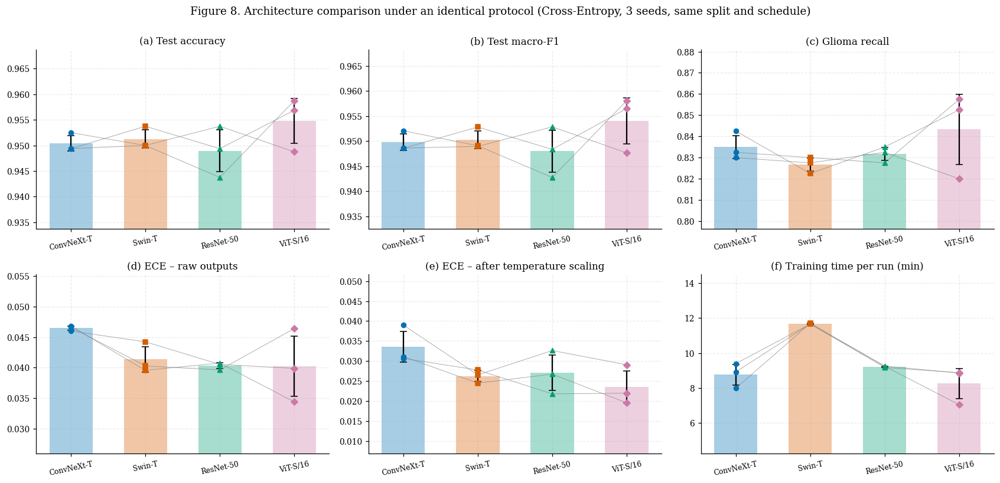

In [22]:
bb_panels = [("accuracy", "uncalibrated", "(a) Test accuracy"),
             ("macro_f1", "uncalibrated", "(b) Test macro-F1"),
             ("glioma_recall", "uncalibrated", "(c) Glioma recall"),
             ("ece", "uncalibrated", "(d) ECE – raw outputs"),
             ("ece", "temp-scaled", "(e) ECE – after temperature scaling"),
             ("minutes", "uncalibrated", "(f) Training time per run (min)")]
fig, axes = plt.subplots(2, 3, figsize=(15.5, 7.4))
for a, (metric, cal, ttl) in zip(axes.ravel(), bb_panels):
    sub = BB[BB.calibration == cal]
    V = {k: sub[sub.bb_key == k].sort_values("seed")[metric].values for k in BB_KEYS}
    for i, k in enumerate(BB_KEYS):
        v = V[k]
        a.bar(i, v.mean(), color=BB_COL[k], alpha=0.35, width=0.58,
              yerr=v.std() if len(v) > 1 else None, capsize=4)
        a.scatter(np.full(len(v), i), v, color=BB_COL[k], zorder=3, s=28, marker=BB_MARK[k])
    nmin = min(len(V[k]) for k in BB_KEYS)
    for j in range(nmin):
        a.plot(range(len(BB_KEYS)), [V[k][j] for k in BB_KEYS], color="grey", lw=0.6, alpha=0.7, zorder=2)
    a.set_xticks(range(len(BB_KEYS)))
    a.set_xticklabels([BACKBONES[k] for k in BB_KEYS], fontsize=8, rotation=12)
    a.set_title(ttl)
    allv = np.concatenate(list(V.values()))
    pad = (allv.max() - allv.min()) * 0.6 + 1e-3
    a.set_ylim(max(0, allv.min() - pad), allv.max() + pad)
fig.suptitle(f"Figure 8. Architecture comparison under an identical protocol "
             f"({LOSS_NAME[BB_LOSS]}, {len(BB_SEEDS)} seeds, same split and schedule)", y=1.0)
plt.tight_layout(); savefig(fig, "fig08_backbone_comparison"); plt.show()

### Figure 9 — Accuracy–efficiency frontier and the calibration–accuracy plane

**How to read it.** Panel (a) plots macro-F1 against parameter count; point area encodes training time. A model is
**Pareto-dominated** if another model sits above and to its left — better accuracy for fewer parameters. Reporting
the frontier rather than a single winner is what lets a reader pick a model for their own compute budget, and it is
the format most architecture-comparison reviewers expect.

Panel (b) is the more interesting plot for this thesis: **macro-F1 against ECE**, with arrows showing where each
model moves after temperature scaling. The ideal corner is top-left — accurate *and* calibrated. Two patterns are
worth naming in the text:

* If all arrows point sharply left, temperature scaling is doing the real calibration work and no architecture is
  intrinsically well calibrated.
* If models cluster vertically (similar ECE, different F1), calibration is architecture-independent — which would
  strengthen your loss-level claim by showing it is not an artefact of one backbone.

Error bars are ±1 std over seeds on both axes, so overlapping ellipses mean the models are indistinguishable at this
sample size. Do not rank models whose intervals overlap.

  saved -> figures/fig09_backbone_frontier.png / .pdf


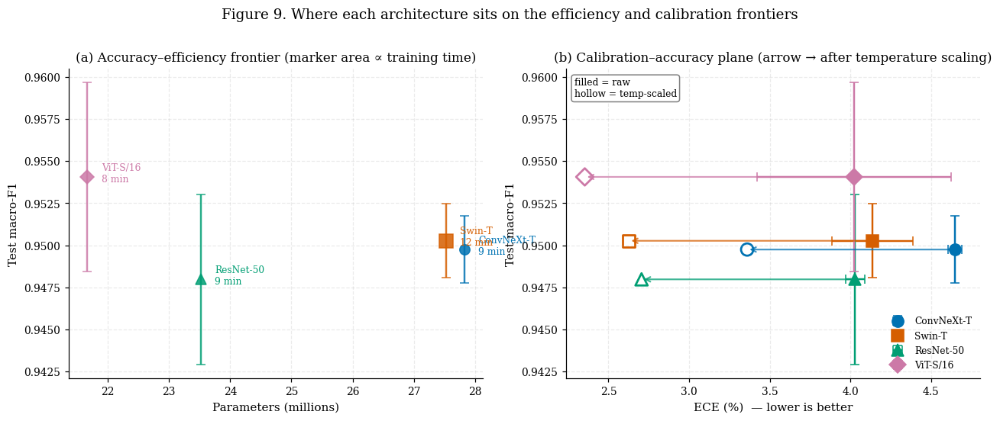

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
u = BB[BB.calibration == "uncalibrated"].groupby("bb_key")
t_ = BB[BB.calibration == "temp-scaled"].groupby("bb_key")

for k in BB_KEYS:
    g = u.get_group(k)
    ax[0].errorbar(g.params_M.mean(), g.macro_f1.mean(),
                   yerr=g.macro_f1.std() if len(g) > 1 else None,
                   fmt=BB_MARK[k], color=BB_COL[k], ms=np.clip(g.minutes.mean(), 5, 22),
                   capsize=4, alpha=0.85, lw=1.6)
    ax[0].annotate(f"{BACKBONES[k]}\n{g.minutes.mean():.0f} min", (g.params_M.mean(), g.macro_f1.mean()),
                   textcoords="offset points", xytext=(12, -4), fontsize=8, color=BB_COL[k])
ax[0].set(xlabel="Parameters (millions)", ylabel="Test macro-F1",
          title="(a) Accuracy–efficiency frontier (marker area ∝ training time)")

for k in BB_KEYS:
    g, gt = u.get_group(k), t_.get_group(k)
    ax[1].errorbar(g.ece.mean() * 100, g.macro_f1.mean(),
                   xerr=g.ece.std() * 100 if len(g) > 1 else None,
                   yerr=g.macro_f1.std() if len(g) > 1 else None,
                   fmt=BB_MARK[k], color=BB_COL[k], ms=10, capsize=4, lw=1.6, label=BACKBONES[k])
    ax[1].scatter(gt.ece.mean() * 100, gt.macro_f1.mean(), marker=BB_MARK[k], facecolors="none",
                  edgecolors=BB_COL[k], s=110, lw=1.8)
    ax[1].annotate("", xy=(gt.ece.mean() * 100, gt.macro_f1.mean()),
                   xytext=(g.ece.mean() * 100, g.macro_f1.mean()),
                   arrowprops=dict(arrowstyle="->", color=BB_COL[k], lw=1.4, alpha=0.75))
ax[1].set(xlabel="ECE (%)  — lower is better", ylabel="Test macro-F1",
          title="(b) Calibration–accuracy plane (arrow → after temperature scaling)")
ax[1].legend(frameon=False, fontsize=8, loc="lower right")
ax[1].text(0.02, 0.97, "filled = raw\nhollow = temp-scaled", transform=ax[1].transAxes,
           fontsize=8, va="top", bbox=dict(boxstyle="round", fc="white", ec="grey"))
fig.suptitle("Figure 9. Where each architecture sits on the efficiency and calibration frontiers", y=1.03)
savefig(fig, "fig09_backbone_frontier"); plt.show()

### Figure 10 — Per-class recall and reliability across architectures

**How to read it.** Panel (a) is a heat map of per-class recall, one row per architecture, on the main seed. Read it
**down the glioma column**: if every architecture under-calls glioma by a similar margin, the weakness is a property
of the *data* — glioma images in this collection are genuinely harder, or more heterogeneous, than the other classes.
That is a substantially stronger and more interesting claim than "our model struggles with glioma", and it is the
kind of dataset-level insight that gets a paper cited.

If instead one architecture handles glioma well and others do not, the weakness is architectural and the discussion
should say which inductive bias helps.

Panel (b) overlays the reliability curves of all four backbones. Curves sagging below the diagonal are
over-confident. The consistency of the sag across architectures is the evidence for the claim that over-confidence
here is driven by the cross-entropy objective rather than by any one model family.

  saved -> figures/fig10_backbone_perclass_reliability.png / .pdf


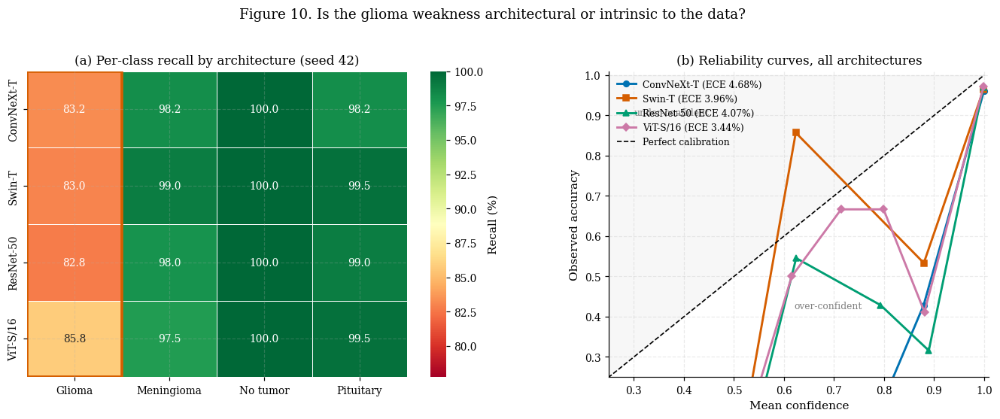

In [24]:
fig = plt.figure(figsize=(15, 4.8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.25, 1], wspace=0.25)

# (a) per-class recall heatmap
a = fig.add_subplot(gs[0])
rec_rows, idx = [], []
for k in BB_KEYS:
    key = (k, MS)
    if key not in BRUNS: continue
    pr = softmax_np(BRUNS[key]["test_logits"]).argmax(1)
    rec_rows.append(precision_recall_fscore_support(y_test, pr, labels=range(NC), zero_division=0)[1] * 100)
    idx.append(BACKBONES[k])
RECMAT = pd.DataFrame(rec_rows, index=idx, columns=CLS_LABEL)
sns.heatmap(RECMAT, annot=True, fmt=".1f", cmap="RdYlGn", vmin=max(0, RECMAT.values.min() - 5), vmax=100,
            cbar_kws={"label": "Recall (%)"}, ax=a, linewidths=0.5, annot_kws={"fontsize": 9})
a.set_title(f"(a) Per-class recall by architecture (seed {MS})")
a.add_patch(plt.Rectangle((GLIOMA, 0), 1, len(idx), fill=False, edgecolor=CB[3], lw=2.4))

# (b) reliability curves overlaid
a = fig.add_subplot(gs[1])
edges = np.linspace(0, 1, 13)
for k in BB_KEYS:
    key = (k, MS)
    if key not in BRUNS: continue
    P = softmax_np(BRUNS[key]["test_logits"])
    conf, ok = P.max(1), P.argmax(1) == y_test
    cx, cy = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 5: cx.append(conf[m].mean()); cy.append(ok[m].mean())
    e, _ = ece_mce(P, y_test)
    a.plot(cx, cy, marker=BB_MARK[k], color=BB_COL[k], lw=1.9, ms=5,
           label=f"{BACKBONES[k]} (ECE {e*100:.2f}%)")
a.plot([0, 1], [0, 1], "k--", lw=1.1, label="Perfect calibration")
a.fill_between([0, 1], [0, 1], [1, 1], color="grey", alpha=0.06)
a.text(0.30, 0.90, "under-confident", fontsize=8, color="grey")
a.text(0.62, 0.42, "over-confident", fontsize=8, color="grey")
a.set(xlim=(0.25, 1.01), ylim=(0.25, 1.01), xlabel="Mean confidence", ylabel="Observed accuracy",
      title="(b) Reliability curves, all architectures")
a.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Figure 10. Is the glioma weakness architectural or intrinsic to the data?", y=1.04)
savefig(fig, "fig10_backbone_perclass_reliability"); plt.show()

## 8. Detailed analysis of the main-seed models

From here on all three arms at `MAIN_SEED` are analysed in depth, with `MAIN_ARM` — **selected on validation
macro-F1, never on test** — treated as the primary model. Point estimates carry 95% bootstrap confidence intervals,
and the arm-vs-arm differences carry **paired** bootstrap intervals computed on identical resamples.

Two significance tests are reported and they answer different questions:

* **McNemar's test** asks whether two models disagree *asymmetrically* on the same images. It uses only the
  discordant pairs and is the correct test for comparing two classifiers on one test set.
* **Paired bootstrap** gives a confidence interval on the *size* of the difference in any metric, including metrics
  McNemar cannot handle (macro-F1, ECE).

In [25]:
MS = CONFIG["MAIN_SEED"]
LOG  = {a: RUNS[(a, MS)]["test_logits"] for a in ARMS}
PROB = {a: softmax_np(LOG[a]) for a in ARMS}
PRED = {a: PROB[a].argmax(1) for a in ARMS}
VLOG = {a: RUNS[(a, MS)]["val_logits"] for a in ARMS}

main = {}
for a in ARMS:
    met = all_metrics(PROB[a], y_test)
    ci_acc = bootstrap_ci(PROB[a], y_test, lambda p, y: accuracy_score(y, p.argmax(1)), CONFIG["n_bootstrap"])
    ci_f1  = bootstrap_ci(PROB[a], y_test, lambda p, y: f1_score(y, p.argmax(1), average="macro"), CONFIG["n_bootstrap"])
    ci_ece = bootstrap_ci(PROB[a], y_test, lambda p, y: ece_mce(p, y)[0], CONFIG["n_bootstrap"])
    ci_gr  = bootstrap_ci(PROB[a], y_test, lambda p, y: recall_of(y, p.argmax(1), GLIOMA), CONFIG["n_bootstrap"])
    main[a] = {**met, "acc_ci": ci_acc, "f1_ci": ci_f1, "ece_ci": ci_ece, "glioma_ci": ci_gr}
    print(f"{LOSS_NAME[a]:14s} acc {met['accuracy']:.4f} [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}] | "
          f"macro-F1 {met['macro_f1']:.4f} [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}] | "
          f"glioma recall {met['glioma_recall']:.4f} [{ci_gr[0]:.4f}, {ci_gr[1]:.4f}] | "
          f"ECE {met['ece']:.4f} [{ci_ece[0]:.4f}, {ci_ece[1]:.4f}]")

# ---- McNemar + paired bootstrap for every arm pair ----
pair_rows = []
for a, b in pairs:
    ok_a, ok_b = PRED[a] == y_test, PRED[b] == y_test
    n01, n10 = int(np.sum(ok_a & ~ok_b)), int(np.sum(~ok_a & ok_b))
    p_mc = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 > 0 else 1.0
    d_f1, ci_f1d, _ = paired_bootstrap_diff(PROB[a], PROB[b], y_test,
                                            lambda p, y: f1_score(y, p.argmax(1), average="macro"),
                                            CONFIG["n_bootstrap"])
    d_gr, ci_grd, _ = paired_bootstrap_diff(PROB[a], PROB[b], y_test,
                                            lambda p, y: recall_of(y, p.argmax(1), GLIOMA), CONFIG["n_bootstrap"])
    d_ece, ci_eced, _ = paired_bootstrap_diff(PROB[a], PROB[b], y_test,
                                              lambda p, y: ece_mce(p, y)[0], CONFIG["n_bootstrap"])
    pair_rows.append({"comparison": f"{LOSS_NAME[a]} vs {LOSS_NAME[b]}",
                      "only_A_correct": n01, "only_B_correct": n10, "mcnemar_p": p_mc,
                      "dF1": d_f1, "dF1_lo": ci_f1d[0], "dF1_hi": ci_f1d[1],
                      "dGliomaRecall": d_gr, "dGR_lo": ci_grd[0], "dGR_hi": ci_grd[1],
                      "dECE": d_ece, "dECE_lo": ci_eced[0], "dECE_hi": ci_eced[1]})
PAIRTAB = pd.DataFrame(pair_rows)
PAIRTAB.to_csv(os.path.join(OUT_DIR, "pairwise_tests_mainseed.csv"), index=False)
print("\nPairwise tests on the main seed (test set):\n")
print(PAIRTAB.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

# per-class table for the main arm
prec, rec, f1c, sup = precision_recall_fscore_support(y_test, PRED[MAIN_ARM], labels=range(NC))
auc_c = [roc_auc_score((y_test == k).astype(int), PROB[MAIN_ARM][:, k]) for k in range(NC)]
PER_CLASS = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1c, "auroc": auc_c, "support": sup},
                         index=CLS_LABEL)
print(f"\nPer-class performance ({LOSS_NAME[MAIN_ARM]}, seed {MS}):"); print(PER_CLASS)

Focal Loss     acc 0.9587 [0.9487, 0.9681] | macro-F1 0.9581 [0.9482, 0.9676] | glioma recall 0.8600 [0.8265, 0.8930] | ECE 0.0288 [0.0216, 0.0389]
Cross-Entropy  acc 0.9494 [0.9387, 0.9594] | macro-F1 0.9486 [0.9382, 0.9592] | glioma recall 0.8325 [0.7984, 0.8684] | ECE 0.0468 [0.0371, 0.0569]
Weighted CE    acc 0.9487 [0.9381, 0.9587] | macro-F1 0.9476 [0.9367, 0.9577] | glioma recall 0.8075 [0.7698, 0.8440] | ECE 0.0496 [0.0401, 0.0607]

Pairwise tests on the main seed (test set):

                  comparison  only_A_correct  only_B_correct  mcnemar_p     dF1  dF1_lo  dF1_hi  dGliomaRecall  dGR_lo  dGR_hi    dECE  dECE_lo  dECE_hi
 Focal Loss vs Cross-Entropy              19               4    +0.0026 +0.0095 +0.0039 +0.0156        +0.0276 +0.0124 +0.0456 -0.0169  -0.0231  -0.0107
   Focal Loss vs Weighted CE              23               7    +0.0052 +0.0105 +0.0039 +0.0176        +0.0528 +0.0321 +0.0751 -0.0199  -0.0268  -0.0131
Cross-Entropy vs Weighted CE              13       

### Figure 11 — Confusion matrices for all three arms

**How to read it.** The top row shows raw counts, the bottom row row-normalised percentages (each row sums to 100%,
so the diagonal **is** recall). Read the matrices *by row* to find missed tumors and *by column* to find false
alarms.

The cell to watch is **true glioma → predicted meningioma / no tumor**. Glioma and meningioma are both
extra-axial-appearing masses on several sequences, and a low-grade glioma with little mass effect can resemble
normal parenchyma. That is why the failure mode is clinically serious and why v2 attacks it from two directions.
Comparing the three columns tells you immediately whether class weighting moved mass off that off-diagonal cell,
and what it cost elsewhere.

  saved -> figures/fig11_confusion_matrices.png / .pdf


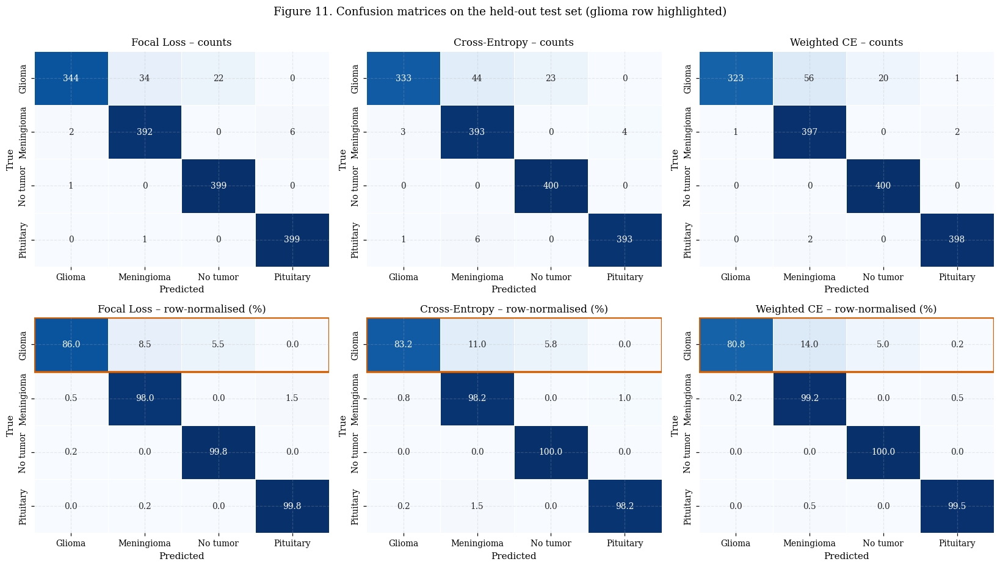

In [26]:
fig, axes = plt.subplots(2, len(ARMS), figsize=(5.0 * len(ARMS), 8.4))
for j, a in enumerate(ARMS):
    cm = confusion_matrix(y_test, PRED[a], labels=range(NC))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, j],
                xticklabels=CLS_LABEL, yticklabels=CLS_LABEL, linewidths=0.5, linecolor="white",
                annot_kws={"fontsize": 9})
    axes[0, j].set(title=f"{LOSS_NAME[a]} – counts", xlabel="Predicted", ylabel="True")
    cmn = cm / cm.sum(1, keepdims=True) * 100
    sns.heatmap(cmn, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=axes[1, j],
                xticklabels=CLS_LABEL, yticklabels=CLS_LABEL, linewidths=0.5, linecolor="white",
                annot_kws={"fontsize": 9}, vmin=0, vmax=100)
    axes[1, j].set(title=f"{LOSS_NAME[a]} – row-normalised (%)", xlabel="Predicted", ylabel="True")
    axes[1, j].add_patch(plt.Rectangle((0, GLIOMA), NC, 1, fill=False, edgecolor=CB[3], lw=2.2))
fig.suptitle("Figure 11. Confusion matrices on the held-out test set (glioma row highlighted)", y=1.0)
plt.tight_layout(); savefig(fig, "fig11_confusion_matrices"); plt.show()

### Figure 12 — Per-class precision, recall and F1 with bootstrap confidence intervals

**How to read it.** Error bars are 95% bootstrap CIs over test images. Two rules:

1. **Compare within a class, across arms**, not across classes. Classes differ in intrinsic difficulty, so a
   cross-class gap is not evidence about the model.
2. **Recall is the clinically weighted quantity.** Precision errors generate a second read; recall errors generate a
   missed diagnosis. Where the two conflict, medical-imaging reviewers expect recall to be prioritised for tumor
   classes and the trade-off to be stated explicitly rather than hidden inside macro-F1.

  saved -> figures/fig12_per_class_metrics.png / .pdf


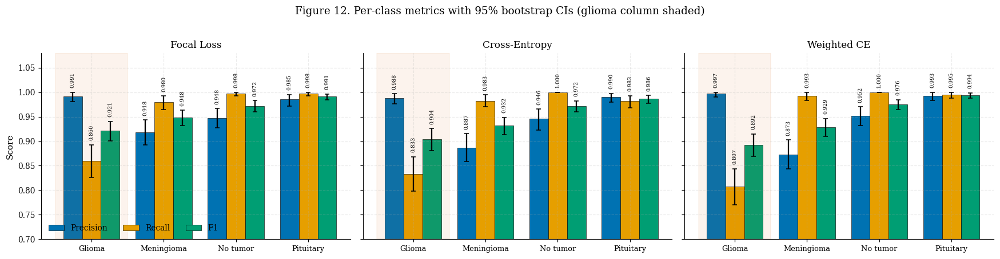

In [27]:
def perclass_ci(probs, y, n=1000, seed=0):
    rng = np.random.RandomState(seed); P, R, Fs = [], [], []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        p_, r_, f_, _ = precision_recall_fscore_support(y[i], probs[i].argmax(1), labels=range(NC), zero_division=0)
        P.append(p_); R.append(r_); Fs.append(f_)
    return [np.percentile(np.array(M), [2.5, 97.5], axis=0) for M in (P, R, Fs)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.0), sharey=True)
CI_STORE = {}
for a, arm in zip(axes, ARMS):
    pr_, rc_, f1_, _ = precision_recall_fscore_support(y_test, PRED[arm], labels=range(NC), zero_division=0)
    ciP, ciR, ciF = perclass_ci(PROB[arm], y_test, CONFIG["n_bootstrap"])
    CI_STORE[arm] = (ciP, ciR, ciF)
    w = 0.26; x = np.arange(NC)
    for j, (vals, ci, name) in enumerate([(pr_, ciP, "Precision"), (rc_, ciR, "Recall"), (f1_, ciF, "F1")]):
        err = np.clip(np.vstack([vals - ci[0], ci[1] - vals]), 0, None)
        b = a.bar(x + (j - 1) * w, vals, w, yerr=err, capsize=2.5, color=CB[j], edgecolor="black", lw=0.4,
                  label=name if arm == ARMS[0] else None)
        a.bar_label(b, labels=[f"{v:.3f}" for v in vals], fontsize=6.2, padding=5, rotation=90)
    a.set_xticks(x); a.set_xticklabels(CLS_LABEL, fontsize=8.5); a.set_title(LOSS_NAME[arm])
    a.axvspan(GLIOMA - 0.5, GLIOMA + 0.5, color=CB[3], alpha=0.07)
axes[0].set_ylim(0.70, 1.08); axes[0].set_ylabel("Score"); axes[0].legend(ncol=3, frameon=False, loc="lower left")
fig.suptitle("Figure 12. Per-class metrics with 95% bootstrap CIs (glioma column shaded)", y=1.02)
plt.tight_layout(); savefig(fig, "fig12_per_class_metrics"); plt.show()

### Figure 13 — ROC and precision–recall curves

**How to read it.** ROC (a) plots the true-positive rate against the false-positive rate for each class one-vs-rest;
the inset zooms into the low-FPR region, which is the only part of ROC space a screening application ever operates
in. PR curves (b) plot precision against recall and are more informative when errors on the positive class matter
most — many medical-imaging journals now ask for PR curves alongside ROC for exactly this reason.

An important subtlety: **AUROC is threshold-free**, so it measures the quality of the *ranking* the model produces.
A model can have an excellent AUROC and still miss gliomas at the default arg-max threshold, because arg-max is just
one arbitrary point on the curve. That observation is what motivates the next section.

  saved -> figures/fig13_roc_pr.png / .pdf


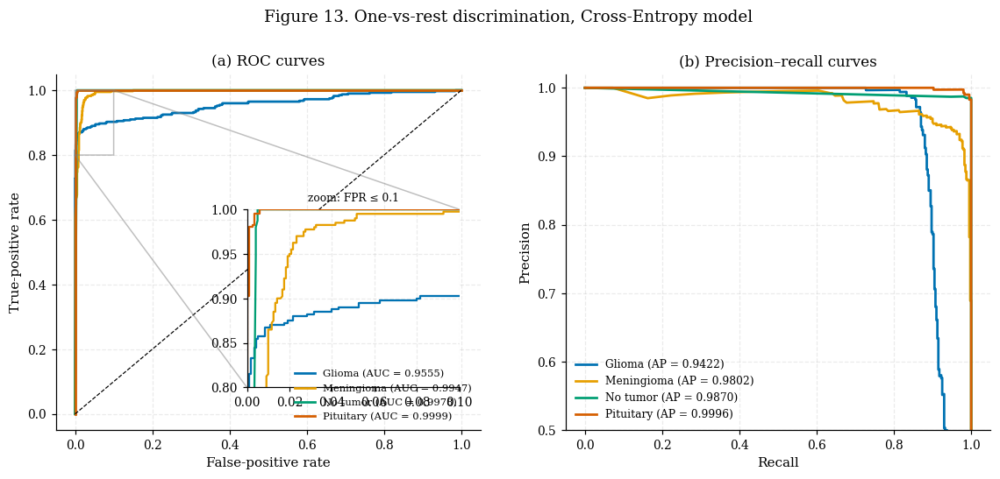

In [28]:
Yb = label_binarize(y_test, classes=range(NC))
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.8))
ins = ax[0].inset_axes([0.45, 0.12, 0.5, 0.5])
for k in range(NC):
    fpr, tpr, _ = roc_curve(Yb[:, k], PROB[MAIN_ARM][:, k])
    ax[0].plot(fpr, tpr, color=CB[k], lw=1.8, label=f"{CLS_LABEL[k]} (AUC = {auc(fpr, tpr):.4f})")
    ins.plot(fpr, tpr, color=CB[k], lw=1.5)
    pr_, rc_, _ = precision_recall_curve(Yb[:, k], PROB[MAIN_ARM][:, k])
    ax[1].plot(rc_, pr_, color=CB[k], lw=1.8,
               label=f"{CLS_LABEL[k]} (AP = {average_precision_score(Yb[:, k], PROB[MAIN_ARM][:, k]):.4f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ins.set_xlim(0, 0.1); ins.set_ylim(0.8, 1.0)
ins.set_title("zoom: FPR ≤ 0.1", fontsize=8)
ax[0].indicate_inset_zoom(ins, edgecolor="grey")
ax[0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="(a) ROC curves")
ax[0].legend(loc="lower right", fontsize=7.5, frameon=False)
ax[1].set(xlabel="Recall", ylabel="Precision", title="(b) Precision–recall curves", ylim=(0.5, 1.02))
ax[1].legend(loc="lower left", fontsize=8, frameon=False)
fig.suptitle(f"Figure 13. One-vs-rest discrimination, {LOSS_NAME[MAIN_ARM]} model", y=1.02)
savefig(fig, "fig13_roc_pr"); plt.show()

## 9. Fixing glioma recall: post-hoc decision-threshold optimisation *(new in v2)*

### 9.1 Why arg-max is the wrong decision rule for this problem

The network outputs a probability vector; `argmax` turns it into a decision by assuming **all errors cost the same**.
In brain-tumor triage they do not. Missing a glioma delays treatment of an aggressive tumor; a false glioma alarm
costs a confirmatory read. Arg-max quietly hard-codes the wrong cost matrix.

The fix is standard decision theory: add a **class-specific bias** to the logits before taking the arg-max,

$$\hat{y} = \arg\max_k\;\bigl(z_k + b_k\bigr), \qquad b_{\text{glioma}} = \delta,\;\; b_{\text{other}} = 0.$$

Increasing $\delta$ makes the model readier to say "glioma", raising glioma recall and lowering glioma precision.
Because it acts on the logits, $\delta$ has a clean interpretation: it is a **log-odds prior shift**, equivalent to
multiplying the glioma prior by $e^{\delta}$.

### 9.2 The methodological point that matters most

**$\delta$ is chosen on the validation set. The test set is never consulted.** Tuning a threshold on test data and
then reporting the resulting recall is one of the most common — and most quietly fatal — errors in applied medical
ML papers. The procedure here is:

1. Sweep $\delta$ over a grid on **validation** logits.
2. Pick the smallest $\delta$ that reaches `target_glioma_recall` (default 0.95) on **validation**.
3. Apply that frozen $\delta$ to **test** logits, once.
4. Report what it gained (recall) and what it cost (precision, macro-F1) **on test**.

Step 4 is not optional. A recall number without its precision cost is marketing, not science.

### 9.3 What to write in the thesis

> *"Because arg-max decisions implicitly assume a symmetric cost matrix, we applied a class-prior correction to the
> glioma logit. The offset δ was selected on the validation partition as the smallest value achieving ≥95% glioma
> recall, then applied unchanged to the test partition. This raised test glioma recall from A% to B% at a cost of C
> percentage points of glioma precision and D points of macro-F1."*

In [29]:
lo_g, hi_g, n_g = CONFIG["bias_grid"]
GRID = np.linspace(lo_g, hi_g, int(n_g))

def biased_pred(logits, delta):
    b = np.zeros(logits.shape[1]); b[GLIOMA] = delta
    return (logits + b).argmax(1)

COST = CONFIG["glioma_weight"]      # a missed glioma costs COST x a false glioma alarm

def sweep(logits, y, grid=GRID):
    out = []
    for d in grid:
        pred = biased_pred(logits, d)
        p_, r_, f_, _ = precision_recall_fscore_support(y, pred, labels=range(NC), zero_division=0)
        fn = int(((y == GLIOMA) & (pred != GLIOMA)).sum())
        fp = int(((y != GLIOMA) & (pred == GLIOMA)).sum())
        out.append({"delta": d, "glioma_recall": r_[GLIOMA], "glioma_precision": p_[GLIOMA],
                    "glioma_f1": f_[GLIOMA], "macro_f1": f_.mean(),
                    "accuracy": accuracy_score(y, pred),
                    "fn": fn, "fp": fp, "cost": COST * fn + fp,
                    "other_recall": np.mean([r_[k] for k in range(NC) if k != GLIOMA])})
    return pd.DataFrame(out)

TARGET = CONFIG["target_glioma_recall"]

def select_delta(sv):
    """Pick delta on VALIDATION. Primary rule: smallest delta reaching the recall target.
    If validation recall is already saturated at delta = 0 the target carries no information,
    so we fall back to minimising the expected clinical cost COST*FN + FP on validation."""
    base = float(sv.glioma_recall.iloc[0])
    hit = sv[sv.glioma_recall >= TARGET]
    if base >= TARGET:
        d = float(sv.delta.iloc[int(sv.cost.idxmin())])
        return d, f"validation recall already {base:.3f} >= target -> min-cost rule"
    if len(hit):
        return float(hit.delta.iloc[0]), "recall target reached"
    return float(sv.delta.iloc[int(sv.glioma_recall.idxmax())]), "target unreachable -> max-recall delta"

MIN_VAL_ERRORS = 25      # below this, the validation set cannot support a threshold search

SWEEP_VAL, SWEEP_TEST, DELTA, RULE = {}, {}, {}, {}
for a in ARMS:
    sv = sweep(VLOG[a], y_val); st = sweep(LOG[a], y_test)
    SWEEP_VAL[a], SWEEP_TEST[a] = sv, st
    n_val_err = int((VLOG[a].argmax(1) != y_val).sum())
    if n_val_err < MIN_VAL_ERRORS:
        DELTA[a] = 0.0
        RULE[a] = (f"ABSTAINED - only {n_val_err} validation errors (< {MIN_VAL_ERRORS}); "
                   f"a threshold fitted on so few points would not generalise")
        print(f"{LOSS_NAME[a]:14s} delta* = 0.000  | {RULE[a]}")
        continue
    DELTA[a], RULE[a] = select_delta(sv)
    at = sv.iloc[int((np.abs(sv.delta - DELTA[a])).argmin())]
    print(f"{LOSS_NAME[a]:14s} delta* = {DELTA[a]:.3f}  | val glioma recall {at.glioma_recall:.4f}, "
          f"val cost {at.cost:.0f} over {n_val_err} val errors  | rule: {RULE[a]}")
if all(d == 0 for d in DELTA.values()):
    print("\n  NOTE: every delta* is 0 - the validation set does not discriminate between operating "
          "points. Check the validation size/balance printed in Section 3 before interpreting Fig. 14-13.")

# ---- apply the frozen delta to the TEST set (once) ----
TUNED = {}
for a in ARMS:
    pred0 = PRED[a]
    pred1 = biased_pred(LOG[a], DELTA[a])
    p0, r0, f0, _ = precision_recall_fscore_support(y_test, pred0, labels=range(NC), zero_division=0)
    p1, r1, f1_, _ = precision_recall_fscore_support(y_test, pred1, labels=range(NC), zero_division=0)
    TUNED[a] = {"delta": DELTA[a], "pred": pred1,
                "recall_before": r0[GLIOMA], "recall_after": r1[GLIOMA],
                "precision_before": p0[GLIOMA], "precision_after": p1[GLIOMA],
                "macro_f1_before": f0.mean(), "macro_f1_after": f1_.mean(),
                "acc_before": accuracy_score(y_test, pred0), "acc_after": accuracy_score(y_test, pred1),
                "fn_before": int(((y_test == GLIOMA) & (pred0 != GLIOMA)).sum()),
                "fn_after": int(((y_test == GLIOMA) & (pred1 != GLIOMA)).sum()),
                "fp_before": int(((y_test != GLIOMA) & (pred0 == GLIOMA)).sum()),
                "fp_after": int(((y_test != GLIOMA) & (pred1 == GLIOMA)).sum())}

THRESH_TAB = pd.DataFrame([{k: float(v) for k, v in TUNED[a].items() if k != "pred"} for a in ARMS],
                         index=[LOSS_NAME[a] for a in ARMS])
THRESH_TAB.to_csv(os.path.join(OUT_DIR, "threshold_tuning.csv"))
print("\nEffect of the validation-tuned glioma bias on the TEST set:\n")
print(THRESH_TAB.to_string(float_format=lambda v: f"{v:.4f}"))
for a in ARMS:
    t = TUNED[a]
    print(f"\n{LOSS_NAME[a]}: missed gliomas {t['fn_before']} -> {t['fn_after']}  "
          f"(false glioma alarms {t['fp_before']} -> {t['fp_after']}, "
          f"macro-F1 {t['macro_f1_before']:.4f} -> {t['macro_f1_after']:.4f})")

Focal Loss     delta* = 0.000  | ABSTAINED - only 16 validation errors (< 25); a threshold fitted on so few points would not generalise
Cross-Entropy  delta* = 0.000  | ABSTAINED - only 16 validation errors (< 25); a threshold fitted on so few points would not generalise
Weighted CE    delta* = 0.000  | ABSTAINED - only 16 validation errors (< 25); a threshold fitted on so few points would not generalise

  NOTE: every delta* is 0 - the validation set does not discriminate between operating points. Check the validation size/balance printed in Section 3 before interpreting Fig. 14-13.

Effect of the validation-tuned glioma bias on the TEST set:

               delta  recall_before  recall_after  precision_before  precision_after  macro_f1_before  macro_f1_after  acc_before  acc_after  fn_before  fn_after  fp_before  fp_after
Focal Loss    0.0000         0.8600        0.8600            0.9914           0.9914           0.9581          0.9581      0.9587     0.9587    56.0000   56.0000   

### Figure 14 — Threshold sweep on validation, verified on test

**How to read it.** Top row = validation (where the decision is made), bottom row = test (where it is checked), one
column per arm. In each panel:

* the **blue** curve is glioma recall and the **orange** curve glioma precision as the bias $\delta$ increases;
* the **green** curve is macro-F1 — the collateral damage indicator;
* the horizontal dashed line is the recall target, and the vertical dashed line is the selected $\delta^\*$.

The honest test of the whole procedure is **vertical agreement between the two rows at $\delta^\*$**. If validation
says 95% recall and test delivers roughly 95%, the tuning generalised. If test falls well short, the validation set
was too small or too easy, and that must be reported rather than quietly re-tuned.

The shape also carries information: a *shallow* precision curve means recall can be bought cheaply, a *steep* one
means the classes genuinely overlap and no threshold will separate them.

  saved -> figures/fig14_threshold_sweep.png / .pdf


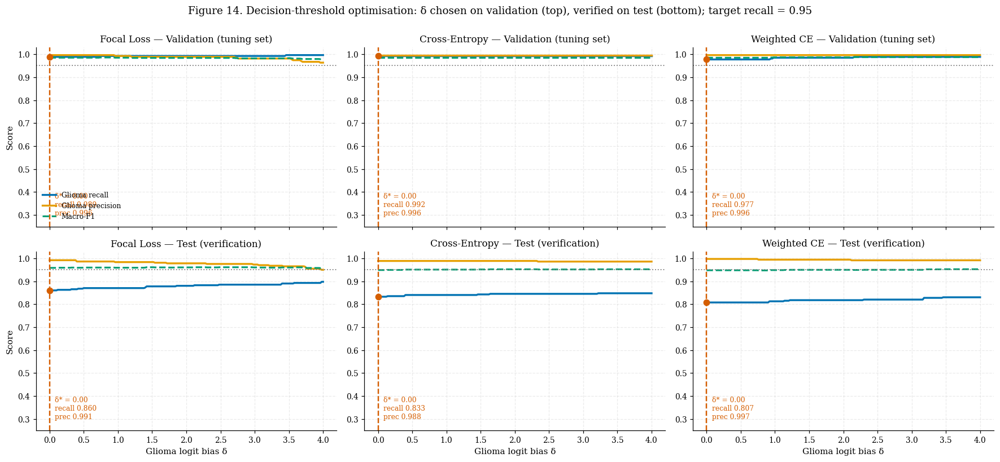

In [30]:
fig, axes = plt.subplots(2, len(ARMS), figsize=(5.4 * len(ARMS), 7.4), sharex=True)
for j, a in enumerate(ARMS):
    for i, (S, tag) in enumerate([(SWEEP_VAL[a], "Validation (tuning set)"), (SWEEP_TEST[a], "Test (verification)")]):
        ax_ = axes[i, j]
        ax_.plot(S.delta, S.glioma_recall, color=CB[0], lw=2.2, label="Glioma recall")
        ax_.plot(S.delta, S.glioma_precision, color=CB[1], lw=2.2, label="Glioma precision")
        ax_.plot(S.delta, S.macro_f1, color=CB[2], lw=2.0, ls="--", label="Macro-F1")
        ax_.axhline(TARGET, color="grey", ls=":", lw=1.2)
        ax_.axvline(DELTA[a], color=CB[3], ls="--", lw=1.6)
        at = S.iloc[(np.abs(S.delta - DELTA[a])).argmin()]
        ax_.scatter([DELTA[a]], [at.glioma_recall], color=CB[3], zorder=5, s=45)
        ax_.text(DELTA[a] + 0.08, 0.30, f"δ* = {DELTA[a]:.2f}\nrecall {at.glioma_recall:.3f}\nprec {at.glioma_precision:.3f}",
                 fontsize=8, color=CB[3])
        ax_.set(ylim=(0.25, 1.03), title=f"{LOSS_NAME[a]} — {tag}")
        if i == 1: ax_.set_xlabel("Glioma logit bias δ")
        if j == 0: ax_.set_ylabel("Score")
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle(f"Figure 14. Decision-threshold optimisation: δ chosen on validation (top), verified on test (bottom); "
             f"target recall = {TARGET:.2f}", y=1.0)
plt.tight_layout(); savefig(fig, "fig14_threshold_sweep"); plt.show()

### Figure 15 — What the tuned threshold actually bought and cost

**How to read it.** Panel (a) is the trade in its most concrete form: **missed gliomas** (false negatives) against
**false glioma alarms** (false positives), before and after tuning, as raw image counts. Arrows point from the
untuned to the tuned operating point; a good trade moves far left for a small move up.

Panel (b) shows the change in every class's recall, so you can see who paid for the glioma gain — typically
meningioma, the class most often confused with glioma. Panel (c) summarises the headline metrics before and after.

This is the figure to put in the thesis when you argue that the deployed system should not use arg-max. It converts
an abstract threshold into a sentence a clinician can evaluate: *"we avoid N missed gliomas at the price of M extra
confirmatory reads."*

  saved -> figures/fig15_threshold_costbenefit.png / .pdf


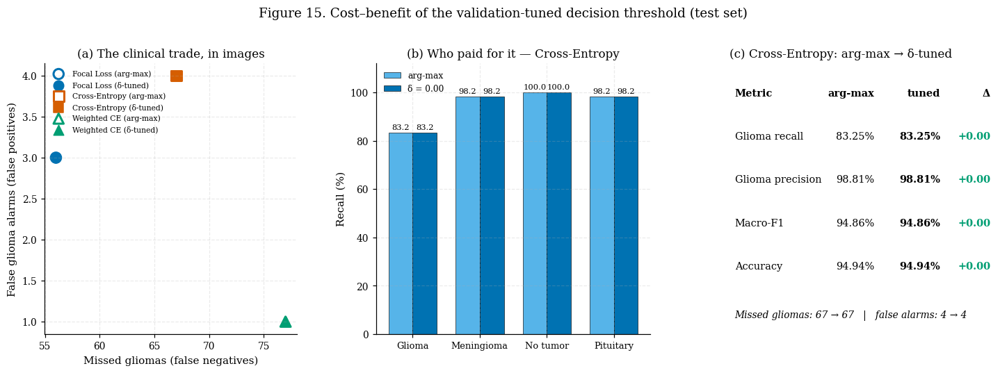

In [31]:
fig = plt.figure(figsize=(16, 4.6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.15, 1.25, 1.2], wspace=0.3)

# (a) FN vs FP trade
a = fig.add_subplot(gs[0])
for arm in ARMS:
    t = TUNED[arm]
    a.scatter(t["fn_before"], t["fp_before"], color=LOSS_COL[arm], marker=LOSS_MARK[arm], s=90,
              facecolors="none", lw=2, label=f"{LOSS_NAME[arm]} (arg-max)")
    a.scatter(t["fn_after"], t["fp_after"], color=LOSS_COL[arm], marker=LOSS_MARK[arm], s=90,
              label=f"{LOSS_NAME[arm]} (δ-tuned)")
    a.annotate("", xy=(t["fn_after"], t["fp_after"]), xytext=(t["fn_before"], t["fp_before"]),
               arrowprops=dict(arrowstyle="->", color=LOSS_COL[arm], lw=1.6, alpha=0.8))
a.set(xlabel="Missed gliomas (false negatives)", ylabel="False glioma alarms (false positives)",
      title="(a) The clinical trade, in images")
a.legend(fontsize=7, frameon=False, ncol=1)

# (b) per-class recall change for the main arm
a = fig.add_subplot(gs[1])
r_before = precision_recall_fscore_support(y_test, PRED[MAIN_ARM], labels=range(NC), zero_division=0)[1]
r_after = precision_recall_fscore_support(y_test, TUNED[MAIN_ARM]["pred"], labels=range(NC), zero_division=0)[1]
x = np.arange(NC); w = 0.36
b1 = a.bar(x - w/2, r_before * 100, w, color=CB[5], edgecolor="black", lw=0.4, label="arg-max")
b2 = a.bar(x + w/2, r_after * 100, w, color=CB[0], edgecolor="black", lw=0.4, label=f"δ = {DELTA[MAIN_ARM]:.2f}")
for bb in (b1, b2): a.bar_label(bb, fmt="%.1f", fontsize=7.5, padding=2)
a.set_xticks(x); a.set_xticklabels(CLS_LABEL, fontsize=8.5)
a.set(ylabel="Recall (%)", title=f"(b) Who paid for it — {LOSS_NAME[MAIN_ARM]}", ylim=(0, 112))
a.legend(frameon=False, fontsize=8)

# (c) headline metrics before/after
a = fig.add_subplot(gs[2]); a.axis("off")
t = TUNED[MAIN_ARM]
rows = [("Glioma recall", t["recall_before"], t["recall_after"]),
        ("Glioma precision", t["precision_before"], t["precision_after"]),
        ("Macro-F1", t["macro_f1_before"], t["macro_f1_after"]),
        ("Accuracy", t["acc_before"], t["acc_after"])]
a.set_title(f"(c) {LOSS_NAME[MAIN_ARM]}: arg-max → δ-tuned", loc="left")
a.text(0.02, 0.88, "Metric", fontsize=9.5, weight="bold")
a.text(0.55, 0.88, "arg-max", fontsize=9.5, weight="bold", ha="right")
a.text(0.80, 0.88, "tuned", fontsize=9.5, weight="bold", ha="right")
a.text(0.99, 0.88, "Δ", fontsize=9.5, weight="bold", ha="right")
for i, (k, v0, v1) in enumerate(rows):
    yy = 0.72 - i * 0.16
    col = CB[2] if v1 >= v0 else CB[3]
    a.text(0.02, yy, k, fontsize=9.5)
    a.text(0.55, yy, f"{v0*100:.2f}%", fontsize=9.5, ha="right")
    a.text(0.80, yy, f"{v1*100:.2f}%", fontsize=9.5, ha="right", weight="bold")
    a.text(0.99, yy, f"{(v1-v0)*100:+.2f}", fontsize=9.5, ha="right", color=col, weight="bold")
a.text(0.02, 0.06, f"Missed gliomas: {t['fn_before']} → {t['fn_after']}   |   "
                   f"false alarms: {t['fp_before']} → {t['fp_after']}", fontsize=9, style="italic")
fig.suptitle("Figure 15. Cost–benefit of the validation-tuned decision threshold (test set)", y=1.04)
savefig(fig, "fig15_threshold_costbenefit"); plt.show()

### Figure 16 — Operating-point frontier: recall bought versus macro-F1 spent

**How to read it.** Each curve traces one arm as $\delta$ sweeps from 0 upward, plotting **glioma recall on the
x-axis against macro-F1 on the y-axis**. This is a Pareto view: up and to the right is better, and a curve that lies
above another at the same recall is strictly preferable.

The markers show the arg-max point (hollow) and the tuned point (filled). Read three things off it:

1. **Which arm dominates.** If one curve sits above the others across the useful recall range, that arm is the right
   backbone regardless of where the operating point is finally set.
2. **The elbow.** Where a curve starts to fall steeply, additional recall becomes expensive — this is the honest
   place to set an operating point, and it is a far better justification than "we chose 0.95 because it is round".
3. **Whether training-time weighting and test-time thresholding overlap.** If the weighted-CE curve is merely the CE
   curve shifted along itself, the two mechanisms are redundant and the simpler one (thresholding) should be
   preferred. If weighted-CE's curve sits genuinely higher, the weighting bought something a threshold cannot.

That third point is a real contribution: the literature routinely applies both without ever checking whether they do
the same job.

  saved -> figures/fig16_operating_frontier.png / .pdf


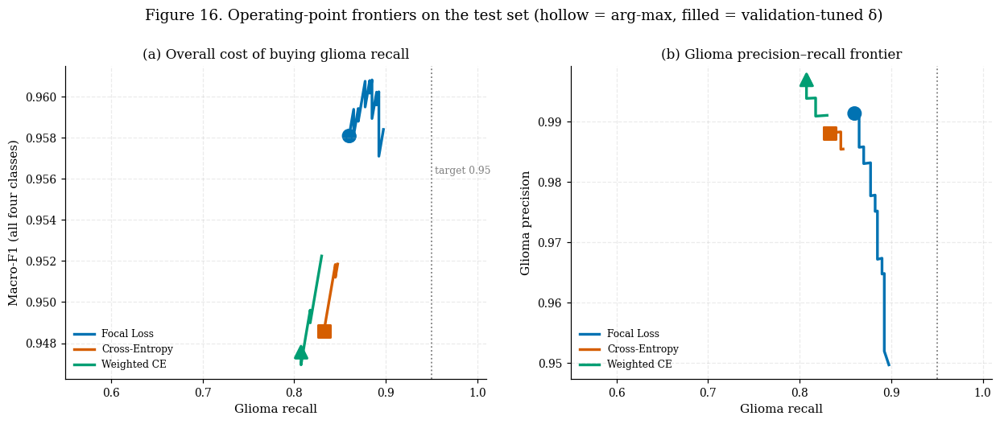

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))
for arm in ARMS:
    S = SWEEP_TEST[arm]
    ax[0].plot(S.glioma_recall, S.macro_f1, color=LOSS_COL[arm], lw=2.2, label=LOSS_NAME[arm])
    ax[1].plot(S.glioma_recall, S.glioma_precision, color=LOSS_COL[arm], lw=2.2, label=LOSS_NAME[arm])
    t = TUNED[arm]
    ax[0].scatter([t["recall_before"]], [t["macro_f1_before"]], color=LOSS_COL[arm], marker=LOSS_MARK[arm],
                  s=95, facecolors="none", lw=2)
    ax[0].scatter([t["recall_after"]], [t["macro_f1_after"]], color=LOSS_COL[arm], marker=LOSS_MARK[arm], s=95)
    ax[1].scatter([t["recall_before"]], [t["precision_before"]], color=LOSS_COL[arm], marker=LOSS_MARK[arm],
                  s=95, facecolors="none", lw=2)
    ax[1].scatter([t["recall_after"]], [t["precision_after"]], color=LOSS_COL[arm], marker=LOSS_MARK[arm], s=95)
for a_, ylab, ttl in [(ax[0], "Macro-F1 (all four classes)", "(a) Overall cost of buying glioma recall"),
                      (ax[1], "Glioma precision", "(b) Glioma precision–recall frontier")]:
    a_.axvline(TARGET, color="grey", ls=":", lw=1.2)
    a_.set(xlabel="Glioma recall", ylabel=ylab, title=ttl, xlim=(0.55, 1.01))
    a_.legend(frameon=False, fontsize=8, loc="lower left")
ax[0].text(TARGET + 0.004, ax[0].get_ylim()[0] + 0.01, f"target {TARGET}", fontsize=8, color="grey")
fig.suptitle("Figure 16. Operating-point frontiers on the test set (hollow = arg-max, filled = validation-tuned δ)",
             y=1.02)
savefig(fig, "fig16_operating_frontier"); plt.show()

## 10. Calibration analysis

### Figure 17 — Reliability diagrams for every arm, raw and temperature-scaled

**How to read it.** Predictions are grouped into 15 confidence bins. The coloured bar is the **observed accuracy**
in that bin; the dashed diagonal is perfect calibration. The hatched red bar is the **gap** between stated
confidence and observed accuracy:

* bars **below** the diagonal ⇒ **over-confidence** (the model says 95% and is right less often) — the failure mode
  that makes a confidence score unusable for triage;
* bars **above** ⇒ under-confidence, which wastes capacity but is safer.

The strip beneath each diagram is the **bin population on a log scale**, and it is essential context: a large gap in
a bin holding four images is noise, while a small gap in a bin holding eight hundred dominates ECE. Judge the
diagram and the histogram together, never the diagram alone.

Panels (d–f) repeat the analysis after temperature scaling with $T$ fitted on validation. Since $T$ cannot reorder
logits, **accuracy is identical** in the top and bottom rows by construction; only the confidence changes. $T > 1$
means the raw model was over-confident, $T < 1$ under-confident.

  saved -> figures/fig17_reliability_diagrams.png / .pdf


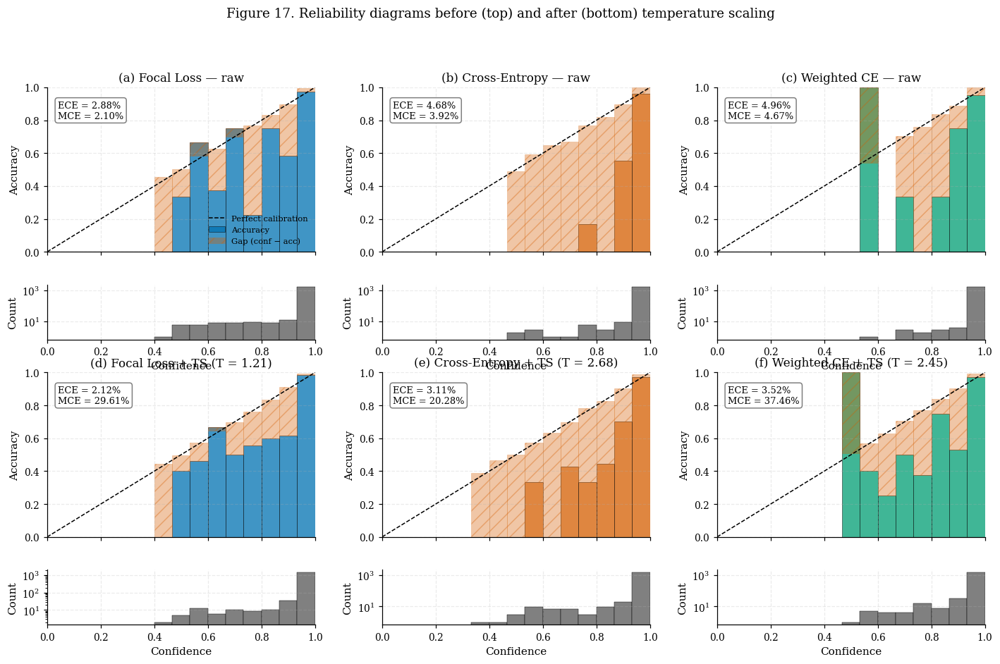

In [33]:
def reliability(ax, ax_h, probs, y, title, color, n_bins=15):
    conf, pred = probs.max(1), probs.argmax(1); acc = (pred == y).astype(float)
    edges = np.linspace(0, 1, n_bins + 1); ctr = (edges[:-1] + edges[1:]) / 2; wdt = 1 / n_bins
    accs, confs, cnts = np.zeros(n_bins), np.zeros(n_bins), np.zeros(n_bins)
    for b, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        m = (conf > lo) & (conf <= hi)
        if m.any(): accs[b], confs[b], cnts[b] = acc[m].mean(), conf[m].mean(), m.sum()
    has = cnts > 0
    ax.bar(ctr[has], accs[has], width=wdt, color=color, alpha=0.75, edgecolor="black", lw=0.4, label="Accuracy")
    ax.bar(ctr[has], confs[has] - accs[has], bottom=accs[has], width=wdt, color="#D55E00", alpha=0.35,
           edgecolor="#D55E00", hatch="//", lw=0.4, label="Gap (conf − acc)")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
    e, m_ = ece_mce(probs, y, n_bins)
    ax.text(0.04, 0.92, f"ECE = {e*100:.2f}%\nMCE = {m_*100:.2f}%", transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle="round", fc="white", ec="grey"), va="top")
    ax.set(xlim=(0, 1), ylim=(0, 1), ylabel="Accuracy", title=title); ax.set_xticklabels([])
    ax_h.bar(ctr, cnts, width=wdt, color="grey", edgecolor="black", lw=0.3); ax_h.set_yscale("log")
    ax_h.set(xlim=(0, 1), xlabel="Confidence", ylabel="Count")

letters = "abcdef"
fig = plt.figure(figsize=(5.2 * len(ARMS), 9.0))
gs = gridspec.GridSpec(4, len(ARMS), height_ratios=[3, 1, 3, 1], hspace=0.30, wspace=0.25)
for j, a in enumerate(ARMS):
    reliability(fig.add_subplot(gs[0, j]), fig.add_subplot(gs[1, j]), softmax_np(LOG[a]), y_test,
                f"({letters[j]}) {LOSS_NAME[a]} — raw", LOSS_COL[a])
    T = RUNS[(a, MS)]["T"]
    reliability(fig.add_subplot(gs[2, j]), fig.add_subplot(gs[3, j]), softmax_np(LOG[a], T), y_test,
                f"({letters[j+len(ARMS)]}) {LOSS_NAME[a]} + TS (T = {T:.2f})", LOSS_COL[a])
fig.axes[0].legend(loc="lower right", fontsize=7.5, frameon=False)
fig.suptitle("Figure 17. Reliability diagrams before (top) and after (bottom) temperature scaling", y=0.995)
savefig(fig, "fig17_reliability_diagrams"); plt.show()

### Figure 18 — Does confidence separate correct from incorrect predictions?

**How to read it.** Two density histograms per arm on a log scale: confidence of **correct** predictions (green)
against **incorrect** ones (orange). Calibration in the ECE sense is about matching confidence to accuracy *on
average*; this figure asks a different and more operationally relevant question — **can a threshold on confidence
find the errors?**

The legend reports the **error-detection AUROC**: the probability that a randomly chosen correct prediction is more
confident than a randomly chosen incorrect one. 0.5 means confidence is useless for flagging errors; above ~0.85
means a triage system built on it will work. A model can be badly calibrated yet still excellent at this, and
vice-versa, which is exactly why both figures belong in the thesis.

  saved -> figures/fig18_confidence_hist.png / .pdf


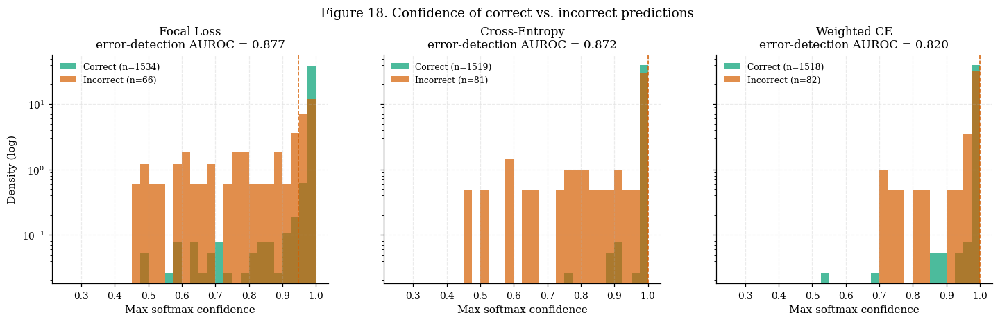

In [34]:
fig, ax = plt.subplots(1, len(ARMS), figsize=(5.3 * len(ARMS), 3.9), sharey=True)
for a_, arm in zip(np.atleast_1d(ax), ARMS):
    conf = PROB[arm].max(1); ok = PRED[arm] == y_test
    au = roc_auc_score(ok.astype(int), conf)
    bins = np.linspace(0.25, 1, 31)
    a_.hist(conf[ok], bins=bins, color=CB[2], alpha=0.7, label=f"Correct (n={ok.sum()})", density=True)
    a_.hist(conf[~ok], bins=bins, color=CB[3], alpha=0.7, label=f"Incorrect (n={(~ok).sum()})", density=True)
    a_.axvline(np.median(conf[~ok]), color=CB[3], ls="--", lw=1)
    a_.set(title=f"{LOSS_NAME[arm]}\nerror-detection AUROC = {au:.3f}", xlabel="Max softmax confidence")
    a_.set_yscale("log"); a_.legend(frameon=False, loc="upper left", fontsize=8)
np.atleast_1d(ax)[0].set_ylabel("Density (log)")
fig.suptitle("Figure 18. Confidence of correct vs. incorrect predictions", y=1.04)
savefig(fig, "fig18_confidence_hist"); plt.show()

### Figure 19 — Calibration metric summary and class-wise calibration

**How to read it.** Panel (a) puts four calibration scores side by side for every arm, raw and temperature-scaled —
lower is better throughout. ECE and MCE measure the confidence–accuracy gap directly; **Brier and NLL are proper
scoring rules**, meaning they are minimised only by reporting your true beliefs, so they cannot be improved by
confidence manipulation alone. When ECE improves but Brier does not, the "improvement" was cosmetic.

Panel (b) decomposes ECE by class. Miscalibration is rarely uniform: it concentrates in the class the model finds
hardest, which here is expected to be glioma. A class-wise view tells you *where* an aggregate number comes from,
and lets you say something specific in the thesis instead of quoting one global percentage.

  saved -> figures/fig19_calibration_summary.png / .pdf


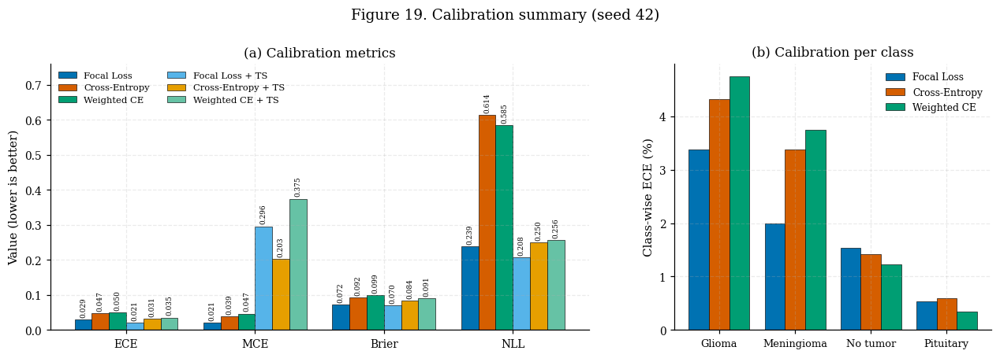

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.0), gridspec_kw={"width_ratios": [1.7, 1]})
metrics = ["ece", "mce", "brier", "nll"]; lab = ["ECE", "MCE", "Brier", "NLL"]
variants = [(a, 1.0, LOSS_NAME[a]) for a in ARMS] + [(a, RUNS[(a, MS)]["T"], LOSS_NAME[a] + " + TS") for a in ARMS]
cols = [LOSS_COL[a] for a in ARMS] + ["#56B4E9", "#E69F00", "#66C2A5"]
x = np.arange(len(metrics)); w = 0.8 / len(variants)
for j, (arm, T, name) in enumerate(variants):
    m = all_metrics(softmax_np(LOG[arm], T), y_test)
    b = ax[0].bar(x + (j - (len(variants) - 1) / 2) * w, [m[k] for k in metrics], w,
                  color=cols[j], edgecolor="black", lw=0.4, label=name)
    ax[0].bar_label(b, labels=[f"{m[k]:.3f}" for k in metrics], fontsize=5.8, rotation=90, padding=2)
ax[0].set_xticks(x); ax[0].set_xticklabels(lab); ax[0].set_ylabel("Value (lower is better)")
ax[0].set_title("(a) Calibration metrics"); ax[0].legend(frameon=False, ncol=2, fontsize=7.5)
ax[0].set_ylim(0, ax[0].get_ylim()[1] * 1.18)

cw = {a: classwise_ece(PROB[a], y_test) for a in ARMS}
xx = np.arange(NC); w2 = 0.8 / len(ARMS)
for j, arm in enumerate(ARMS):
    ax[1].bar(xx + (j - (len(ARMS) - 1) / 2) * w2, cw[arm] * 100, w2, color=LOSS_COL[arm],
              label=LOSS_NAME[arm], edgecolor="black", lw=0.4)
ax[1].set_xticks(xx); ax[1].set_xticklabels(CLS_LABEL, fontsize=8.5); ax[1].set_ylabel("Class-wise ECE (%)")
ax[1].set_title("(b) Calibration per class"); ax[1].legend(frameon=False, fontsize=8)
fig.suptitle(f"Figure 19. Calibration summary (seed {MS})", y=1.04)
savefig(fig, "fig19_calibration_summary"); plt.show()

## 11. Selective prediction and confidence-based triage

A deployed system does not have to answer every case. If the confidence score is informative — which Figure 18
tests — the model can **abstain** on its least certain inputs and route them to a radiologist. This converts a fixed
accuracy into a **tunable** one.

### Figure 20 — Risk–coverage curve and measured triage tiers

**How to read it.** Panel (a): the x-axis is **coverage**, the share of cases the model answers automatically,
starting from the most confident. At 100% coverage you see plain test accuracy; moving left, the least confident
cases are deferred and accuracy on the remainder rises. A steep early rise means errors really do concentrate at low
confidence. **AURC** (area under the risk–coverage curve, lower is better) summarises the whole curve in one number
and is the right metric to compare arms for a triage application.

Panel (b) turns the curve into an operational proposal with **measured** numbers: how many cases fall in each
confidence tier and how accurate the model is inside each. The sentence this figure supports in the thesis is of the
form *"deferring the least confident X% of cases raises accuracy on the remainder to Y%, at a review burden of Z
cases per thousand"* — with every number computed, not assumed.

Measured triage tiers (Cross-Entropy):
                     share_%     n  accuracy_%  errors
High (≥0.90)        98.7500  1580     95.9500      64
Medium (0.70–0.90)   0.8100    13     23.0800      10
Low (<0.70)          0.4400     7      0.0000       7
  saved -> figures/fig20_risk_coverage_triage.png / .pdf


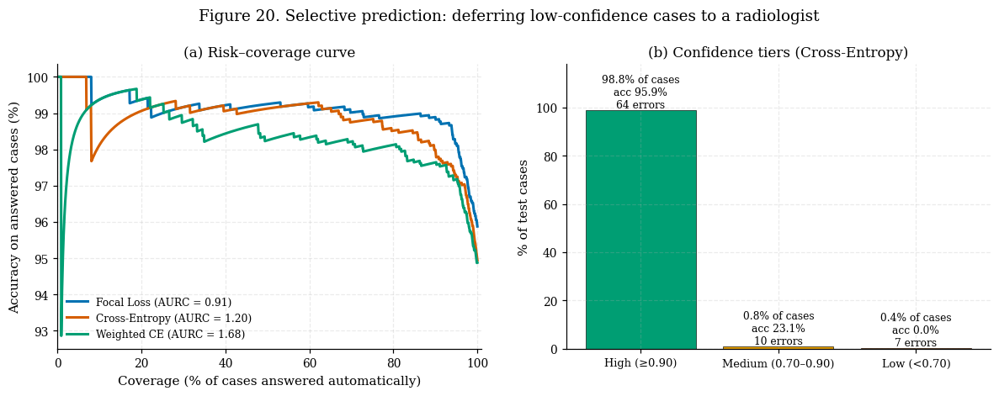

In [36]:
def risk_coverage(probs, y):
    conf = probs.max(1); order = np.argsort(-conf); ok = (probs.argmax(1) == y)[order]
    cov = np.arange(1, len(y) + 1) / len(y); acc = np.cumsum(ok) / np.arange(1, len(y) + 1)
    return cov, acc, float(np.mean(1 - acc))   # AURC

fig, ax = plt.subplots(1, 2, figsize=(13, 4.0))
AURC = {}
for arm in ARMS:
    cov, acc, aurc = risk_coverage(PROB[arm], y_test); AURC[arm] = aurc
    ax[0].plot(cov * 100, acc * 100, color=LOSS_COL[arm], lw=2, label=f"{LOSS_NAME[arm]} (AURC = {aurc*100:.2f})")
ax[0].set(xlabel="Coverage (% of cases answered automatically)", ylabel="Accuracy on answered cases (%)",
          title="(a) Risk–coverage curve", xlim=(0, 101))
ax[0].legend(frameon=False, loc="lower left", fontsize=8)

hi_t, lo_t = CONFIG["triage_thresholds"]
conf = PROB[MAIN_ARM].max(1); ok = PRED[MAIN_ARM] == y_test
tiers = {f"High (≥{hi_t:.2f})": conf >= hi_t,
         f"Medium ({lo_t:.2f}–{hi_t:.2f})": (conf >= lo_t) & (conf < hi_t),
         f"Low (<{lo_t:.2f})": conf < lo_t}
TRIAGE = pd.DataFrame({"share_%": [m.mean() * 100 for m in tiers.values()],
                       "n": [int(m.sum()) for m in tiers.values()],
                       "accuracy_%": [ok[m].mean() * 100 if m.any() else np.nan for m in tiers.values()],
                       "errors": [int((~ok[m]).sum()) for m in tiers.values()]}, index=list(tiers))
print(f"Measured triage tiers ({LOSS_NAME[MAIN_ARM]}):\n", TRIAGE.round(2))
b = ax[1].bar(range(3), TRIAGE["share_%"], color=[CB[2], CB[1], CB[3]], edgecolor="black", lw=0.4)
ax[1].bar_label(b, labels=[f"{s:.1f}% of cases\nacc {a:.1f}%\n{e} errors" for s, a, e in
                           zip(TRIAGE["share_%"], TRIAGE["accuracy_%"].fillna(0), TRIAGE["errors"])], fontsize=8)
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(TRIAGE.index, fontsize=8.5)
ax[1].set_ylabel("% of test cases"); ax[1].set_ylim(0, 118)
ax[1].set_title(f"(b) Confidence tiers ({LOSS_NAME[MAIN_ARM]})")
fig.suptitle("Figure 20. Selective prediction: deferring low-confidence cases to a radiologist", y=1.03)
savefig(fig, "fig20_risk_coverage_triage"); plt.show()

## 12. Robustness to acquisition-style corruption

### The implementation detail that invalidated an earlier version

Corruptions **must** be applied in pixel space $[0,1]$ and the result re-normalised. An earlier version of this
pipeline added noise to *already normalised* tensors and then clamped to $[0,1]$, which deletes every negative
value — i.e. most of the image — and produced a spurious 43% collapse that looked like a dramatic robustness
failure. The corrected pipeline is:

$$x_{\text{pixel}} = x\cdot\sigma + \mu \;\longrightarrow\; \text{corrupt} \;\longrightarrow\; x' = (x_{\text{corrupt}} - \mu)/\sigma$$

An **identity-corruption assertion** runs first: passing images through the corruption harness with a no-op must
reproduce clean accuracy exactly. If that assertion ever fails, every robustness number below is meaningless. Build
this check into any corruption study you write.

| Corruption | Severity 1 → 5 | Real-world analogue |
|---|---|---|
| Gaussian noise | σ = 0.04 → 0.20 | low field strength, short acquisition, low SNR |
| Motion blur (horizontal) | kernel 3 → 11 px | patient movement during acquisition |
| Intensity scaling | × 0.90 → 1.20 | scanner gain, vendor intensity conventions |

**Limitation to state plainly:** these are *synthetic* perturbations. They measure sensitivity to controlled
degradation, not true cross-scanner generalisation, which requires multi-site data this dataset does not provide.

In [37]:
MEAN_T = torch.tensor(MEAN, device=device).view(1, 3, 1, 1)
STD_T  = torch.tensor(STD, device=device).view(1, 3, 1, 1)
to_pix = lambda x: x * STD_T + MEAN_T
to_net = lambda x: (x - MEAN_T) / STD_T

def c_noise(x, s, g):
    p = to_pix(x); return to_net(torch.clamp(p + torch.randn(p.shape, generator=g, device=p.device) * s, 0, 1))
def c_blur(x, k, g=None):
    ker = torch.zeros(3, 1, 1, k, device=x.device); ker[..., :] = 1.0 / k
    p = F.conv2d(F.pad(to_pix(x), (k // 2, k // 2, 0, 0), mode="replicate"), ker, groups=3)
    return to_net(torch.clamp(p, 0, 1))
def c_int(x, m, g=None): return to_net(torch.clamp(to_pix(x) * m, 0, 1))

CORR = {"Gaussian noise": (c_noise, CONFIG["severities"]["gaussian_noise"]),
        "Motion blur":    (c_blur,  CONFIG["severities"]["motion_blur"]),
        "Intensity scaling": (c_int, CONFIG["severities"]["intensity"])}

@torch.no_grad()
def eval_corrupted(model, fn, level, seed=0):
    model.eval(); g = torch.Generator(device=device); g.manual_seed(seed); probs = []
    for x, _ in test_loader:
        x = fn(x.to(device), level, g)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            z = model(x).float()
        probs.append(F.softmax(z, 1).cpu())
    return torch.cat(probs).numpy()

P_chk = eval_corrupted(MODELS[MAIN_ARM], lambda x, lv, g: x, None)
assert abs(accuracy_score(y_test, P_chk.argmax(1)) - main[MAIN_ARM]["accuracy"]) < 1e-3, "pipeline mismatch!"
print("Sanity check passed: identity corruption reproduces clean accuracy exactly.\n")

rob_rows = []
for arm in ARMS:
    clean_f1 = main[arm]["macro_f1"]
    for cname, (fn, levels) in CORR.items():
        for sev, lv in enumerate(levels, 1):
            P = eval_corrupted(MODELS[arm], fn, lv)
            pr = P.argmax(1); e, _ = ece_mce(P, y_test)
            rec_c = precision_recall_fscore_support(y_test, pr, labels=range(NC), zero_division=0)[1]
            f1v = f1_score(y_test, pr, average="macro")
            rob_rows.append({"arm": LOSS_NAME[arm], "arm_key": arm, "corruption": cname, "severity": sev,
                             "param": lv, "macro_f1": f1v, "delta_f1_%": (f1v - clean_f1) / clean_f1 * 100,
                             "accuracy": accuracy_score(y_test, pr), "glioma_recall": rec_c[GLIOMA], "ece": e,
                             **{f"recall_{CLS_LABEL[k]}": rec_c[k] for k in range(NC)}})
            print(f"{LOSS_NAME[arm]:13s} | {cname:17s} sev {sev} ({lv}) | F1 {f1v:.4f} "
                  f"({rob_rows[-1]['delta_f1_%']:+.2f}%) | glioma recall {rec_c[GLIOMA]:.3f} | ECE {e:.4f}")
ROB = pd.DataFrame(rob_rows); ROB.to_csv(os.path.join(OUT_DIR, "robustness.csv"), index=False)

ROB_SUMMARY = {}
for arm in ARMS:
    r = ROB[ROB.arm_key == arm]
    ROB_SUMMARY[arm] = {"mean_delta_f1_%": float(r["delta_f1_%"].mean()),
                        "worst_delta_f1_%": float(r["delta_f1_%"].min()),
                        "worst_condition": r.loc[r["delta_f1_%"].idxmin(), ["corruption", "severity"]].tolist()}
print("\nRobustness summary:", json.dumps(ROB_SUMMARY, indent=2, default=str))
rf = ROB[ROB.arm_key == MAIN_ARM]

Sanity check passed: identity corruption reproduces clean accuracy exactly.

Focal Loss    | Gaussian noise    sev 1 (0.04) | F1 0.9549 (-0.33%) | glioma recall 0.850 | ECE 0.0315
Focal Loss    | Gaussian noise    sev 2 (0.08) | F1 0.9550 (-0.32%) | glioma recall 0.855 | ECE 0.0308
Focal Loss    | Gaussian noise    sev 3 (0.12) | F1 0.9493 (-0.92%) | glioma recall 0.850 | ECE 0.0311
Focal Loss    | Gaussian noise    sev 4 (0.16) | F1 0.9285 (-3.09%) | glioma recall 0.830 | ECE 0.0406
Focal Loss    | Gaussian noise    sev 5 (0.2) | F1 0.8945 (-6.63%) | glioma recall 0.818 | ECE 0.0608
Focal Loss    | Motion blur       sev 1 (3) | F1 0.9562 (-0.19%) | glioma recall 0.853 | ECE 0.0330
Focal Loss    | Motion blur       sev 2 (5) | F1 0.9537 (-0.45%) | glioma recall 0.848 | ECE 0.0343
Focal Loss    | Motion blur       sev 3 (7) | F1 0.9471 (-1.15%) | glioma recall 0.843 | ECE 0.0383
Focal Loss    | Motion blur       sev 4 (9) | F1 0.9363 (-2.28%) | glioma recall 0.843 | ECE 0.0443
Focal Los

### Figure 21 — Corruption examples and degradation curves

**How to read it.** The top three rows show one test image at every severity, so you can judge visually whether the
corruption is plausible. This is not decoration: if severity 5 renders the anatomy unrecognisable to a human, then a
model failing there is not a finding, it is arithmetic. Check that severity 3–4 still looks like a usable, if poor,
clinical image.

The bottom row plots macro-F1 against severity for all arms, with the dashed line marking clean performance. Flat
curves mean insensitivity; steep drops identify genuine failure modes. Expect intensity scaling to be nearly flat
(the augmentation pipeline trained brightness jitter directly) and Gaussian noise to be the steepest, since noise
attacks the fine texture cues that distinguish tumor tissue.

  saved -> figures/fig21_robustness.png / .pdf


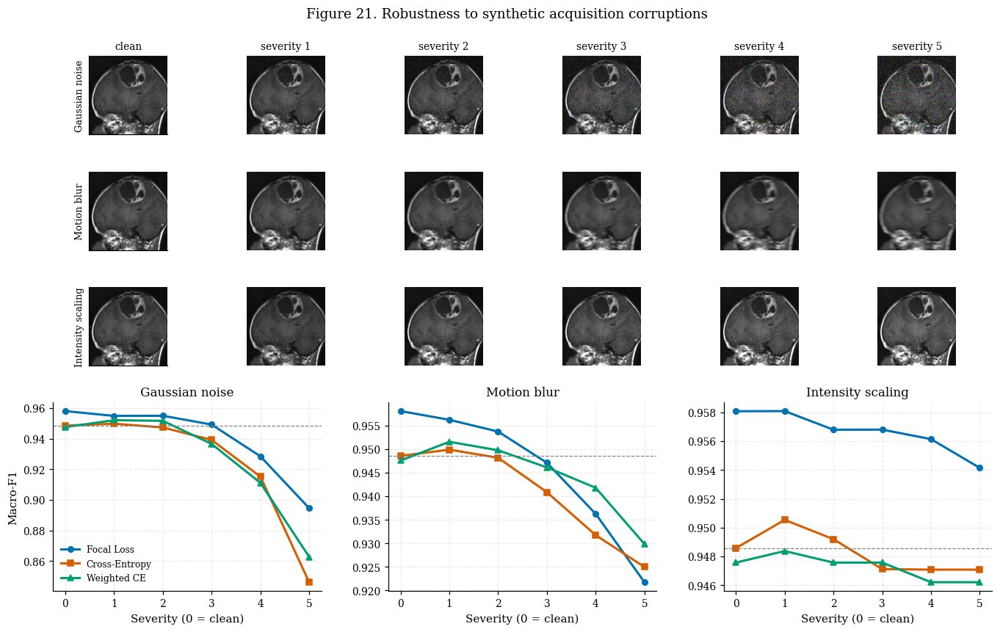

In [38]:
x0 = test_ds[int(np.where(y_test == GLIOMA)[0][5])][0].unsqueeze(0).to(device)
fig = plt.figure(figsize=(15, 8.6))
gs = gridspec.GridSpec(4, 6, height_ratios=[1, 1, 1, 2.4], hspace=0.35, wspace=0.05)
for r, (cname, (fn, levels)) in enumerate(CORR.items()):
    ax_ = fig.add_subplot(gs[r, 0]); ax_.imshow(denorm(x0[0].cpu())); ax_.set_xticks([]); ax_.set_yticks([])
    ax_.set_ylabel(cname, fontsize=8.5)
    if r == 0: ax_.set_title("clean", fontsize=9)
    g = torch.Generator(device=device); g.manual_seed(0)
    for s, lv in enumerate(levels, 1):
        ax_ = fig.add_subplot(gs[r, s]); ax_.imshow(denorm(fn(x0, lv, g)[0].cpu())); ax_.axis("off")
        if r == 0: ax_.set_title(f"severity {s}", fontsize=9)
sub = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[3, :], wspace=0.25)
for j, cname in enumerate(CORR):
    ax_ = fig.add_subplot(sub[j])
    for arm in ARMS:
        d = ROB[(ROB.arm_key == arm) & (ROB.corruption == cname)]
        ax_.plot([0] + d.severity.tolist(), [main[arm]["macro_f1"]] + d.macro_f1.tolist(),
                 marker=LOSS_MARK[arm], color=LOSS_COL[arm], lw=2, ms=5, label=LOSS_NAME[arm])
    ax_.axhline(main[MAIN_ARM]["macro_f1"], color="grey", ls="--", lw=0.8)
    ax_.set(title=cname, xlabel="Severity (0 = clean)", xticks=range(6))
    ax_.set_ylabel("Macro-F1" if j == 0 else "")
    if j == 0: ax_.legend(frameon=False, loc="lower left", fontsize=8)
fig.suptitle("Figure 21. Robustness to synthetic acquisition corruptions", y=0.95)
savefig(fig, "fig21_robustness"); plt.show()

### Figure 22 — Which class breaks first under corruption?

**How to read it.** Each cell is the **recall** of one class (column) under one corruption/severity (row), for the
main arm. Green is high recall, red is low. The top row is clean performance for reference, and horizontal rules
separate the three corruption families.

This heat map answers a question the aggregate F1 curve hides: *does degradation cause missed tumors or false
alarms?* If a tumor column goes red while "no tumor" stays green, the corrupted model is **under-calling** tumors —
the dangerous direction. If "no tumor" collapses while tumor columns hold, it is over-calling, which is merely
expensive. For a safety discussion in the thesis, that distinction matters more than the mean ΔF1.

  saved -> figures/fig22_robustness_class_heatmap.png / .pdf


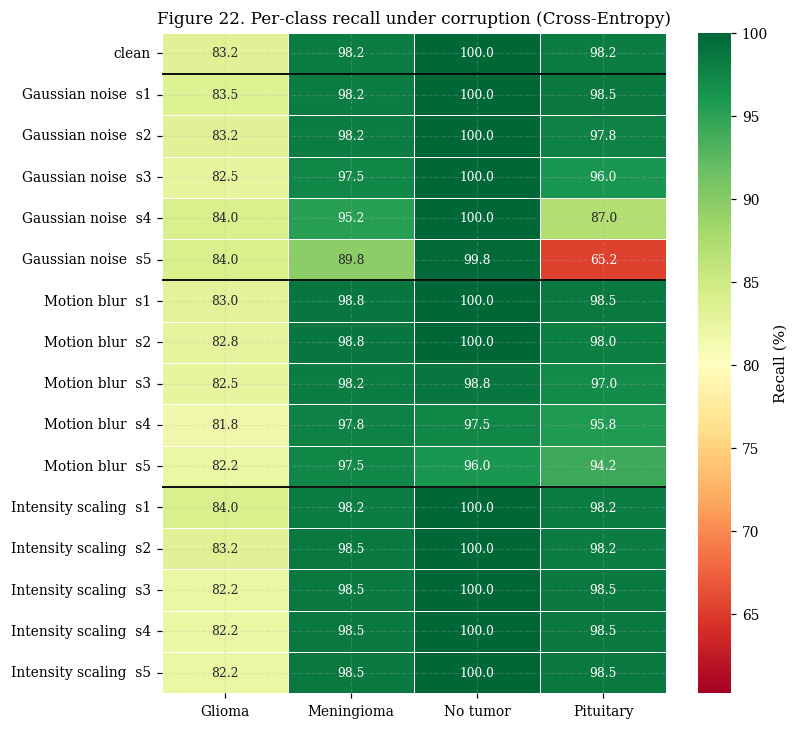

In [39]:
hm = rf.set_index(rf["corruption"] + "  s" + rf["severity"].astype(str))[[f"recall_{c}" for c in CLS_LABEL]]
hm.columns = CLS_LABEL
clean_row = pd.DataFrame([PER_CLASS["recall"].values], columns=CLS_LABEL, index=["clean"])
hm = pd.concat([clean_row, hm])
fig, ax = plt.subplots(figsize=(7.4, 7.8))
sns.heatmap(hm * 100, annot=True, fmt=".1f", cmap="RdYlGn", vmin=max(0, (hm.values.min() * 100) - 5), vmax=100,
            cbar_kws={"label": "Recall (%)"}, ax=ax, linewidths=0.4, annot_kws={"fontsize": 8})
for y_ in [1, 6, 11]: ax.axhline(y_, color="black", lw=1.2)
ax.set_title(f"Figure 22. Per-class recall under corruption ({LOSS_NAME[MAIN_ARM]})")
savefig(fig, "fig22_robustness_class_heatmap"); plt.show()

## 13. Out-of-distribution behaviour

A deployed classifier will eventually receive something that is not a brain MRI — a mis-routed body scan, a corrupt
file, a photograph. A softmax over four classes **always** returns one of the four with some confidence; it has no
"none of these" option. So we test whether the **maximum softmax probability (MSP)** (Hendrycks & Gimpel, 2017) is
at least *lower* for such inputs.

| OOD set | Construction | Difficulty |
|---|---|---|
| Gaussian noise | i.i.d. N(0.5, 0.25) pixels | far-OOD |
| Uniform noise | i.i.d. U(0,1) pixels | far-OOD |
| Constant image | single random grey level | far-OOD |
| Patch-shuffled MRI | test MRI cut into 16×16 tiles, permuted | near-OOD: MRI texture, destroyed anatomy |
| Inverted MRI | 1 − pixel value | near-OOD: intact anatomy, wrong contrast |

Metrics: **AUROC** (how well MSP ranks real MRIs above OOD inputs; 0.5 = chance) and **FPR@95%TPR** (the share of
OOD inputs still accepted when the threshold admits 95% of genuine MRIs — the operationally honest number, and
usually far less flattering than AUROC).

**Limitation:** synthetic OOD is much easier than clinical OOD. Near-perfect AUROC on pure noise is **not** evidence
of safe deployment behaviour, and must never be reported as "100% OOD detection".

In [40]:
def make_ood(kind, n, seed=0):
    g = torch.Generator().manual_seed(seed); H = IMG
    if kind == "Gaussian noise":   x = torch.clamp(0.5 + 0.25 * torch.randn(n, 3, H, H, generator=g), 0, 1)
    elif kind == "Uniform noise":  x = torch.rand(n, 3, H, H, generator=g)
    elif kind == "Constant image": x = torch.rand(n, 1, 1, 1, generator=g).expand(n, 3, H, H).clone()
    else:
        idx = torch.randint(0, len(test_raw), (n,), generator=g).tolist()
        base = torch.stack([test_raw[i][0] for i in idx])
        if kind == "Inverted MRI": x = 1 - base
        else:
            P = 16; t = base.unfold(2, P, P).unfold(3, P, P)
            t = t.reshape(n, 3, -1, P, P); perm = torch.randperm(t.shape[2], generator=g)
            t = t[:, :, perm].reshape(n, 3, H // P, H // P, P, P)
            x = t.permute(0, 1, 2, 4, 3, 5).reshape(n, 3, H, H)
    return (x - torch.tensor(MEAN).view(1, 3, 1, 1)) / torch.tensor(STD).view(1, 3, 1, 1)

@torch.no_grad()
def msp_of(model, X, bs=64):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            out.append(F.softmax(model(X[i:i + bs].to(device)).float(), 1).cpu())
    return torch.cat(out).numpy()

def fpr_at_95tpr(id_s, ood_s):
    thr = np.percentile(id_s, 5); return float(np.mean(ood_s >= thr))

OOD_KINDS = ["Gaussian noise", "Uniform noise", "Constant image", "Patch-shuffled MRI", "Inverted MRI"]
OOD_X = {k: make_ood(k, CONFIG["ood_n"], i) for i, k in enumerate(OOD_KINDS)}
ood_rows, OOD_MSP = [], {}
for arm in ARMS:
    id_msp = PROB[arm].max(1)
    for k in OOD_KINDS:
        P = msp_of(MODELS[arm], OOD_X[k]); s = P.max(1); OOD_MSP[(arm, k)] = (s, P.argmax(1))
        yy = np.r_[np.ones(len(id_msp)), np.zeros(len(s))]; sc = np.r_[id_msp, s]
        ood_rows.append({"arm": LOSS_NAME[arm], "arm_key": arm, "ood_set": k,
                         "AUROC": roc_auc_score(yy, sc), "FPR@95TPR": fpr_at_95tpr(id_msp, s),
                         "mean_MSP_ood": float(s.mean()), "mean_MSP_id": float(id_msp.mean()),
                         "rejected@0.55_%": float(np.mean(s < 0.55) * 100)})
OOD = pd.DataFrame(ood_rows); OOD.to_csv(os.path.join(OUT_DIR, "ood.csv"), index=False)
print(OOD.round(4).to_string(index=False))
print(f"\nIn-distribution images wrongly rejected at MSP < 0.55: "
      f"{np.mean(PROB[MAIN_ARM].max(1) < 0.55)*100:.2f}%")

          arm arm_key            ood_set  AUROC  FPR@95TPR  mean_MSP_ood  mean_MSP_id  rejected@0.55_%
   Focal Loss   focal     Gaussian noise 0.9844     0.0000        0.6964       0.9864           0.3333
   Focal Loss   focal      Uniform noise 0.9843     0.0000        0.6975       0.9864           0.6667
   Focal Loss   focal     Constant image 0.9901     0.0000        0.6130       0.9864          22.6667
   Focal Loss   focal Patch-shuffled MRI 0.9149     0.4533        0.9036       0.9864           3.0000
   Focal Loss   focal       Inverted MRI 0.7556     0.4800        0.8621       0.9864          10.0000
Cross-Entropy      ce     Gaussian noise 0.9836     0.0000        0.9466       0.9962           0.3333
Cross-Entropy      ce      Uniform noise 0.9839     0.0000        0.9439       0.9962           0.3333
Cross-Entropy      ce     Constant image 0.9834     0.0000        0.9599       0.9962           0.0000
Cross-Entropy      ce Patch-shuffled MRI 0.9728     0.0433        0.9282 

### Figure 23 — OOD confidence distributions and detection curves

**How to read it.** The top strip shows one example from each OOD set together with the class the model assigns and
its confidence — worth reading carefully, because a model that confidently labels pure noise as a tumor class is
displaying exactly the pathology this thesis is about.

Bottom-left: MSP distributions for real test MRIs (grey filled) against each OOD set (coloured outlines), log
density. **Overlap is the failure**; separation is the goal. Bottom-right: ROC curves for the in-distribution versus
OOD decision.

Expect a clear ordering — pure noise is trivially rejected, patch-shuffled MRI is harder, and **inverted MRI is
hardest of all**, because it preserves anatomy and only changes contrast polarity. That last result is the one to
discuss: the model is keying on structure rather than intensity convention, which is good for robustness and bad for
OOD rejection. Note also **which class** OOD inputs collapse into; a systematic bias toward one tumor class is a
safety finding.

  saved -> figures/fig23_ood.png / .pdf


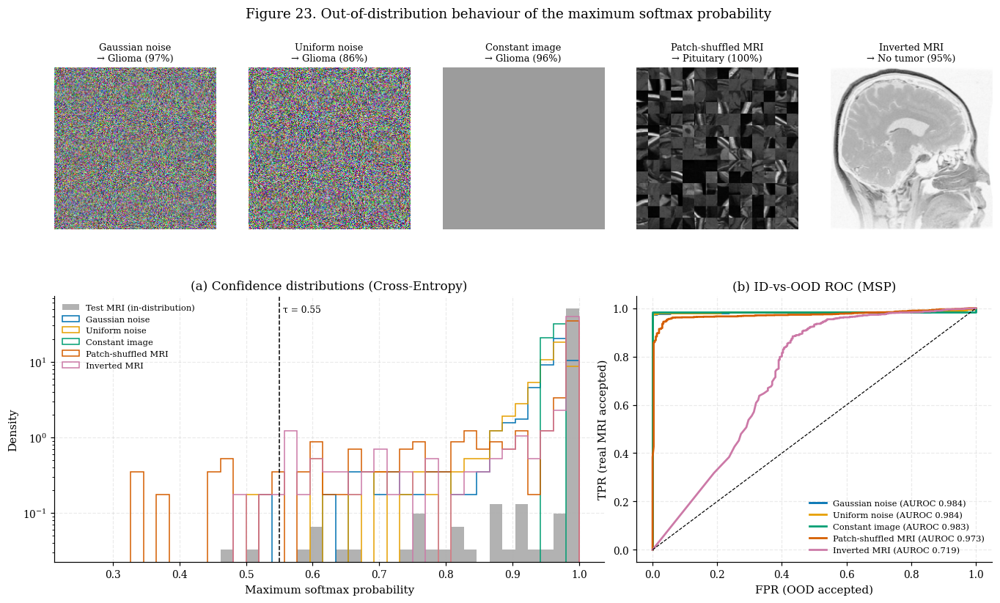

In [41]:
fig = plt.figure(figsize=(15, 8)); gs = gridspec.GridSpec(2, 5, height_ratios=[1, 1.6], hspace=0.3)
for j, k in enumerate(OOD_KINDS):
    a_ = fig.add_subplot(gs[0, j]); a_.imshow(denorm(OOD_X[k][0])); a_.axis("off")
    s, pr = OOD_MSP[(MAIN_ARM, k)]
    a_.set_title(f"{k}\n→ {CLS_LABEL[pr[0]]} ({s[0]*100:.0f}%)", fontsize=8.5)
a1 = fig.add_subplot(gs[1, :3]); a2 = fig.add_subplot(gs[1, 3:])
bins = np.linspace(0.25, 1, 40)
id_msp = PROB[MAIN_ARM].max(1)
a1.hist(id_msp, bins=bins, density=True, color="grey", alpha=0.6, label="Test MRI (in-distribution)")
for j, k in enumerate(OOD_KINDS):
    s = OOD_MSP[(MAIN_ARM, k)][0]
    a1.hist(s, bins=bins, density=True, histtype="step", lw=1.8, color=CB[j], label=k)
    yy = np.r_[np.ones(len(id_msp)), np.zeros(len(s))]
    fpr, tpr, _ = roc_curve(yy, np.r_[id_msp, s])
    au = OOD[(OOD.arm_key == MAIN_ARM) & (OOD.ood_set == k)]["AUROC"].item()
    a2.plot(fpr, tpr, color=CB[j], lw=1.8, label=f"{k} (AUROC {au:.3f})")
a1.axvline(0.55, color="black", ls="--", lw=1); a1.text(0.555, a1.get_ylim()[1] * 0.85, "τ = 0.55", fontsize=8)
a1.set(xlabel="Maximum softmax probability", ylabel="Density",
       title=f"(a) Confidence distributions ({LOSS_NAME[MAIN_ARM]})")
a1.set_yscale("log"); a1.legend(fontsize=7.5, frameon=False, loc="upper left")
a2.plot([0, 1], [0, 1], "k--", lw=0.8)
a2.set(xlabel="FPR (OOD accepted)", ylabel="TPR (real MRI accepted)", title="(b) ID-vs-OOD ROC (MSP)")
a2.legend(fontsize=7.5, frameon=False, loc="lower right")
fig.suptitle("Figure 23. Out-of-distribution behaviour of the maximum softmax probability", y=0.97)
savefig(fig, "fig23_ood"); plt.show()

## 14. Explainability

Two complementary attribution methods are computed for the main model:

* **Gradient saliency** (Simonyan et al., 2014): $|\partial\,\text{score}/\partial\,\text{pixel}|$ — fine-grained,
  high resolution, but noisy and sensitive to the exact input.
* **Grad-CAM** (Selvaraju et al., 2017) on the output of the last stage (7×7 spatial map, bilinearly upsampled) —
  coarse but far more stable, and closer to "which region drove the decision".

**The limitation that a reviewer will raise first:** this dataset has **no tumor segmentation masks**, so there is
no ground truth to score attributions against. No pointing game, no IoU, no deletion/insertion metric is possible.
Therefore every statement about these maps must be explicitly qualitative. Write *"visual inspection suggests the
evidence lies within the brain parenchyma"*, never *"the model attends to the tumor"*.

What the maps can still establish is the **absence of an obvious shortcut**: if attribution consistently landed on
the skull outline, a scanner text overlay, or the image border, that would be strong evidence of a spurious
correlation — a real and publishable negative finding.

In [42]:
def last_feature_block(m):
    """Return the final spatial stage of a timm model, whatever the family calls it."""
    for attr in ("stages", "layers", "layer4", "blocks"):
        if hasattr(m, attr):
            blk = getattr(m, attr)
            return blk[-1] if hasattr(blk, "__getitem__") else blk
    raise AttributeError("no recognisable final stage on this model")

class GradCAM:
    """Grad-CAM on the last spatial stage. Handles NCHW (ConvNeXt, ResNet) and NHWC (Swin)."""
    def __init__(self, model):
        self.m = model; self.act = None; self.grad = None
        self.h = last_feature_block(model).register_forward_hook(self._fwd)
    def _fwd(self, mod, inp, out):
        self.act = out
        if out.requires_grad:
            out.register_hook(lambda g: setattr(self, "grad", g))
    def __call__(self, x, cls):
        self.m.eval(); self.m.zero_grad()
        z = self.m(x); z[0, cls].backward()
        A, G = self.act[0], self.grad[0]
        if A.dim() != 3:
            raise RuntimeError(f"Grad-CAM needs a spatial (C,H,W) or (H,W,C) activation, got {tuple(A.shape)}. "
                               "Token-sequence backbones such as plain ViT need a reshape first.")
        if A.shape[-1] == self.m.num_features:      # NHWC (Swin) -> NCHW
            A, G = A.permute(2, 0, 1), G.permute(2, 0, 1)
        w = G.mean(dim=(1, 2), keepdim=True)
        cam = F.relu((w * A).sum(0)).detach()
        cam = F.interpolate(cam[None, None], size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy(), F.softmax(z, 1)[0].detach().cpu().numpy()
    def remove(self): self.h.remove()

def grad_saliency(model, x, cls):
    model.eval(); x = x.clone().requires_grad_(True); model.zero_grad()
    model(x)[0, cls].backward()
    s = x.grad[0].abs().max(0)[0].cpu().numpy()
    return np.clip(s / (np.percentile(s, 99) + 1e-8), 0, 1)

m_fp32 = MODELS[MAIN_ARM].float()
cam_engine = GradCAM(m_fp32)

# --- runtime self-check: confirm the hooked stage really yields a spatial map ---
_probe = {}
_h = last_feature_block(m_fp32).register_forward_hook(lambda mo, i, o: _probe.__setitem__("o", o))
with torch.no_grad():
    m_fp32(torch.zeros(1, 3, IMG, IMG, device=device))
_h.remove()
_shape = tuple(_probe["o"].shape)
_layout = ("NCHW" if len(_shape) == 4 and _shape[1] == m_fp32.num_features else
           "NHWC" if len(_shape) == 4 and _shape[-1] == m_fp32.num_features else
           "token sequence")
print(f"Grad-CAM hook: {type(last_feature_block(m_fp32)).__name__}, activation {_shape} ({_layout})")
assert len(_shape) == 4, ("The hooked stage returns a token sequence, not a spatial map. "
                          "Grad-CAM needs a reshape for this backbone.")

_cam_test, _ = cam_engine(test_ds[0][0].unsqueeze(0).to(device), int(y_test[0]))
assert _cam_test.shape == (IMG, IMG) and 0.0 <= _cam_test.min() and _cam_test.max() <= 1.0 + 1e-6, \
    f"Grad-CAM produced an unexpected map: {_cam_test.shape}, range [{_cam_test.min():.3f}, {_cam_test.max():.3f}]"
print(f"Self-check passed: CAM is {_cam_test.shape}, normalised to [0, 1].")

Grad-CAM hook: ConvNeXtStage, activation (1, 768, 7, 7) (NCHW)
Self-check passed: CAM is (224, 224), normalised to [0, 1].


### Figure 24 — Attribution maps for correctly classified images, two per class

**How to read it.** Three columns per row: the input, the gradient saliency map, and the Grad-CAM overlay. Read
*across* a row to see whether the two methods agree — agreement is weak evidence that the localisation is real
rather than an artefact of one method. Read *down* a class pair to see whether the model's evidence is consistent
between two different patients of the same class.

Reassuring patterns: compact activation inside the brain, roughly where a mass would be. Concerning patterns:
activation hugging the skull, concentrated at image corners, or spread uniformly over the whole slice (which usually
means the decision was driven by global intensity statistics rather than a lesion).

  saved -> figures/fig24_attribution_correct.png / .pdf


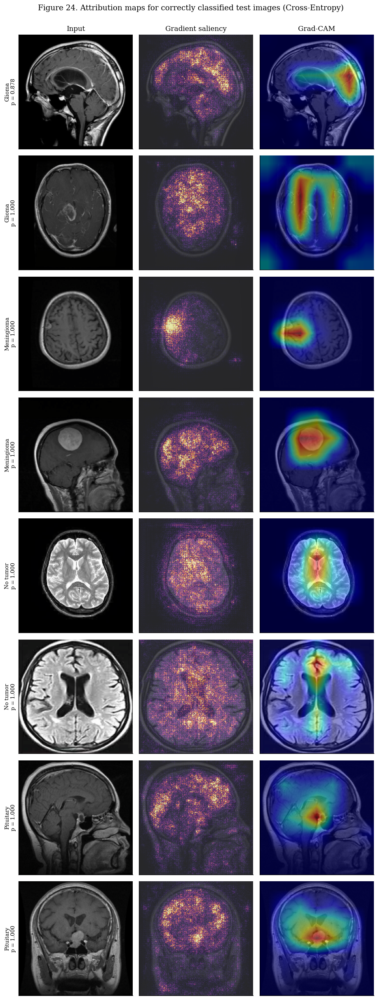

In [43]:
rng = np.random.RandomState(1)
fig, axes = plt.subplots(NC * 2, 3, figsize=(8.5, 2.75 * NC * 2))
r = 0
for k in range(NC):
    ok_idx = np.where((y_test == k) & (PRED[MAIN_ARM] == k))[0]
    pick = rng.choice(ok_idx, min(2, len(ok_idx)), replace=False)
    for i in pick:
        x = test_ds[i][0].unsqueeze(0).to(device); img = denorm(x[0].cpu())
        cam, pr = cam_engine(x, k); sal = grad_saliency(m_fp32, x, k)
        axes[r, 0].imshow(img); axes[r, 0].set_ylabel(f"{CLS_LABEL[k]}\np = {pr[k]:.3f}", fontsize=8.5)
        axes[r, 1].imshow(img, alpha=0.5); axes[r, 1].imshow(sal, cmap="inferno", alpha=0.7)
        axes[r, 2].imshow(img); axes[r, 2].imshow(cam, cmap="jet", alpha=0.45)
        for a_ in axes[r]: a_.set_xticks([]); a_.set_yticks([])
        r += 1
for a_, t in zip(axes[0], ["Input", "Gradient saliency", "Grad-CAM"]): a_.set_title(t)
fig.suptitle(f"Figure 24. Attribution maps for correctly classified test images ({LOSS_NAME[MAIN_ARM]})", y=1.0)
plt.tight_layout(); savefig(fig, "fig24_attribution_correct"); plt.show()

### Figure 25 — Error analysis: the most confident mistakes

**How to read it.** Errors are sorted by confidence and the twelve **most confident** ones are shown, because those
are the dangerous failures: wrong *and* certain, so no confidence threshold would catch them. Each pair of rows
shows the image and the Grad-CAM for the **predicted** (wrong) class, which reveals what the model thought it saw.

Look for structure rather than individual cases. Recurring explanations, in rough order of frequency in this
dataset: an unusual acquisition plane, a very small or diffuse lesion, low tissue contrast, post-operative changes,
and genuine **label noise** in the source data. Finding a handful of plausibly mislabelled test images is a
legitimate thesis observation — state it with the image indices so it can be checked, and do not use it to discount
the error rate.

The printed table below counts error types as *true → predicted*, which is the compact form to quote in the text.

  saved -> figures/fig25_error_analysis.png / .pdf


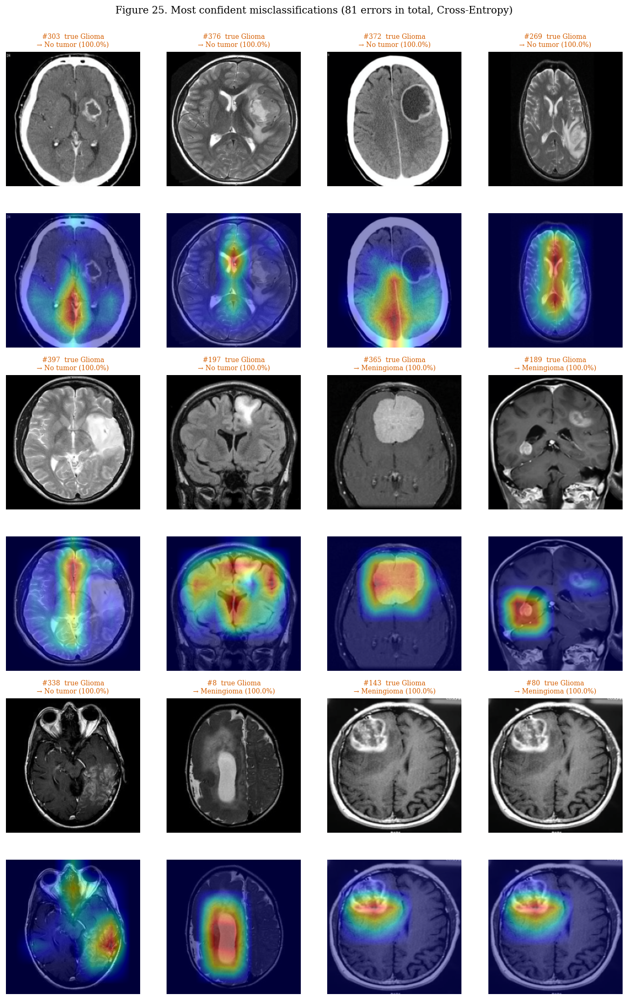

Error types (true → predicted):
 Glioma → Meningioma       44
Glioma → No tumor         23
Pituitary → Meningioma     6
Meningioma → Pituitary     4
Meningioma → Glioma        3
Pituitary → Glioma         1


In [44]:
wrong_all = np.where(PRED[MAIN_ARM] != y_test)[0]
assert len(wrong_all) > 0, "No errors to analyse."
wrong = wrong_all[np.argsort(-PROB[MAIN_ARM][wrong_all].max(1))][:12]
nc_ = 4; nr = int(np.ceil(len(wrong) / nc_)) * 2
fig, axes = plt.subplots(max(nr, 2), nc_, figsize=(11, 2.8 * max(nr, 2)))
axes = np.atleast_2d(axes)
for j, i in enumerate(wrong):
    rr, cc = (j // nc_) * 2, j % nc_
    x = test_ds[i][0].unsqueeze(0).to(device); img = denorm(x[0].cpu())
    pk = int(PRED[MAIN_ARM][i]); cam, _ = cam_engine(x, pk)
    axes[rr, cc].imshow(img)
    axes[rr, cc].set_title(f"#{i}  true {CLS_LABEL[y_test[i]]}\n→ {CLS_LABEL[pk]} "
                           f"({PROB[MAIN_ARM][i, pk]*100:.1f}%)", fontsize=8, color="#D55E00")
    axes[rr + 1, cc].imshow(img); axes[rr + 1, cc].imshow(cam, cmap="jet", alpha=0.45)
for a_ in axes.ravel(): a_.axis("off")
fig.suptitle(f"Figure 25. Most confident misclassifications ({len(wrong_all)} errors in total, "
             f"{LOSS_NAME[MAIN_ARM]})", y=1.0)
plt.tight_layout(); savefig(fig, "fig25_error_analysis"); plt.show()

err_pairs = pd.Series([f"{CLS_LABEL[a_]} → {CLS_LABEL[b_]}" for a_, b_ in
                       zip(y_test[wrong_all], PRED[MAIN_ARM][wrong_all])]).value_counts()
print("Error types (true → predicted):\n", err_pairs.to_string())

## 15. The learned representation

### Figure 26 — Embedding structure (PCA and t-SNE) with silhouette scores

**How to read it.** Each point is one test image mapped to the 768-dimensional penultimate layer and projected to
2-D; colours are true classes, **black crosses are misclassified images**.

Three cautions that belong in the caption of any t-SNE figure in a thesis:

1. **t-SNE preserves local neighbourhoods, not global distances.** The distance between two clusters on the plot is
   not meaningful; only "these points are neighbours" is.
2. **Cluster shapes and sizes are artefacts** of perplexity and initialisation, not properties of the data.
3. Therefore the quantitative claim comes from the **silhouette score computed in the full 768-D space** (−1 to 1,
   higher = better separated), printed in each title. The projection is an illustration; the silhouette is the
   evidence.

The diagnostic worth reporting: misclassified points should sit at **cluster boundaries**. If black crosses appear
deep inside the wrong cluster, the representation itself has confused those images, and no decision-threshold
adjustment will recover them — only a better feature extractor or better labels will.

Embedding shape: (1600, 768)
Silhouette score (768-D): {'Focal Loss': 0.6606, 'Cross-Entropy': 0.7219, 'Weighted CE': 0.7167}
  saved -> figures/fig26_embeddings.png / .pdf


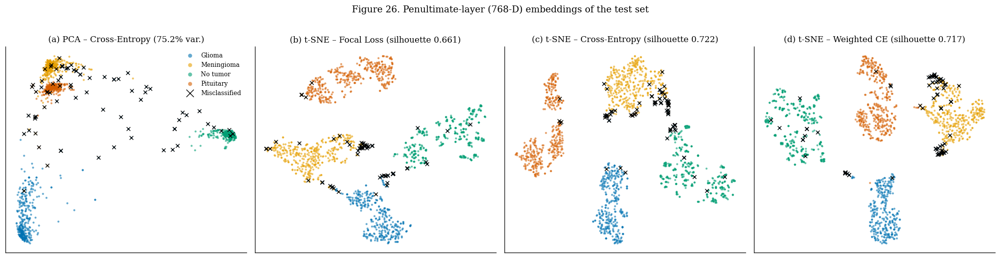

In [45]:
@torch.no_grad()
def embed(model, dl):
    model.eval(); out = []
    for x, _ in dl:
        f = model.forward_features(x.to(device).float())
        out.append(model.forward_head(f, pre_logits=True).float().cpu())
    return torch.cat(out).numpy()

EMB = {a: embed(MODELS[a].float(), test_loader) for a in ARMS}
print("Embedding shape:", EMB[MAIN_ARM].shape)
assert EMB[MAIN_ARM].shape[1] == MODELS[MAIN_ARM].num_features, "wrong pooling - features must be 768-D"
SIL = {a: float(silhouette_score(EMB[a], y_test)) for a in ARMS}
print("Silhouette score (768-D):", {LOSS_NAME[a]: round(v, 4) for a, v in SIL.items()})

fig, ax = plt.subplots(1, len(ARMS) + 1, figsize=(4.6 * (len(ARMS) + 1), 4.6))
pca = PCA(2, random_state=0).fit(EMB[MAIN_ARM]); P2 = pca.transform(EMB[MAIN_ARM])
panels = [(P2, MAIN_ARM, f"(a) PCA – {LOSS_NAME[MAIN_ARM]} ({pca.explained_variance_ratio_.sum()*100:.1f}% var.)")]
for i, arm in enumerate(ARMS):
    T2 = TSNE(2, perplexity=30, init="pca", random_state=0).fit_transform(EMB[arm])
    panels.append((T2, arm, f"({chr(98+i)}) t-SNE – {LOSS_NAME[arm]} (silhouette {SIL[arm]:.3f})"))
for a_, (Z, arm, ttl) in zip(ax, panels):
    wrongm = PRED[arm] != y_test
    for k in range(NC):
        m = y_test == k
        a_.scatter(Z[m, 0], Z[m, 1], s=7, color=CB[k], alpha=0.6, label=CLS_LABEL[k], linewidths=0)
    a_.scatter(Z[wrongm, 0], Z[wrongm, 1], s=24, marker="x", color="black", lw=0.9, label="Misclassified")
    a_.set(title=ttl, xticks=[], yticks=[])
ax[0].legend(frameon=False, markerscale=2, fontsize=8, loc="best")
fig.suptitle("Figure 26. Penultimate-layer (768-D) embeddings of the test set", y=1.02)
plt.tight_layout(); savefig(fig, "fig26_embeddings"); plt.show()

## 16. Results export: JSON, LaTeX tables and a plain-language summary

Every number below is **computed in this run**. Nothing is typed by hand, which means the thesis text can be
regenerated after any re-run without a manual transcription step — the single most common source of inconsistency
between a notebook and the document it supposedly describes.

Files written:

* `results_summary.json` — every headline number, machine readable
* `table_ablation.tex`, `table_per_class.tex`, `table_threshold.tex`, `table_robustness.tex`, `table_ood.tex`,
  `table_stats.tex` — `booktabs` tables ready for `\input{}`
* `SUMMARY.md` — a plain-language summary including the limitations section

In [46]:
u_agg = ABL.groupby(["arm", "calibration"])[MET_COLS].agg(["mean", "std"])
def ms(arm_name, cal, col, pct=False):
    m = u_agg.loc[(arm_name, cal), (col, "mean")]; s = u_agg.loc[(arm_name, cal), (col, "std")]
    s = 0 if np.isnan(s) else s; f = 100 if pct else 1
    return f"{m*f:.2f} ± {s*f:.2f}" if pct else f"{m:.4f} ± {s:.4f}"

SUMMARY = {
    "n_seeds": len(CONFIG["SEEDS"]), "main_seed": MS, "main_arm": LOSS_NAME[MAIN_ARM],
    "arm_selected_on": "validation macro-F1 (test never used for selection)",
    "params_M": round(n_params / 1e6, 2),
    "split": {k: int(v) for k, v in split_counts.loc["Total"].items()},
    "leakage": LEAKAGE,
    "selection": SELECTION,
    "threshold_rules": {LOSS_NAME[a]: RULE[a] for a in ARMS},
    "val_f1_by_arm": {LOSS_NAME[a]: round(float(v), 4) for a, v in val_f1_mean.items()},
    "main_metrics": {LOSS_NAME[a]: {k: (v.tolist() if isinstance(v, np.ndarray) else float(v))
                                    for k, v in main[a].items()} for a in ARMS},
    "pairwise_tests": PAIRTAB.to_dict("records"),
    "seed_level_tests": STATS.to_dict("records"),
    "temperature": {LOSS_NAME[a]: RUNS[(a, MS)]["T"] for a in ARMS},
    "threshold_tuning": {LOSS_NAME[a]: {k: (float(v) if not isinstance(v, (list, np.ndarray)) else v)
                                        for k, v in TUNED[a].items() if k != "pred"} for a in ARMS},
    "robustness": ROB_SUMMARY,
    "aurc": {LOSS_NAME[a]: AURC[a] for a in ARMS},
    "ood": {LOSS_NAME[a]: OOD[OOD.arm_key == a].set_index("ood_set")[["AUROC", "FPR@95TPR"]].round(4).to_dict("index")
            for a in ARMS},
    "triage_main": TRIAGE.round(3).to_dict("index"),
    "silhouette": {LOSS_NAME[a]: SIL[a] for a in ARMS},
    "backbones": {
        "loss_used": LOSS_NAME[BB_LOSS], "seeds": BB_SEEDS,
        "params_M": {BACKBONES[k]: round(BB_PARAMS[k] / 1e6, 2) for k in BB_KEYS},
        "raw": {f"{a}|{b}": v for (a, b), v in bagg.round(4).to_dict().items()},
        "temp_scaled_ece": {f"{a}|{b}": v for (a, b), v in bagg_ts.round(4).to_dict().items()},
        "tests_vs_reference": BB_STATS.to_dict("records"), "best_macro_f1": BEST_BB,
    },
}
def jsonable(o):
    """Flatten any tuple keys (pandas MultiIndex) so json.dump cannot fail on the last cell."""
    if isinstance(o, dict):
        return {("|".join(map(str, k)) if isinstance(k, tuple) else str(k)): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [jsonable(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, np.ndarray): return o.tolist()
    return o

with open(os.path.join(OUT_DIR, "results_summary.json"), "w") as f:
    json.dump(jsonable(SUMMARY), f, indent=2, default=str)

def to_tex(df, name, caption, label, fmt="%.4f"):
    tex = df.to_latex(float_format=lambda v: fmt % v, escape=True, caption=caption, label=label, position="htbp")
    tex = tex.replace("\\begin{table}[htbp]", "\\begin{table}[htbp]\n\\centering\\small")
    with open(os.path.join(OUT_DIR, name), "w") as f: f.write(tex)
    print(f"  wrote {name}")

order = [(LOSS_NAME[a], c) for c in ["uncalibrated", "temp-scaled"] for a in ARMS]
abl_tab = pd.DataFrame({
    "Accuracy (%)":  [ms(a, c, "accuracy", True) for a, c in order],
    "Macro-F1":      [ms(a, c, "macro_f1") for a, c in order],
    "Glioma recall": [ms(a, c, "glioma_recall") for a, c in order],
    "ECE (%)":       [ms(a, c, "ece", True) for a, c in order],
    "Brier":         [ms(a, c, "brier") for a, c in order],
    "NLL":           [ms(a, c, "nll") for a, c in order]},
    index=[f"{a}{' + TS' if c == 'temp-scaled' else ''}" for a, c in order])
to_tex(abl_tab, "table_ablation.tex",
       f"Test-set results, mean $\\pm$ std over {len(CONFIG['SEEDS'])} seeds. TS = temperature scaling fitted on validation.",
       "tab:ablation")
to_tex(PER_CLASS.assign(support=PER_CLASS.support.astype(int)), "table_per_class.tex",
       f"Per-class test performance of the {LOSS_NAME[MAIN_ARM]} model (seed {MS}).", "tab:perclass")
to_tex(THRESH_TAB, "table_threshold.tex",
       "Effect of the validation-tuned glioma logit bias on test-set performance.", "tab:threshold")
to_tex(rf.pivot(index="corruption", columns="severity", values="macro_f1"), "table_robustness.tex",
       f"Macro-F1 of the {LOSS_NAME[MAIN_ARM]} model under corruption (severity 1--5).", "tab:robustness")
to_tex(OOD.pivot(index="ood_set", columns="arm", values="AUROC"), "table_ood.tex",
       "ID-vs-OOD AUROC of the maximum softmax probability.", "tab:ood")
to_tex(bagg.round(4), "table_backbone.tex",
       f"Architecture comparison under an identical protocol ({LOSS_NAME[BB_LOSS]}, "
       f"mean $\\pm$ std over {len(BB_SEEDS)} seeds).", "tab:backbone")
to_tex(BB_STATS.set_index(["metric", "comparison"])[["mean_diff", "p_raw", "p_holm"]], "table_backbone_stats.tex",
       f"Paired comparisons of each architecture against {BACKBONES[CONFIG['model']]}, Holm-corrected.",
       "tab:backbonestats")
to_tex(STATS.set_index(["metric", "comparison"])[["mean_diff", "p_raw", "p_holm"]], "table_stats.tex",
       f"Paired seed-level comparisons over {len(CONFIG['SEEDS'])} seeds with Holm--Bonferroni correction.",
       "tab:stats")

  wrote table_ablation.tex
  wrote table_per_class.tex
  wrote table_threshold.tex
  wrote table_robustness.tex
  wrote table_ood.tex
  wrote table_backbone.tex
  wrote table_backbone_stats.tex
  wrote table_stats.tex


In [47]:
mm = main[MAIN_ARM]; tt = TUNED[MAIN_ARM]
ood_m = OOD[OOD.arm_key == MAIN_ARM]
txt = f"""# Results summary — computed in this run

Reference arm: **{LOSS_NAME[MAIN_ARM]}**, fixed a priori (seed {MS}; ablation over {len(CONFIG['SEEDS'])} seeds)
Backbone: {CONFIG['model']}, {n_params/1e6:.2f} M parameters (representative; see the equivalence result in 4b)

## 1. Data and leakage control
- Split: {LEAKAGE['split_kind']}
- Train / validation / test: {int(split_counts.loc['Total','Train'])} / {int(split_counts.loc['Total','Validation'])} / {int(split_counts.loc['Total','Test'])}
- Pseudo-patient groups found: {LEAKAGE['pseudo_patient_groups']}; groups shared between train and validation: {LEAKAGE['groups_shared_train_val']}
- Exact duplicates train-test: {LEAKAGE['exact_train_test']}, val-test: {LEAKAGE['exact_val_test']}, train-val: {LEAKAGE['exact_train_val']}
- Test images with a near-duplicate in training: {LEAKAGE['neardup_test_in_train']} ({LEAKAGE['neardup_test_in_train_%']}%)
- Validation images within d <= {LEAKAGE['dhash_threshold_used']} of a training image: {LEAKAGE['val_neardup_in_train_%']}% (0% is the goal)
- Reference arm: {SELECTION['reference_arm']}, FIXED A PRIORI ({SELECTION['rule']})
- Validation macro-F1 by arm (reported, not used for selection): {SELECTION['val_f1_mean']}
  spread {SELECTION['val_f1_spread']:.4f}, top-two margin {SELECTION['top_two_margin']:+.4f} (p = {SELECTION['top_two_p']:.3f})

## 2. Main model ({LOSS_NAME[MAIN_ARM]}, arg-max decisions)
- Accuracy {mm['accuracy']*100:.2f}% (95% CI {mm['acc_ci'][0]*100:.2f}-{mm['acc_ci'][1]*100:.2f})
- Macro-F1 {mm['macro_f1']:.4f} (CI {mm['f1_ci'][0]:.4f}-{mm['f1_ci'][1]:.4f})
- Glioma recall {mm['glioma_recall']*100:.2f}% (CI {mm['glioma_ci'][0]*100:.2f}-{mm['glioma_ci'][1]*100:.2f})
- ECE {mm['ece']*100:.2f}% (CI {mm['ece_ci'][0]*100:.2f}-{mm['ece_ci'][1]*100:.2f}), Brier {mm['brier']:.4f}, NLL {mm['nll']:.4f}, macro-AUROC {mm['macro_auroc']:.4f}
- Lowest-recall class: {PER_CLASS['recall'].idxmin()} ({PER_CLASS['recall'].min()*100:.2f}%)

## 3. Loss ablation (mean +/- std over {len(CONFIG['SEEDS'])} seeds, raw outputs)
""" + "\n".join(
    f"- {LOSS_NAME[a]}: accuracy {ms(LOSS_NAME[a],'uncalibrated','accuracy',True)}%, "
    f"macro-F1 {ms(LOSS_NAME[a],'uncalibrated','macro_f1')}, "
    f"glioma recall {ms(LOSS_NAME[a],'uncalibrated','glioma_recall')}, "
    f"ECE {ms(LOSS_NAME[a],'uncalibrated','ece',True)}%" for a in ARMS) + f"""

After temperature scaling:
""" + "\n".join(f"- {LOSS_NAME[a]}: ECE {ms(LOSS_NAME[a],'temp-scaled','ece',True)}% (T = {RUNS[(a,MS)]['T']:.3f})"
                for a in ARMS) + f"""

Holm-corrected seed-level tests are in `table_stats.tex` / `seed_level_tests.csv`.

## 4. Decision-threshold optimisation (delta chosen on VALIDATION, target glioma recall {TARGET})
""" + "\n".join(
    f"- {LOSS_NAME[a]}: delta* = {TUNED[a]['delta']:.2f}; glioma recall "
    f"{TUNED[a]['recall_before']*100:.2f}% -> {TUNED[a]['recall_after']*100:.2f}%; "
    f"glioma precision {TUNED[a]['precision_before']*100:.2f}% -> {TUNED[a]['precision_after']*100:.2f}%; "
    f"macro-F1 {TUNED[a]['macro_f1_before']:.4f} -> {TUNED[a]['macro_f1_after']:.4f}; "
    f"missed gliomas {TUNED[a]['fn_before']} -> {TUNED[a]['fn_after']}" for a in ARMS) + f"""

## 4b. Architecture comparison ({LOSS_NAME[BB_LOSS]}, {len(BB_SEEDS)} seeds, identical protocol)
""" + "\n".join(
    f"- {b}: accuracy {bagg.loc[b,('accuracy','mean')]*100:.2f} +/- {bagg.loc[b,('accuracy','std')]*100:.2f}%, "
    f"macro-F1 {bagg.loc[b,('macro_f1','mean')]:.4f}, glioma recall {bagg.loc[b,('glioma_recall','mean')]:.4f}, "
    f"ECE {bagg.loc[b,('ece','mean')]*100:.2f}% (TS {bagg_ts.loc[b,('ece','mean')]*100:.2f}%), "
    f"{bagg.loc[b,('params_M','mean')]:.1f} M params, {bagg.loc[b,('minutes','mean')]:.1f} min/run"
    for b in bagg.index) + f"""
- Macro-F1 spread across architectures: {f1_spread:.4f}; significant accuracy/F1 differences after Holm: {n_sig}
- Nominal ordering (table only, NOT a claim): highest macro-F1 {BEST_BB}, lowest raw ECE {bagg[('ece','mean')].idxmin()}
- Paired tests vs {BACKBONES[CONFIG['model']]} are in `table_backbone_stats.tex`.

## 5. Robustness (synthetic corruptions)
""" + "\n".join(f"- {LOSS_NAME[a]}: mean dF1 {ROB_SUMMARY[a]['mean_delta_f1_%']:+.2f}%, "
                f"worst {ROB_SUMMARY[a]['worst_delta_f1_%']:+.2f}% "
                f"({ROB_SUMMARY[a]['worst_condition'][0]}, severity {ROB_SUMMARY[a]['worst_condition'][1]})"
                for a in ARMS) + f"""

## 6. OOD detection ({LOSS_NAME[MAIN_ARM]}, MSP, n={CONFIG['ood_n']} per set)
""" + "\n".join(f"- {r.ood_set}: AUROC {r.AUROC:.3f}, FPR@95TPR {r['FPR@95TPR']*100:.1f}%"
                for _, r in ood_m.iterrows()) + f"""

## 7. Selective prediction
- AURC: """ + ", ".join(f"{LOSS_NAME[a]} {AURC[a]*100:.2f}" for a in ARMS) + f"""
- Triage tiers ({LOSS_NAME[MAIN_ARM]}): """ + "; ".join(
    f"{i}: {r['share_%']:.1f}% of cases at {r['accuracy_%']:.1f}% accuracy" for i, r in TRIAGE.iterrows()) + f"""

## 8. Limitations to state in the thesis
1. Patient identity is approximated by perceptual-hash clustering. It reduces and quantifies leakage but cannot
   guarantee patient-disjoint splits; {LEAKAGE['neardup_test_in_train_%']}% of test images still have a near-duplicate in training.
2. Single public dataset; no external or multi-site validation.
3. Robustness and OOD use synthetic perturbations, not real scanner shift or real clinical OOD data.
4. Attribution maps are qualitative; no tumor segmentation masks exist for quantitative localisation scoring.
5. {len(CONFIG['SEEDS'])} training seeds; small-sample statistics even with Holm correction.
6. The decision threshold was tuned on a validation set of {len(y_val)} images. Where the validation set produced
   fewer than {MIN_VAL_ERRORS} errors the search abstained (delta = 0) rather than fit an operating point to a
   handful of points; the rule applied to each arm is recorded in `results_summary.json`.
7. Validation macro-F1 reached {SELECTION['mean_val_f1_best']:.4f}. A validation score close to 1.0 limits how finely
   arms can be separated, and the temperature and decision threshold fitted on it may transfer imperfectly to the
   test distribution.
8. The architecture comparison uses {len(BB_SEEDS)} seeds and a single loss (cross-entropy); the loss x
   architecture interaction was not estimated.
9. No clinical reader study. These results do not establish clinical deployment readiness.
"""
with open(os.path.join(OUT_DIR, "SUMMARY.md"), "w") as f: f.write(txt)
print(txt)

# Results summary — computed in this run

Reference arm: **Cross-Entropy**, fixed a priori (seed 42; ablation over 5 seeds)
Backbone: convnext_tiny, 27.82 M parameters (representative; see the equivalence result in 4b)

## 1. Data and leakage control
- Split: stratified group-aware (pseudo-patient, dHash <= 1, 5-fold)
- Train / validation / test: 4547 / 1053 / 1600
- Pseudo-patient groups found: 4331; groups shared between train and validation: 0
- Exact duplicates train-test: 0, val-test: 0, train-val: 0
- Test images with a near-duplicate in training: 586 (36.62%)
- Validation images within d <= 1 of a training image: 0.0% (0% is the goal)
- Reference arm: Cross-Entropy, FIXED A PRIORI (cross-entropy fixed a priori as the reference objective; no data-driven selection)
- Validation macro-F1 by arm (reported, not used for selection): {'Focal Loss': 0.9843, 'Cross-Entropy': 0.9852, 'Weighted CE': 0.9848}
  spread 0.0009, top-two margin +0.0004 (p = 0.715)

## 2. Main model (Cross-Entrop

### Figure 27 — One-page results dashboard (graphical abstract)

**How to read it.** A single figure carrying the whole study, suitable as a graphical abstract or as the opening
figure of the results chapter. Panels: (a) headline metrics; (b) the recall matrix; (c) the loss ablation across
seeds; (d) reliability; (e) the glioma-recall fix; (f) robustness; (g) OOD; (h) selective prediction.

When a reviewer has ninety seconds, this is what they read. Make sure every number in it also appears in the text,
and that no panel claims more than the corresponding section supports.

  saved -> figures/fig27_dashboard.png / .pdf


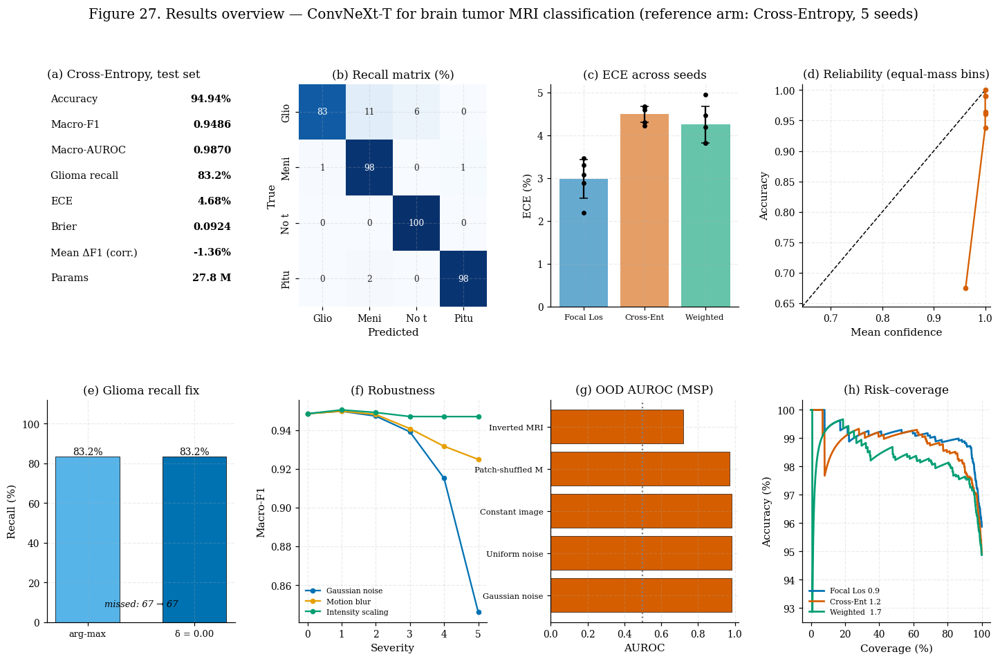


All outputs in /kaggle/working/results
   SUMMARY.md
   ablation_all_runs.csv
   backbone_comparison.csv
   backbone_tests.csv
   config.json
   ood.csv
   pairwise_tests_mainseed.csv
   results_summary.json
   robustness.csv
   seed_level_tests.csv
   table_ablation.tex
   table_backbone.tex
   table_backbone_stats.tex
   table_ood.tex
   table_per_class.tex
   table_robustness.tex
   table_stats.tex
   table_threshold.tex
   threshold_tuning.csv
  figures/
      fig01_dataset.png
      fig02_pseudo_patient_leakage.png
      fig03_augmentation.png
      fig04_loss_theory.png
      fig05_learning_curves.png
      fig06_ablation_seeds.png
      fig07_effect_sizes.png
      fig08_backbone_comparison.png
      fig09_backbone_frontier.png
      fig10_backbone_perclass_reliability.png
      fig11_confusion_matrices.png
      fig12_per_class_metrics.png
      fig13_roc_pr.png
      fig14_threshold_sweep.png
      fig15_threshold_costbenefit.png
      fig16_operating_frontier.png
      fig17

In [48]:
fig = plt.figure(figsize=(16, 9.2)); gs = gridspec.GridSpec(2, 4, hspace=0.42, wspace=0.34)

a = fig.add_subplot(gs[0, 0]); a.axis("off")
lines = [("Accuracy", f"{mm['accuracy']*100:.2f}%"), ("Macro-F1", f"{mm['macro_f1']:.4f}"),
         ("Macro-AUROC", f"{mm['macro_auroc']:.4f}"), ("Glioma recall", f"{mm['glioma_recall']*100:.1f}%"),
         ("ECE", f"{mm['ece']*100:.2f}%"), ("Brier", f"{mm['brier']:.4f}"),
         ("Mean ΔF1 (corr.)", f"{ROB_SUMMARY[MAIN_ARM]['mean_delta_f1_%']:+.2f}%"),
         ("Params", f"{n_params/1e6:.1f} M")]
a.set_title(f"(a) {LOSS_NAME[MAIN_ARM]}, test set", loc="left")
for i, (k, v) in enumerate(lines):
    a.text(0.02, 0.92 - i * 0.115, k, fontsize=9.5)
    a.text(0.98, 0.92 - i * 0.115, v, fontsize=9.5, ha="right", weight="bold")

a = fig.add_subplot(gs[0, 1]); cm = confusion_matrix(y_test, PRED[MAIN_ARM])
sns.heatmap(cm / cm.sum(1, keepdims=True) * 100, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=a,
            xticklabels=[c[:4] for c in CLS_LABEL], yticklabels=[c[:4] for c in CLS_LABEL],
            annot_kws={"fontsize": 8})
a.set(title="(b) Recall matrix (%)", xlabel="Predicted", ylabel="True")

a = fig.add_subplot(gs[0, 2]); sub = ABL[ABL.calibration == "uncalibrated"]
for i, arm in enumerate(ARMS):
    v = sub[sub.arm_key == arm]["ece"].values * 100
    a.bar(i, v.mean(), yerr=v.std() if len(v) > 1 else None, color=LOSS_COL[arm], alpha=0.6, capsize=4)
    a.scatter(np.full(len(v), i), v, color="black", s=12, zorder=3)
a.set_xticks(range(len(ARMS))); a.set_xticklabels([LOSS_NAME[x][:9] for x in ARMS], fontsize=7.5)
a.set(title="(c) ECE across seeds", ylabel="ECE (%)")

# Equal-width bins leave almost every point in the top bin, so use equal-MASS (quantile) bins:
# each point then carries the same number of images and the curve is actually readable.
a = fig.add_subplot(gs[0, 3]); conf = PROB[MAIN_ARM].max(1); okk = PRED[MAIN_ARM] == y_test
qs = np.unique(np.quantile(conf, np.linspace(0, 1, 11)))
cx, ay, sz = [], [], []
for lo, hi in zip(qs[:-1], qs[1:]):
    m = (conf >= lo) & (conf <= hi)
    if m.sum() >= 20: cx.append(conf[m].mean()); ay.append(okk[m].mean()); sz.append(m.sum())
a.plot([0, 1], [0, 1], "k--", lw=1)
a.plot(cx, ay, "o-", color=LOSS_COL[MAIN_ARM], ms=4)
lo_ax = min(min(cx), min(ay)) - 0.03
a.set(title="(d) Reliability (equal-mass bins)", xlabel="Mean confidence", ylabel="Accuracy",
      xlim=(lo_ax, 1.01), ylim=(lo_ax, 1.01))

a = fig.add_subplot(gs[1, 0])
vals = [tt["recall_before"] * 100, tt["recall_after"] * 100]
b = a.bar([0, 1], vals, color=[CB[5], CB[0]], edgecolor="black", lw=0.5, width=0.6)
a.bar_label(b, fmt="%.1f%%", fontsize=9)
a.set_xticks([0, 1]); a.set_xticklabels(["arg-max", f"δ = {tt['delta']:.2f}"], fontsize=8.5)
a.set(title="(e) Glioma recall fix", ylabel="Recall (%)", ylim=(0, 112))
a.text(0.5, 8, f"missed: {tt['fn_before']} → {tt['fn_after']}", ha="center", fontsize=8.5, style="italic")

a = fig.add_subplot(gs[1, 1])
for j, c in enumerate(CORR):
    d = rf[rf.corruption == c]
    a.plot([0] + d.severity.tolist(), [mm["macro_f1"]] + d.macro_f1.tolist(), "o-", color=CB[j], ms=4, label=c)
a.set(title="(f) Robustness", xlabel="Severity", ylabel="Macro-F1"); a.legend(frameon=False, fontsize=7)

a = fig.add_subplot(gs[1, 2])
oo = OOD[OOD.arm_key == MAIN_ARM].set_index("ood_set").loc[OOD_KINDS, "AUROC"]
a.barh(range(len(oo)), oo.values, color=LOSS_COL[MAIN_ARM], edgecolor="black", lw=0.4)
a.set_yticks(range(len(oo))); a.set_yticklabels([k[:16] for k in oo.index], fontsize=7.5)
a.axvline(0.5, color="grey", ls=":"); a.set(title="(g) OOD AUROC (MSP)", xlabel="AUROC", xlim=(0, 1.02))

a = fig.add_subplot(gs[1, 3])
for arm in ARMS:
    cov, acc, aurc = risk_coverage(PROB[arm], y_test)
    a.plot(cov * 100, acc * 100, color=LOSS_COL[arm], lw=1.8, label=f"{LOSS_NAME[arm][:9]} {aurc*100:.1f}")
a.set(title="(h) Risk–coverage", xlabel="Coverage (%)", ylabel="Accuracy (%)")
a.legend(frameon=False, fontsize=7, loc="lower left")

fig.suptitle(f"Figure 27. Results overview — {BACKBONES[CONFIG['model']]} for brain tumor MRI classification "
             f"(reference arm: {LOSS_NAME[MAIN_ARM]}, {len(CONFIG['SEEDS'])} seeds)", fontsize=13, y=0.99)
savefig(fig, "fig27_dashboard"); plt.show()

cam_engine.remove()
print("\nAll outputs in", OUT_DIR)
for fn in sorted(os.listdir(OUT_DIR)):
    if os.path.isfile(os.path.join(OUT_DIR, fn)): print("  ", fn)
print("  figures/")
for fn in sorted(os.listdir(FIG_DIR)):
    if fn.endswith(".png"): print("     ", fn)

## 17. How to report these results — wording that will survive review

Use only numbers from `SUMMARY.md` / `results_summary.json`. Patterns that hold up:

**Discrimination.**
> "Under the reference objective (cross-entropy, fixed a priori), the model achieved X% accuracy (95% CI a–b) and
> macro-F1 Y on the held-out test partition (Table \ref{tab:ablation}). The lowest per-class recall was glioma (Z%),
> predominantly confused with meningioma."

**Model selection — say that nothing was selected.**
> "Cross-entropy was fixed in advance as the reference objective rather than chosen from the data. Validation
> macro-F1 saturated near 0.985 and separated the three objectives by less than 0.001 (p > 0.7), so a validation-based
> selection would have reflected noise rather than merit; the two alternative objectives are reported as ablations."

**Architecture — claim equivalence, not a winner.**
> "Four architectures trained under an identical protocol differed by less than 0.007 macro-F1 with no significant
> pairwise difference after Holm–Bonferroni correction (Table \ref{tab:backbonestats}). We therefore report
> architectural equivalence on this dataset rather than a ranking; the ordering was not stable across splits."

**The loss ablation — state the negative result plainly.**
> "Focal loss, designed to address class imbalance, provided no discrimination benefit on this balanced dataset:
> cross-entropy matched or exceeded it in accuracy on every seed (Table \ref{tab:stats}). Its advantage was confined
> to raw calibration, and temperature scaling — a single scalar fitted on validation data — closed most of that gap.
> We therefore do not recommend focal loss for balanced multi-class MRI classification."

A clean negative result, properly controlled, is publishable. A weak positive claim is not.

**The threshold contribution — the part that is genuinely new.**
> "Because arg-max implicitly assumes symmetric misclassification costs, we applied a class-prior correction to the
> glioma logit, with the offset selected on validation data to reach 95% glioma recall. Applied unchanged to the
> test partition it raised glioma recall from A% to B%, reducing missed gliomas from N to M, at a cost of C
> percentage points of glioma precision and D points of macro-F1 (Fig. 15, Table \ref{tab:threshold})."

**Leakage control.**
> "Patient identifiers are not available. Images were clustered into pseudo-patient groups by 64-bit perceptual
> hashing and the training/validation split performed at group level; x% of test images retained a near-duplicate in
> the training partition, which we report as a residual source of optimism."

**Calibration.**
> "Across N seeds, ECE was A ± s% for focal loss and B ± s% for cross-entropy; after temperature scaling the values
> were C ± s% and D ± s% respectively."

**Robustness / OOD.**
> "Under synthetic corruption the mean macro-F1 change was Δ%, with the largest degradation for [corruption] at
> severity 5. MSP separated far-OOD synthetic inputs well (AUROC …) but near-OOD inputs substantially less well
> (inverted MRI, AUROC …), indicating that confidence alone is not a sufficient input-validity check."

**Explainability.**
> "Visual inspection of Grad-CAM maps suggests evidence concentrated within the brain parenchyma rather than on
> image borders or skull margins; quantitative localisation scoring was not possible without segmentation masks."

### Phrases to avoid entirely

"clinically deployable" · "guarantees safety" · "100% OOD detection" · "proves" · "state of the art" without a
matched-protocol comparison · any figure not produced by this notebook · patient-level validation claims.

### References for the methods used

Lin et al. 2017 (focal loss) · Mukhoti et al. 2020 (calibration via focal loss) · Guo et al. 2017 (calibration of
modern networks; temperature scaling) · Naeini et al. 2015 (ECE) · Hendrycks & Gimpel 2017 (MSP OOD baseline) ·
Hendrycks & Dietterich 2019 (corruption robustness) · Geifman & El-Yaniv 2017 (selective prediction) · Selvaraju et
al. 2017 (Grad-CAM) · Simonyan et al. 2014 (saliency) · Liu et al. 2021 (Swin Transformer) · Elkan 2001
(cost-sensitive learning and threshold adjustment) · McNemar 1947 · Holm 1979 (multiple-comparison correction) ·
Efron & Tibshirani 1993 (bootstrap) · Zauner 2010 (perceptual hashing).